Total failed puzzles: 313
Total test images: 5999
Failure rate: 5.22%
Success rate: 94.78%

=== FAILURE ANALYSIS ===
Average piece accuracy in failed cases: 0.839
Median piece accuracy in failed cases: 0.875
Worst case accuracy: 0.125
Best failed case accuracy: 0.875


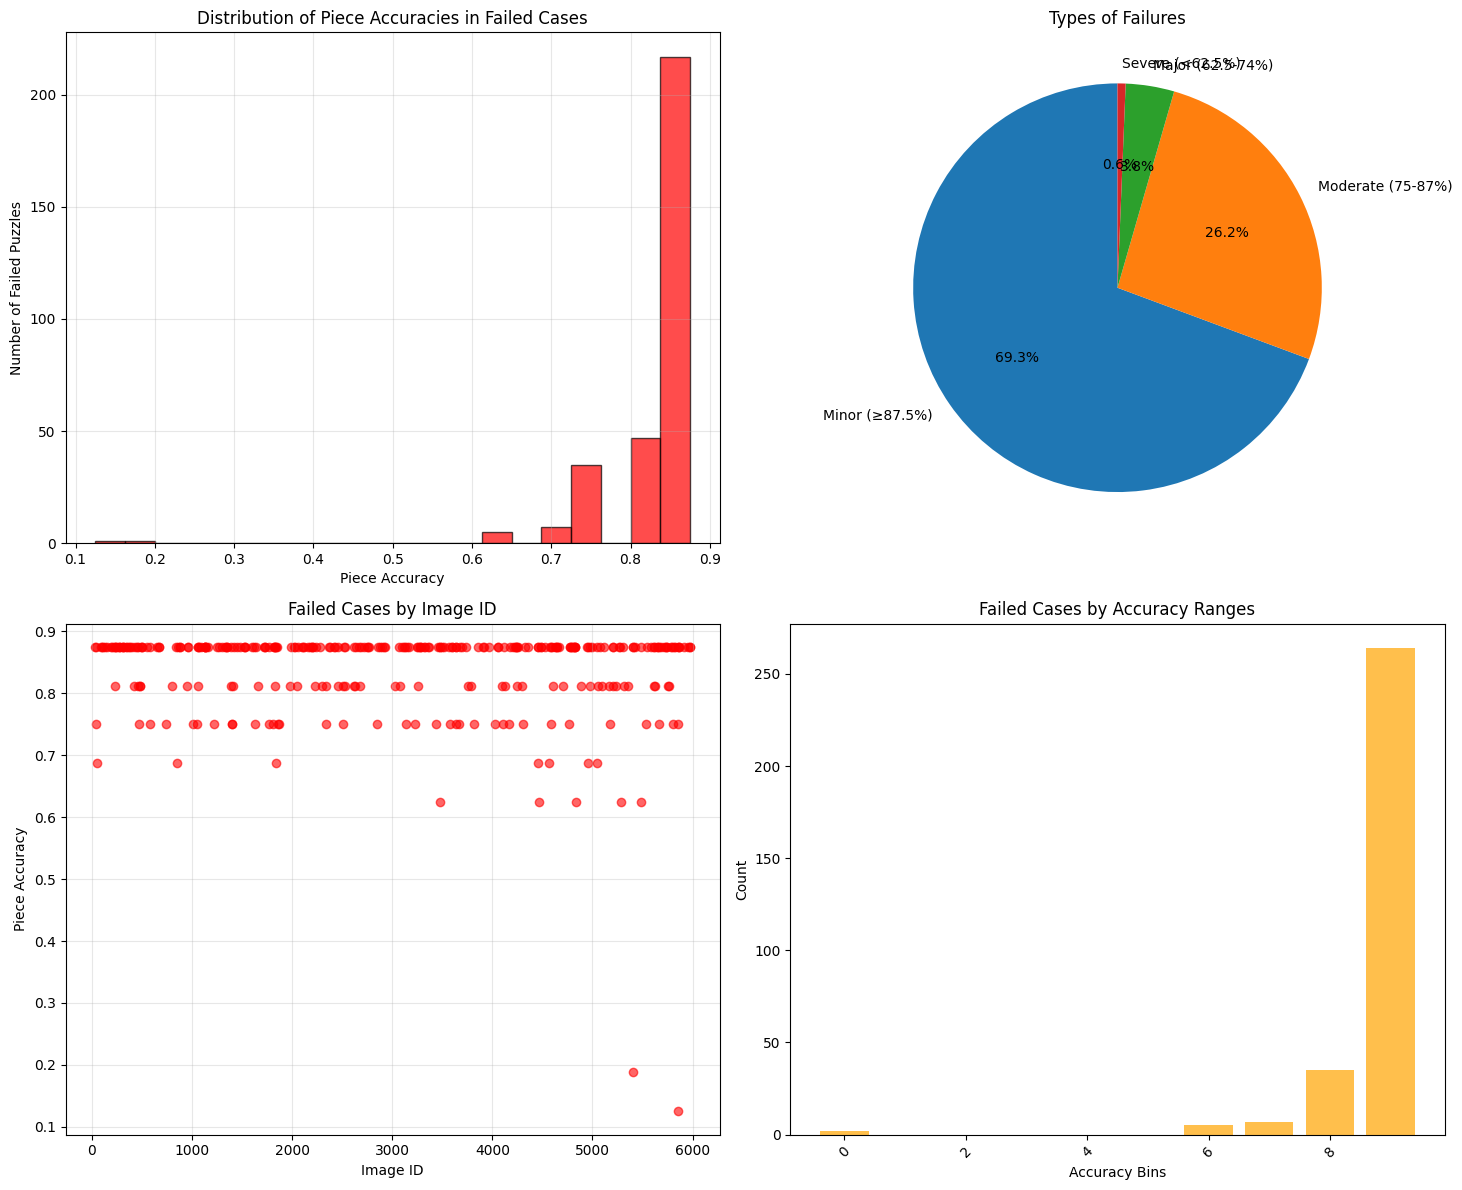


=== FAILURE BREAKDOWN ===
Minor (≥87.5%): 217 cases (69.3%)
Moderate (75-87%): 82 cases (26.2%)
Major (62.5-74%): 12 cases (3.8%)
Severe (<62.5%): 2 cases (0.6%)

=== WORST CASES (for manual inspection) ===
Image 5851: 0.125 accuracy (14 pieces wrong)
Image 5406: 0.188 accuracy (12 pieces wrong)
Image 3477: 0.625 accuracy (6 pieces wrong)
Image 4464: 0.625 accuracy (6 pieces wrong)
Image 4834: 0.625 accuracy (6 pieces wrong)
Image 5289: 0.625 accuracy (6 pieces wrong)
Image 5483: 0.625 accuracy (6 pieces wrong)
Image   52: 0.688 accuracy (4 pieces wrong)
Image  849: 0.688 accuracy (4 pieces wrong)
Image 1843: 0.688 accuracy (4 pieces wrong)

=== FAILURE DISTRIBUTION ANALYSIS ===
Images    0-1000:  54 failures
Images 1000-2000:  55 failures
Images 2000-3000:  46 failures
Images 3000-4000:  45 failures
Images 4000-5000:  57 failures
Images 5000-6000:  56 failures


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Load the failed puzzles data
failed_data = pd.read_csv('failed_puzzles.log', 
                         names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print(f"Total failed puzzles: {len(failed_data)}")
print(f"Total test images: 5999")
print(f"Failure rate: {len(failed_data)/5999*100:.2f}%")
print(f"Success rate: {(5999-len(failed_data))/5999*100:.2f}%")

# Basic statistics
print("\n=== FAILURE ANALYSIS ===")
print(f"Average piece accuracy in failed cases: {failed_data['piece_accuracy'].mean():.3f}")
print(f"Median piece accuracy in failed cases: {failed_data['piece_accuracy'].median():.3f}")
print(f"Worst case accuracy: {failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {failed_data['piece_accuracy'].max():.3f}")

# Categorize failures
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

failed_data['failure_type'] = failed_data['piece_accuracy'].apply(categorize_failure)

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of piece accuracies in failed cases
ax1.hist(failed_data['piece_accuracy'], bins=20, alpha=0.7, color='red', edgecolor='black')
ax1.set_xlabel('Piece Accuracy')
ax1.set_ylabel('Number of Failed Puzzles')
ax1.set_title('Distribution of Piece Accuracies in Failed Cases')
ax1.grid(True, alpha=0.3)

# 2. Failure categories pie chart
failure_counts = failed_data['failure_type'].value_counts()
ax2.pie(failure_counts.values, labels=failure_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Types of Failures')

# 3. Piece accuracy over image IDs (to see if failures cluster)
ax3.scatter(failed_data['image_id'], failed_data['piece_accuracy'], alpha=0.6, color='red')
ax3.set_xlabel('Image ID')
ax3.set_ylabel('Piece Accuracy')
ax3.set_title('Failed Cases by Image ID')
ax3.grid(True, alpha=0.3)

# 4. Count of failures by accuracy bins
accuracy_bins = pd.cut(failed_data['piece_accuracy'], bins=10)
bin_counts = accuracy_bins.value_counts().sort_index()
ax4.bar(range(len(bin_counts)), bin_counts.values, alpha=0.7, color='orange')
ax4.set_xlabel('Accuracy Bins')
ax4.set_ylabel('Count')
ax4.set_title('Failed Cases by Accuracy Ranges')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n=== FAILURE BREAKDOWN ===")
for category, count in failure_counts.items():
    print(f"{category}: {count} cases ({count/len(failed_data)*100:.1f}%)")

# Find worst cases for manual inspection
print("\n=== WORST CASES (for manual inspection) ===")
worst_cases = failed_data.nsmallest(10, 'piece_accuracy')
for _, row in worst_cases.iterrows():
    pieces_wrong = int(16 * (1 - row['piece_accuracy']))
    print(f"Image {row['image_id']:4d}: {row['piece_accuracy']:.3f} accuracy ({pieces_wrong} pieces wrong)")

# Check if failures are clustered in certain image ID ranges
print("\n=== FAILURE DISTRIBUTION ANALYSIS ===")
id_ranges = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 6000)]
for start, end in id_ranges:
    range_failures = failed_data[(failed_data['image_id'] >= start) & (failed_data['image_id'] < end)]
    print(f"Images {start:4d}-{end:4d}: {len(range_failures):3d} failures")

=== CHECKING SAVED IMAGES ===
Total files in results: 65989
Final images found: 5999
Example filenames:
  3104_final.png
  238_final.png
  4442_final.png
  1521_final.png
  3216_final.png
  1604_final.png
  5119_final.png
  1817_final.png
  4385_final.png
  4765_final.png

=== VISUALIZING WORST CASES ===


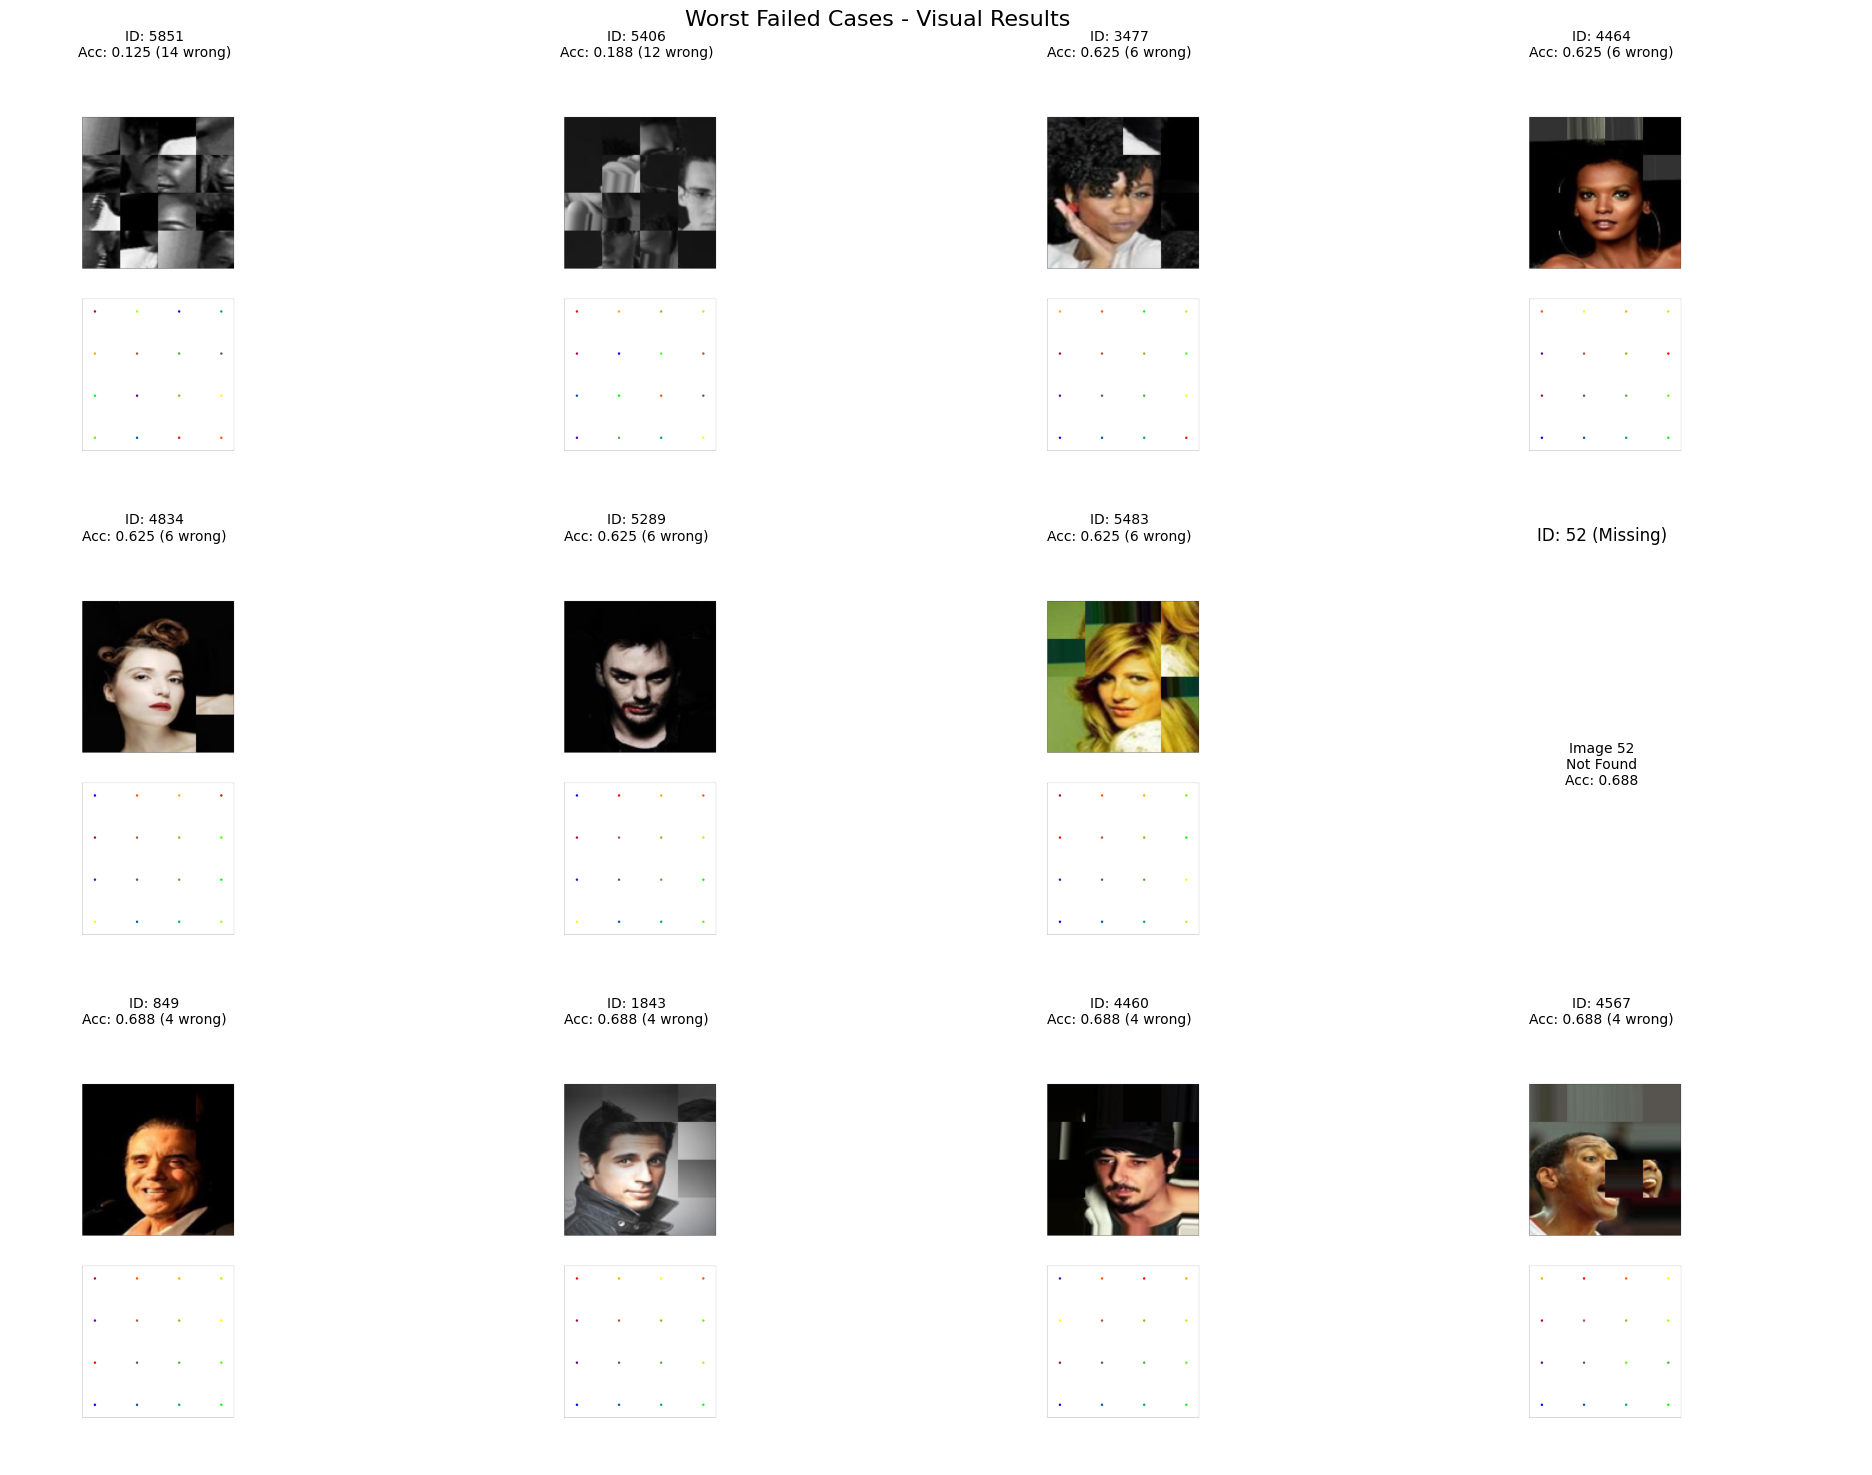

In [3]:
# Add this new cell to visualize the actual failed puzzle images
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to your saved results
results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/celeba-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/"

def visualize_failed_cases(num_cases=12, case_type="worst"):
    """
    Visualize failed puzzle cases
    case_type: "worst", "random", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = failed_data[failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = failed_data[failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid
    cols = 4
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten() if num_cases > 1 else [axes]
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # Try to find the final image file
        possible_names = [
            f"{image_id:03d}_000_final.png",
            f"{image_id:04d}_000_final.png", 
            f"{image_id:05d}_000_final.png",
            f"{image_id:03d}_final.png",
            f"{image_id:04d}_final.png",
            f"{image_id:05d}_final.png"
        ]
        
        image_found = False
        for name in possible_names:
            image_path = os.path.join(results_path, name)
            if os.path.exists(image_path):
                try:
                    img = Image.open(image_path)
                    axes[idx].imshow(img)
                    axes[idx].set_title(f'ID: {image_id}\nAcc: {piece_acc:.3f} ({pieces_wrong} wrong)', 
                                      fontsize=10)
                    axes[idx].axis('off')
                    image_found = True
                    break
                except Exception as e:
                    continue
        
        if not image_found:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'ID: {image_id} (Missing)')
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{case_type.title()} Failed Cases - Visual Results', fontsize=16)
    plt.tight_layout()
    plt.show()

# Check what files exist in the results directory
print("=== CHECKING SAVED IMAGES ===")
if os.path.exists(results_path):
    files = os.listdir(results_path)
    print(f"Total files in results: {len(files)}")
    
    # Show some example filenames to understand the naming pattern
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    print("Example filenames:")
    for i, fname in enumerate(final_images[:10]):
        print(f"  {fname}")
    
    # Now visualize the worst cases
    print("\n=== VISUALIZING WORST CASES ===")
    visualize_failed_cases(num_cases=12, case_type="worst")
    
else:
    print(f"Results path not found: {results_path}")
    print("Please check the path or run evaluation with --save_eval_images True first")


=== VISUALIZING WORST CASES (2 per row) ===


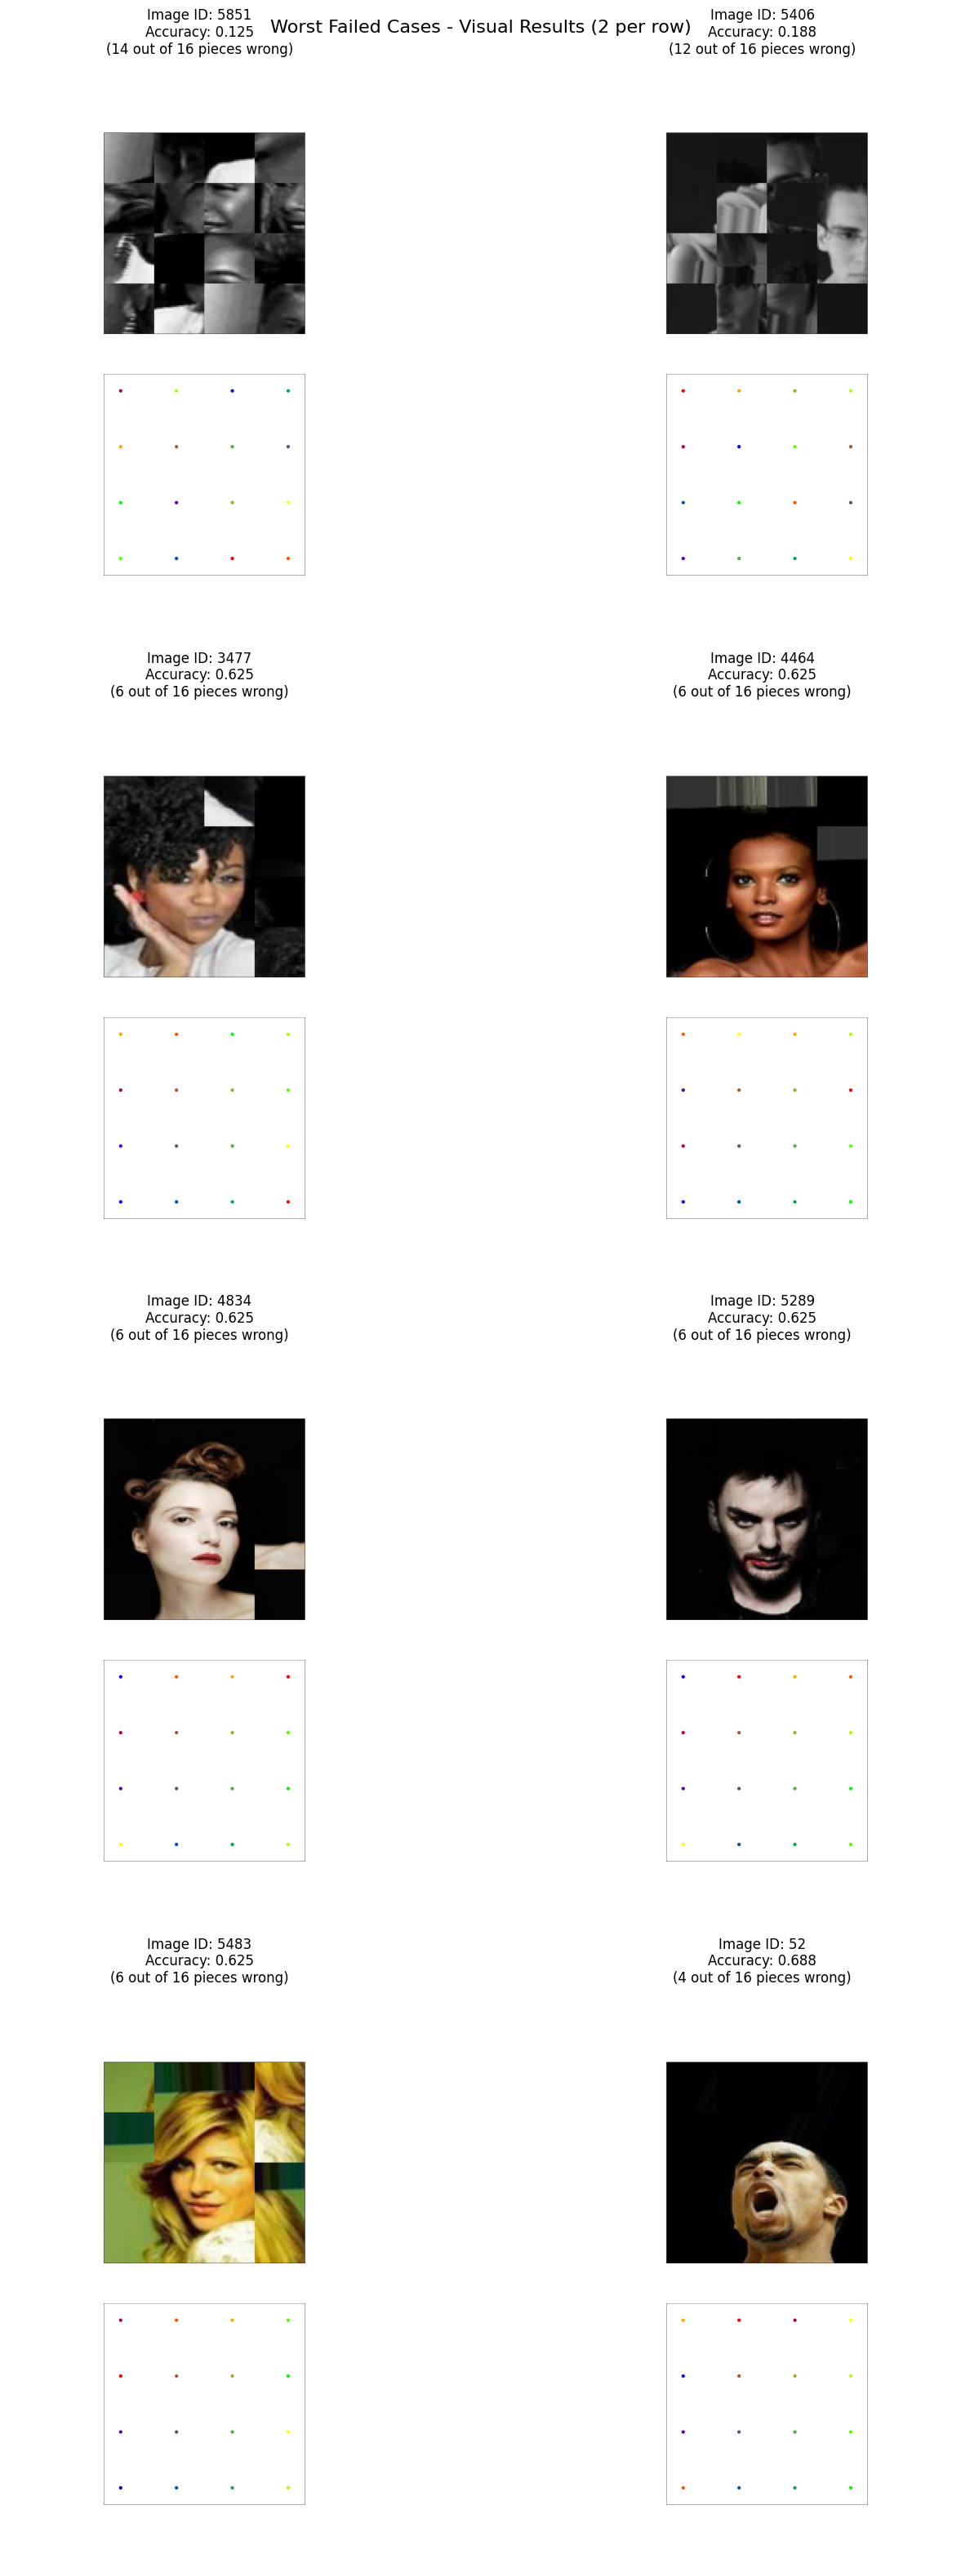


=== VISUALIZING MODERATE FAILURES (2 per row) ===


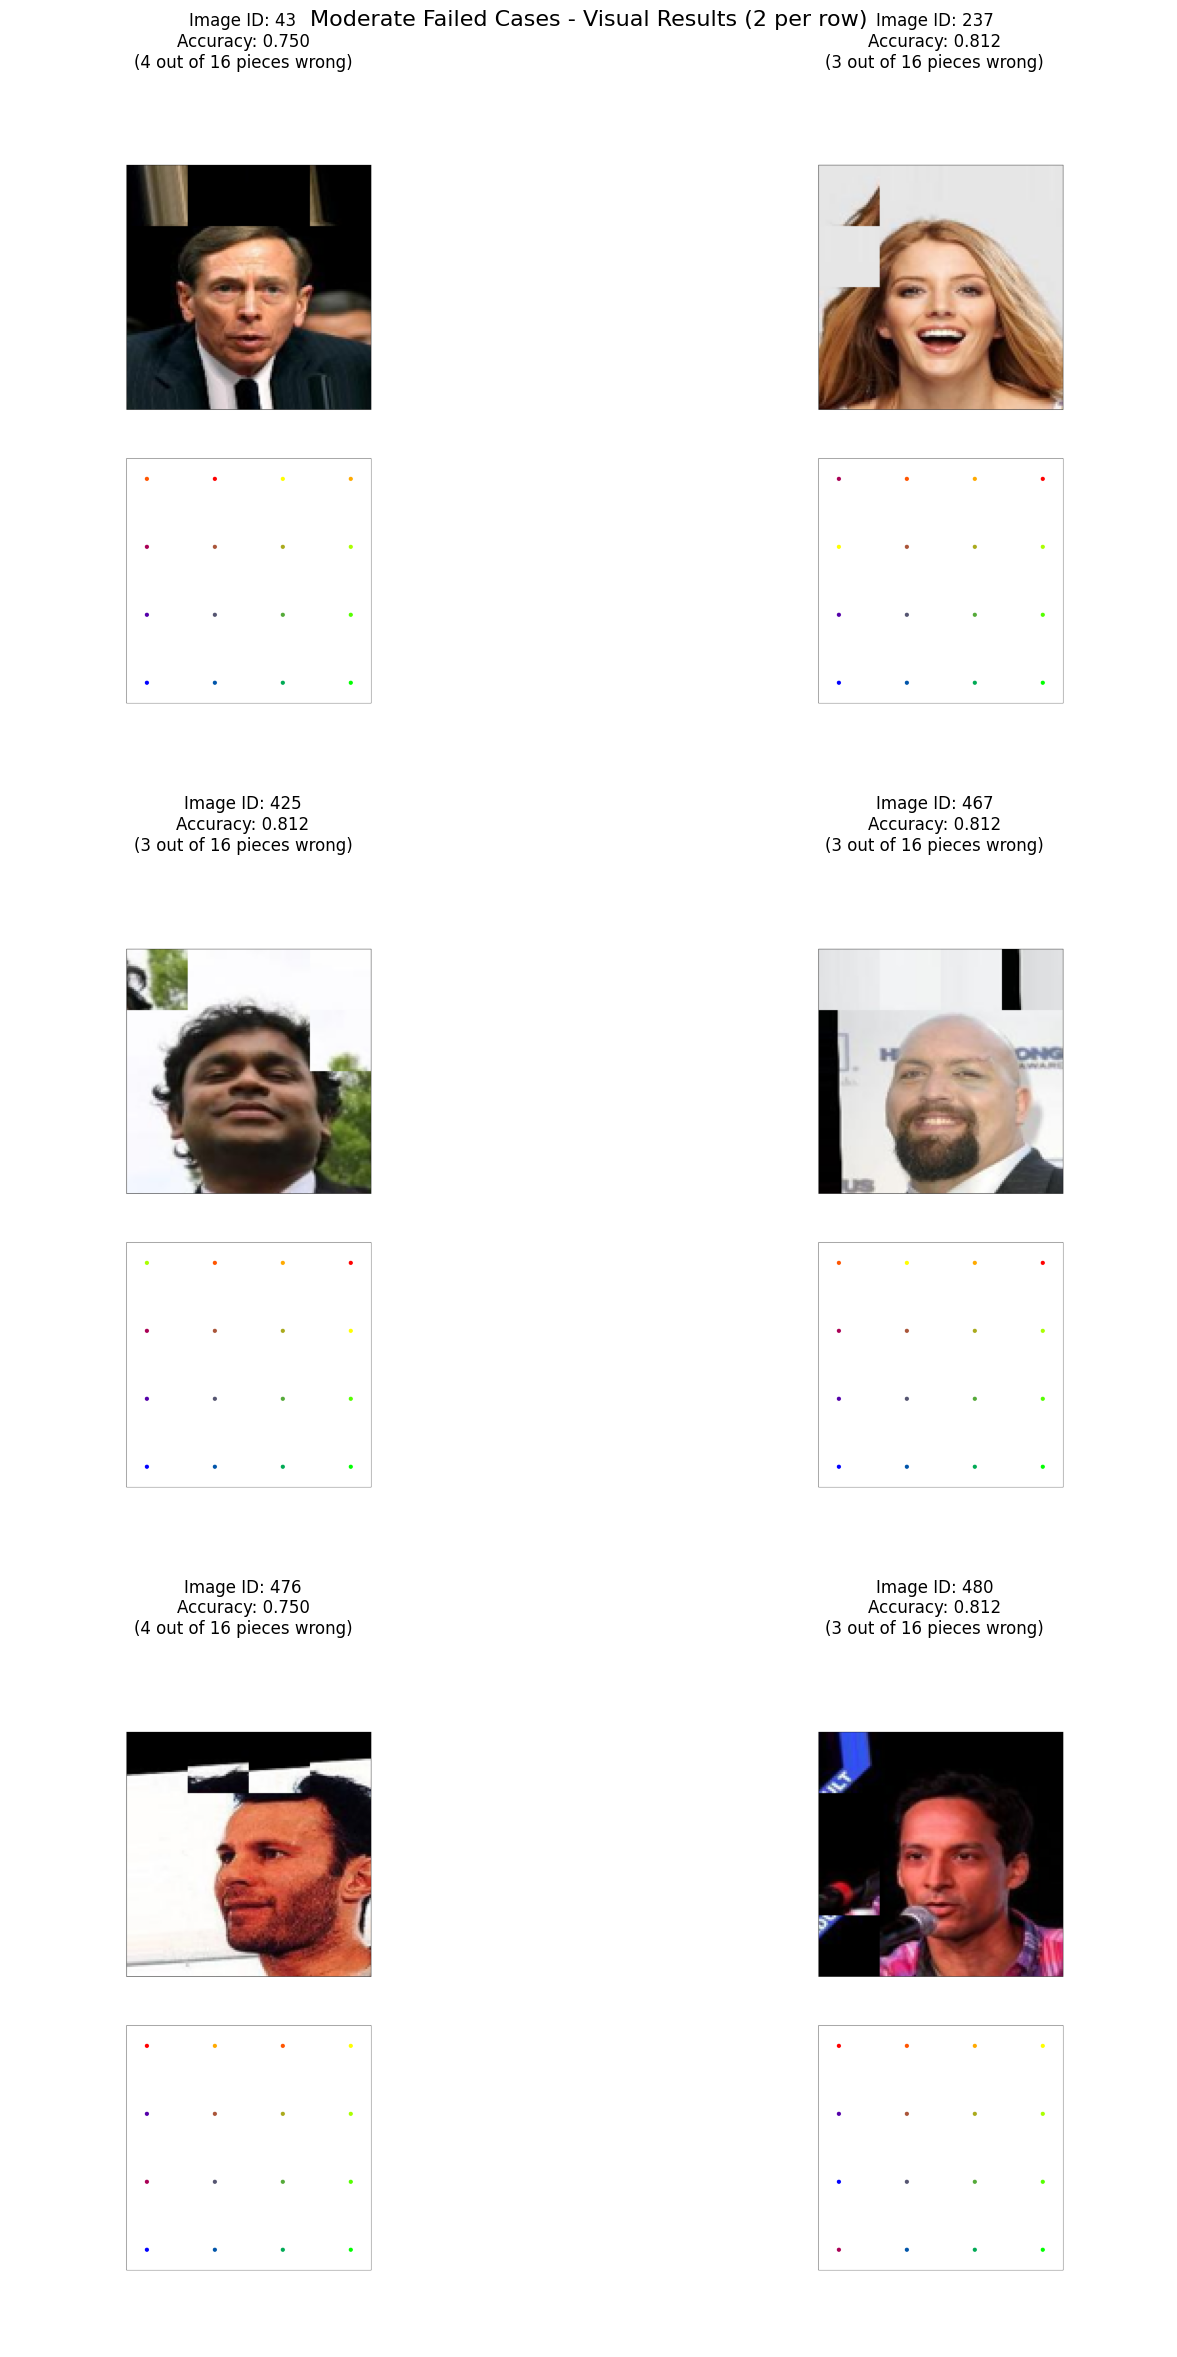


=== VISUALIZING RANDOM SAMPLE (2 per row) ===


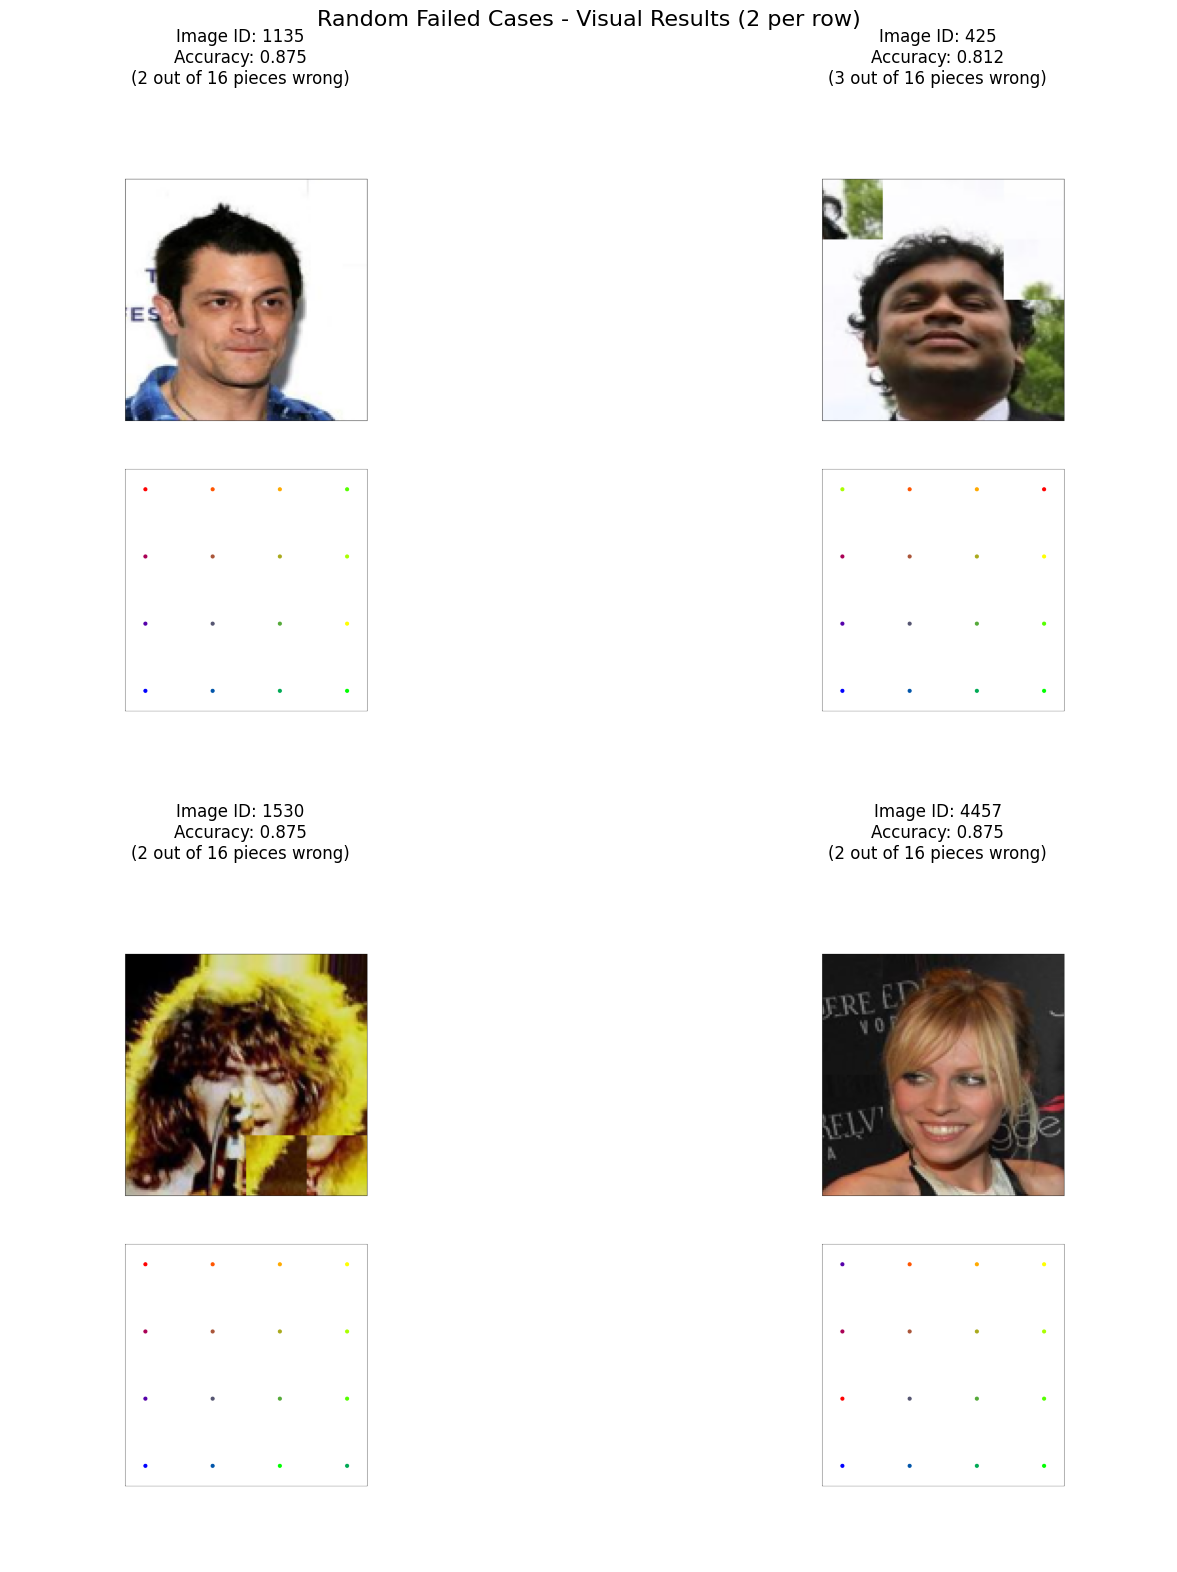

In [5]:
# Modified function for better visualization (2 per row) - Updated for correct filenames
def visualize_failed_cases(num_cases=8, case_type="worst"):
    """
    Visualize failed puzzle cases - 2 per row for better analysis
    case_type: "worst", "random", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = failed_data[failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = failed_data[failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))  # Larger figure for zoom
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # Correct filename format based on your results
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f'Image ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                  fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{case_type.title()} Failed Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Now visualize with correct filename format
print("\n=== VISUALIZING WORST CASES (2 per row) ===")
visualize_failed_cases(num_cases=8, case_type="worst")

print("\n=== VISUALIZING MODERATE FAILURES (2 per row) ===")
visualize_failed_cases(num_cases=6, case_type="moderate")

print("\n=== VISUALIZING RANDOM SAMPLE (2 per row) ===")
visualize_failed_cases(num_cases=4, case_type="random")

=== IMAGENET RESULTS COMPARISON ===
Total failed puzzles: 3784
Total test images: 50000
Failure rate: 7.57%
Success rate: 92.43%

=== IMAGENET FAILURE ANALYSIS ===
Average piece accuracy in failed cases: 0.591
Median piece accuracy in failed cases: 0.750
Worst case accuracy: 0.000
Best failed case accuracy: 0.875


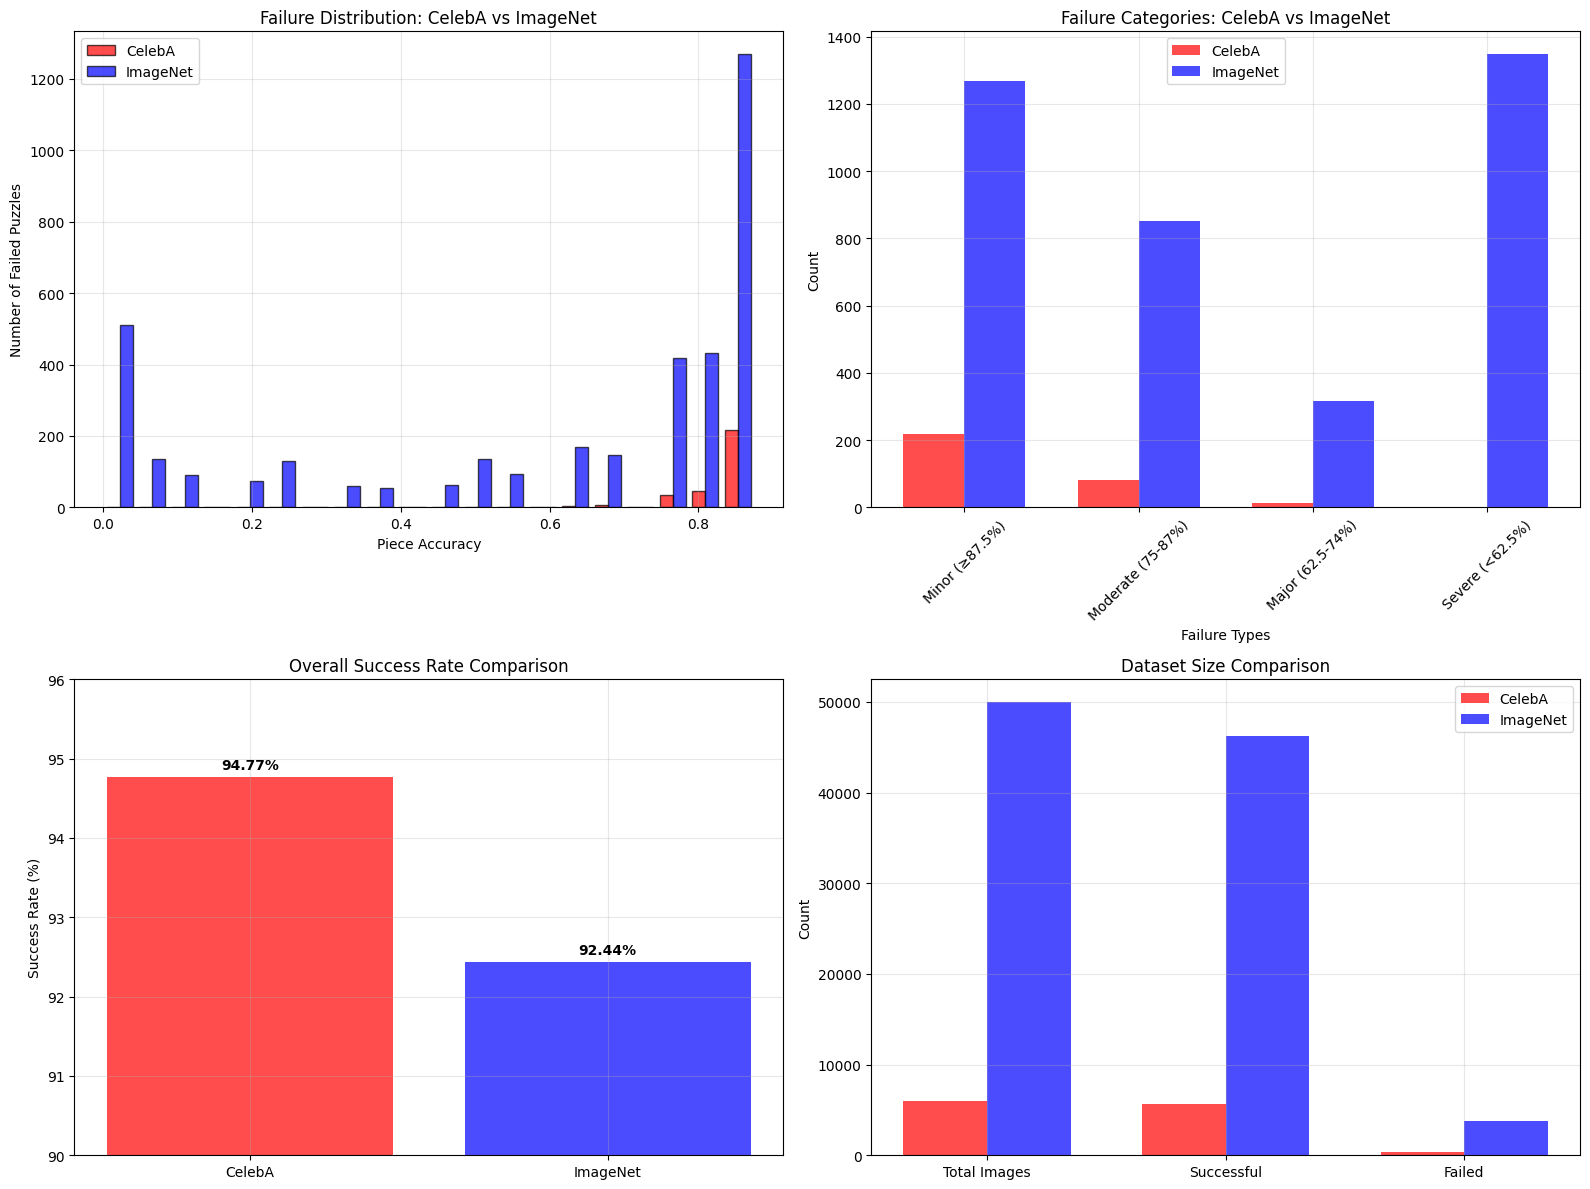


=== DATASET COMPARISON ===
Metric                    CelebA          ImageNet        Difference
------------------------------------------------------------
Total Images              5999            50000           +44001
Success Rate              94.77           92.44           -2.33
Failure Rate              5.23            7.56            +2.33
Failed Cases              313             3780            +3467

=== IMAGENET FAILURE BREAKDOWN ===
Severe (<62.5%): 1348 cases (35.6%)
Minor (≥87.5%): 1269 cases (33.5%)
Moderate (75-87%): 851 cases (22.5%)
Major (62.5-74%): 316 cases (8.4%)

=== CHECKING IMAGENET SAVED IMAGES ===
ImageNet results path not found: /home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/
Please check the path - you may need to update imagenet_results_path variable
Available result directories:
  imagenet-[(4, 4)]-300-degree:100%-virtnode:4-pskzlz-continuous-ours_dr

In [6]:
# New cell for ImageNet analysis
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load ImageNet failed puzzles data
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print("=== IMAGENET RESULTS COMPARISON ===")
print(f"Total failed puzzles: {len(imagenet_failed_data)}")
print(f"Total test images: 50000")
print(f"Failure rate: {len(imagenet_failed_data)/50000*100:.2f}%")
print(f"Success rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")

# Basic statistics
print("\n=== IMAGENET FAILURE ANALYSIS ===")
print(f"Average piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].mean():.3f}")
print(f"Median piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].median():.3f}")
print(f"Worst case accuracy: {imagenet_failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {imagenet_failed_data['piece_accuracy'].max():.3f}")

# Categorize failures (same function as before)
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

imagenet_failed_data['failure_type'] = imagenet_failed_data['piece_accuracy'].apply(categorize_failure)

# Path to ImageNet results (update this path based on your results)
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/"

# Create visualizations comparing CelebA vs ImageNet
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Compare failure distributions
ax1.hist([failed_data['piece_accuracy'], imagenet_failed_data['piece_accuracy']], 
         bins=20, alpha=0.7, label=['CelebA', 'ImageNet'], 
         color=['red', 'blue'], edgecolor='black')
ax1.set_xlabel('Piece Accuracy')
ax1.set_ylabel('Number of Failed Puzzles')
ax1.set_title('Failure Distribution: CelebA vs ImageNet')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Compare failure categories
celeba_counts = failed_data['failure_type'].value_counts()
imagenet_counts = imagenet_failed_data['failure_type'].value_counts()

categories = ['Minor (≥87.5%)', 'Moderate (75-87%)', 'Major (62.5-74%)', 'Severe (<62.5%)']
celeba_vals = [celeba_counts.get(cat, 0) for cat in categories]
imagenet_vals = [imagenet_counts.get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, celeba_vals, width, label='CelebA', color='red', alpha=0.7)
ax2.bar(x + width/2, imagenet_vals, width, label='ImageNet', color='blue', alpha=0.7)
ax2.set_xlabel('Failure Types')
ax2.set_ylabel('Count')
ax2.set_title('Failure Categories: CelebA vs ImageNet')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Success rates comparison
datasets = ['CelebA', 'ImageNet']
success_rates = [94.77, 92.44]  # From your results
failure_rates = [5.23, 7.56]

ax3.bar(datasets, success_rates, color=['red', 'blue'], alpha=0.7)
ax3.set_ylabel('Success Rate (%)')
ax3.set_title('Overall Success Rate Comparison')
ax3.set_ylim(90, 96)
for i, v in enumerate(success_rates):
    ax3.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Total numbers comparison
metrics = ['Total Images', 'Successful', 'Failed']
celeba_nums = [5999, 5686, 313]
imagenet_nums = [50000, 46220, 3780]

x = np.arange(len(metrics))
ax4.bar(x - width/2, celeba_nums, width, label='CelebA', color='red', alpha=0.7)
ax4.bar(x + width/2, imagenet_nums, width, label='ImageNet', color='blue', alpha=0.7)
ax4.set_ylabel('Count')
ax4.set_title('Dataset Size Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n=== DATASET COMPARISON ===")
print(f"{'Metric':<25} {'CelebA':<15} {'ImageNet':<15} {'Difference'}")
print("-" * 60)
print(f"{'Total Images':<25} {5999:<15} {50000:<15} {'+' + str(50000-5999)}")
print(f"{'Success Rate':<25} {94.77:<15.2f} {92.44:<15.2f} {92.44-94.77:+.2f}")
print(f"{'Failure Rate':<25} {5.23:<15.2f} {7.56:<15.2f} {7.56-5.23:+.2f}")
print(f"{'Failed Cases':<25} {313:<15} {3780:<15} {'+' + str(3780-313)}")

# ImageNet failure breakdown
print("\n=== IMAGENET FAILURE BREAKDOWN ===")
imagenet_failure_counts = imagenet_failed_data['failure_type'].value_counts()
for category, count in imagenet_failure_counts.items():
    print(f"{category}: {count} cases ({count/len(imagenet_failed_data)*100:.1f}%)")

# Function to visualize ImageNet failed cases
def visualize_imagenet_failed_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet failed puzzle cases - 2 per row for better analysis
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = imagenet_failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f'ImageNet ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                  fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {case_type.title()} Failed Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist and visualize
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    
    print("\n=== VISUALIZING IMAGENET WORST CASES ===")
    visualize_imagenet_failed_cases(num_cases=6, case_type="worst")
    
    print("\n=== VISUALIZING IMAGENET MODERATE FAILURES ===")
    visualize_imagenet_failed_cases(num_cases=4, case_type="moderate")
    
else:
    print(f"ImageNet results path not found: {imagenet_results_path}")
    print("Please check the path - you may need to update imagenet_results_path variable")
    
    # Try to find the correct path
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("Available result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"  {d}")

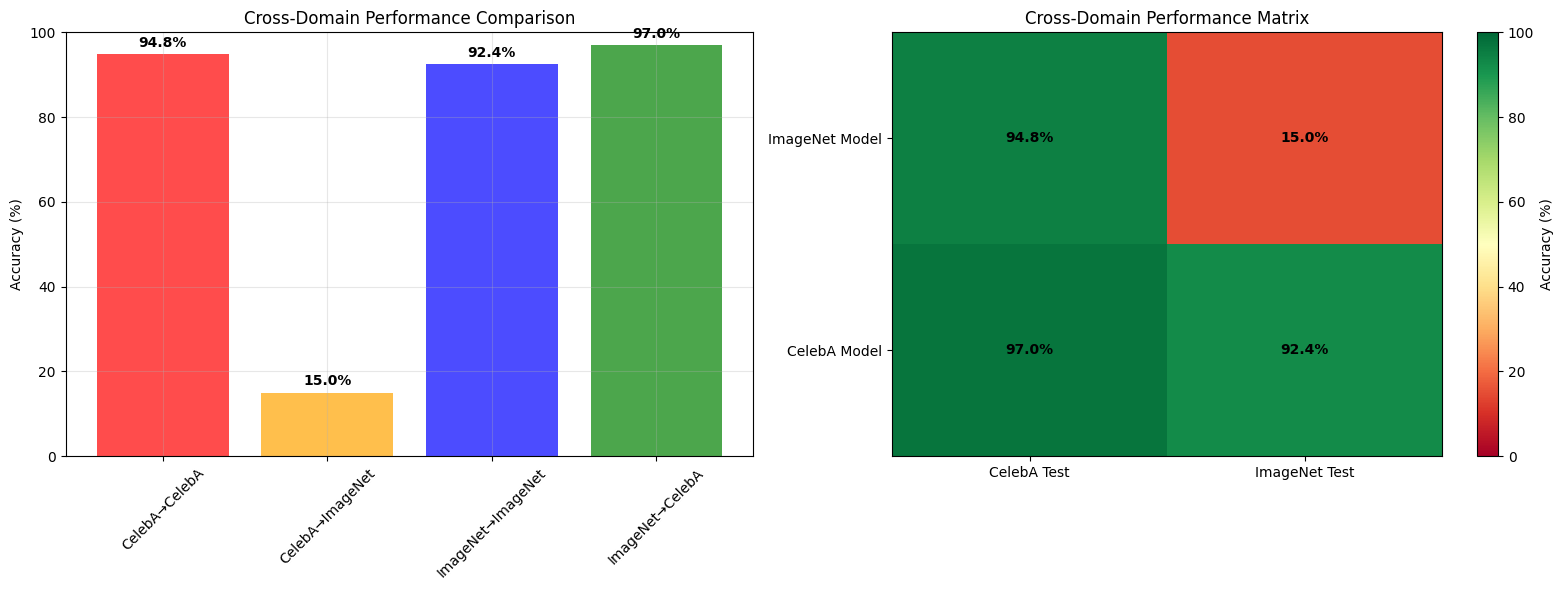

=== CROSS-DOMAIN ANALYSIS ===
Key Finding: ImageNet model generalizes BETTER to faces than face model to objects!
ImageNet → CelebA: 96.95% (BEST performance overall)
CelebA → CelebA: 94.77% (Original baseline)
Improvement: +2.18% when using ImageNet model on faces


In [7]:
# Add this cell to visualize the cross-domain results
import matplotlib.pyplot as plt
import numpy as np

# Cross-domain performance matrix
performance_data = {
    'CelebA → CelebA': 94.77,
    'CelebA → ImageNet': 15.0,
    'ImageNet → ImageNet': 92.44,
    'ImageNet → CelebA': 96.95
}

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Cross-domain performance bar chart
models = ['CelebA→CelebA', 'CelebA→ImageNet', 'ImageNet→ImageNet', 'ImageNet→CelebA']
accuracies = [94.77, 15.0, 92.44, 96.95]
colors = ['red', 'orange', 'blue', 'green']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Cross-Domain Performance Comparison')
ax1.set_ylim(0, 100)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Performance matrix heatmap
matrix = np.array([[94.77, 15.0], [96.95, 92.44]])
im = ax2.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{matrix[i, j]:.1f}%',
                       ha="center", va="center", color="black", fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['CelebA Test', 'ImageNet Test'])
ax2.set_yticklabels(['ImageNet Model', 'CelebA Model'])
ax2.set_title('Cross-Domain Performance Matrix')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Accuracy (%)')

plt.tight_layout()
plt.show()

print("=== CROSS-DOMAIN ANALYSIS ===")
print("Key Finding: ImageNet model generalizes BETTER to faces than face model to objects!")
print(f"ImageNet → CelebA: {96.95:.2f}% (BEST performance overall)")
print(f"CelebA → CelebA: {94.77:.2f}% (Original baseline)")
print(f"Improvement: +{96.95-94.77:.2f}% when using ImageNet model on faces")

=== IMAGENET VISUAL ANALYSIS ===
Total ImageNet failed puzzles: 10808

=== CHECKING IMAGENET SAVED IMAGES ===
Total files in ImageNet results: 10423
Final images found: 336
Example filenames:
  238_final.png
  62_final.png
  177_final.png
  95_final.png
  223_final.png

=== VISUALIZING IMAGENET WORST FAILURES ===


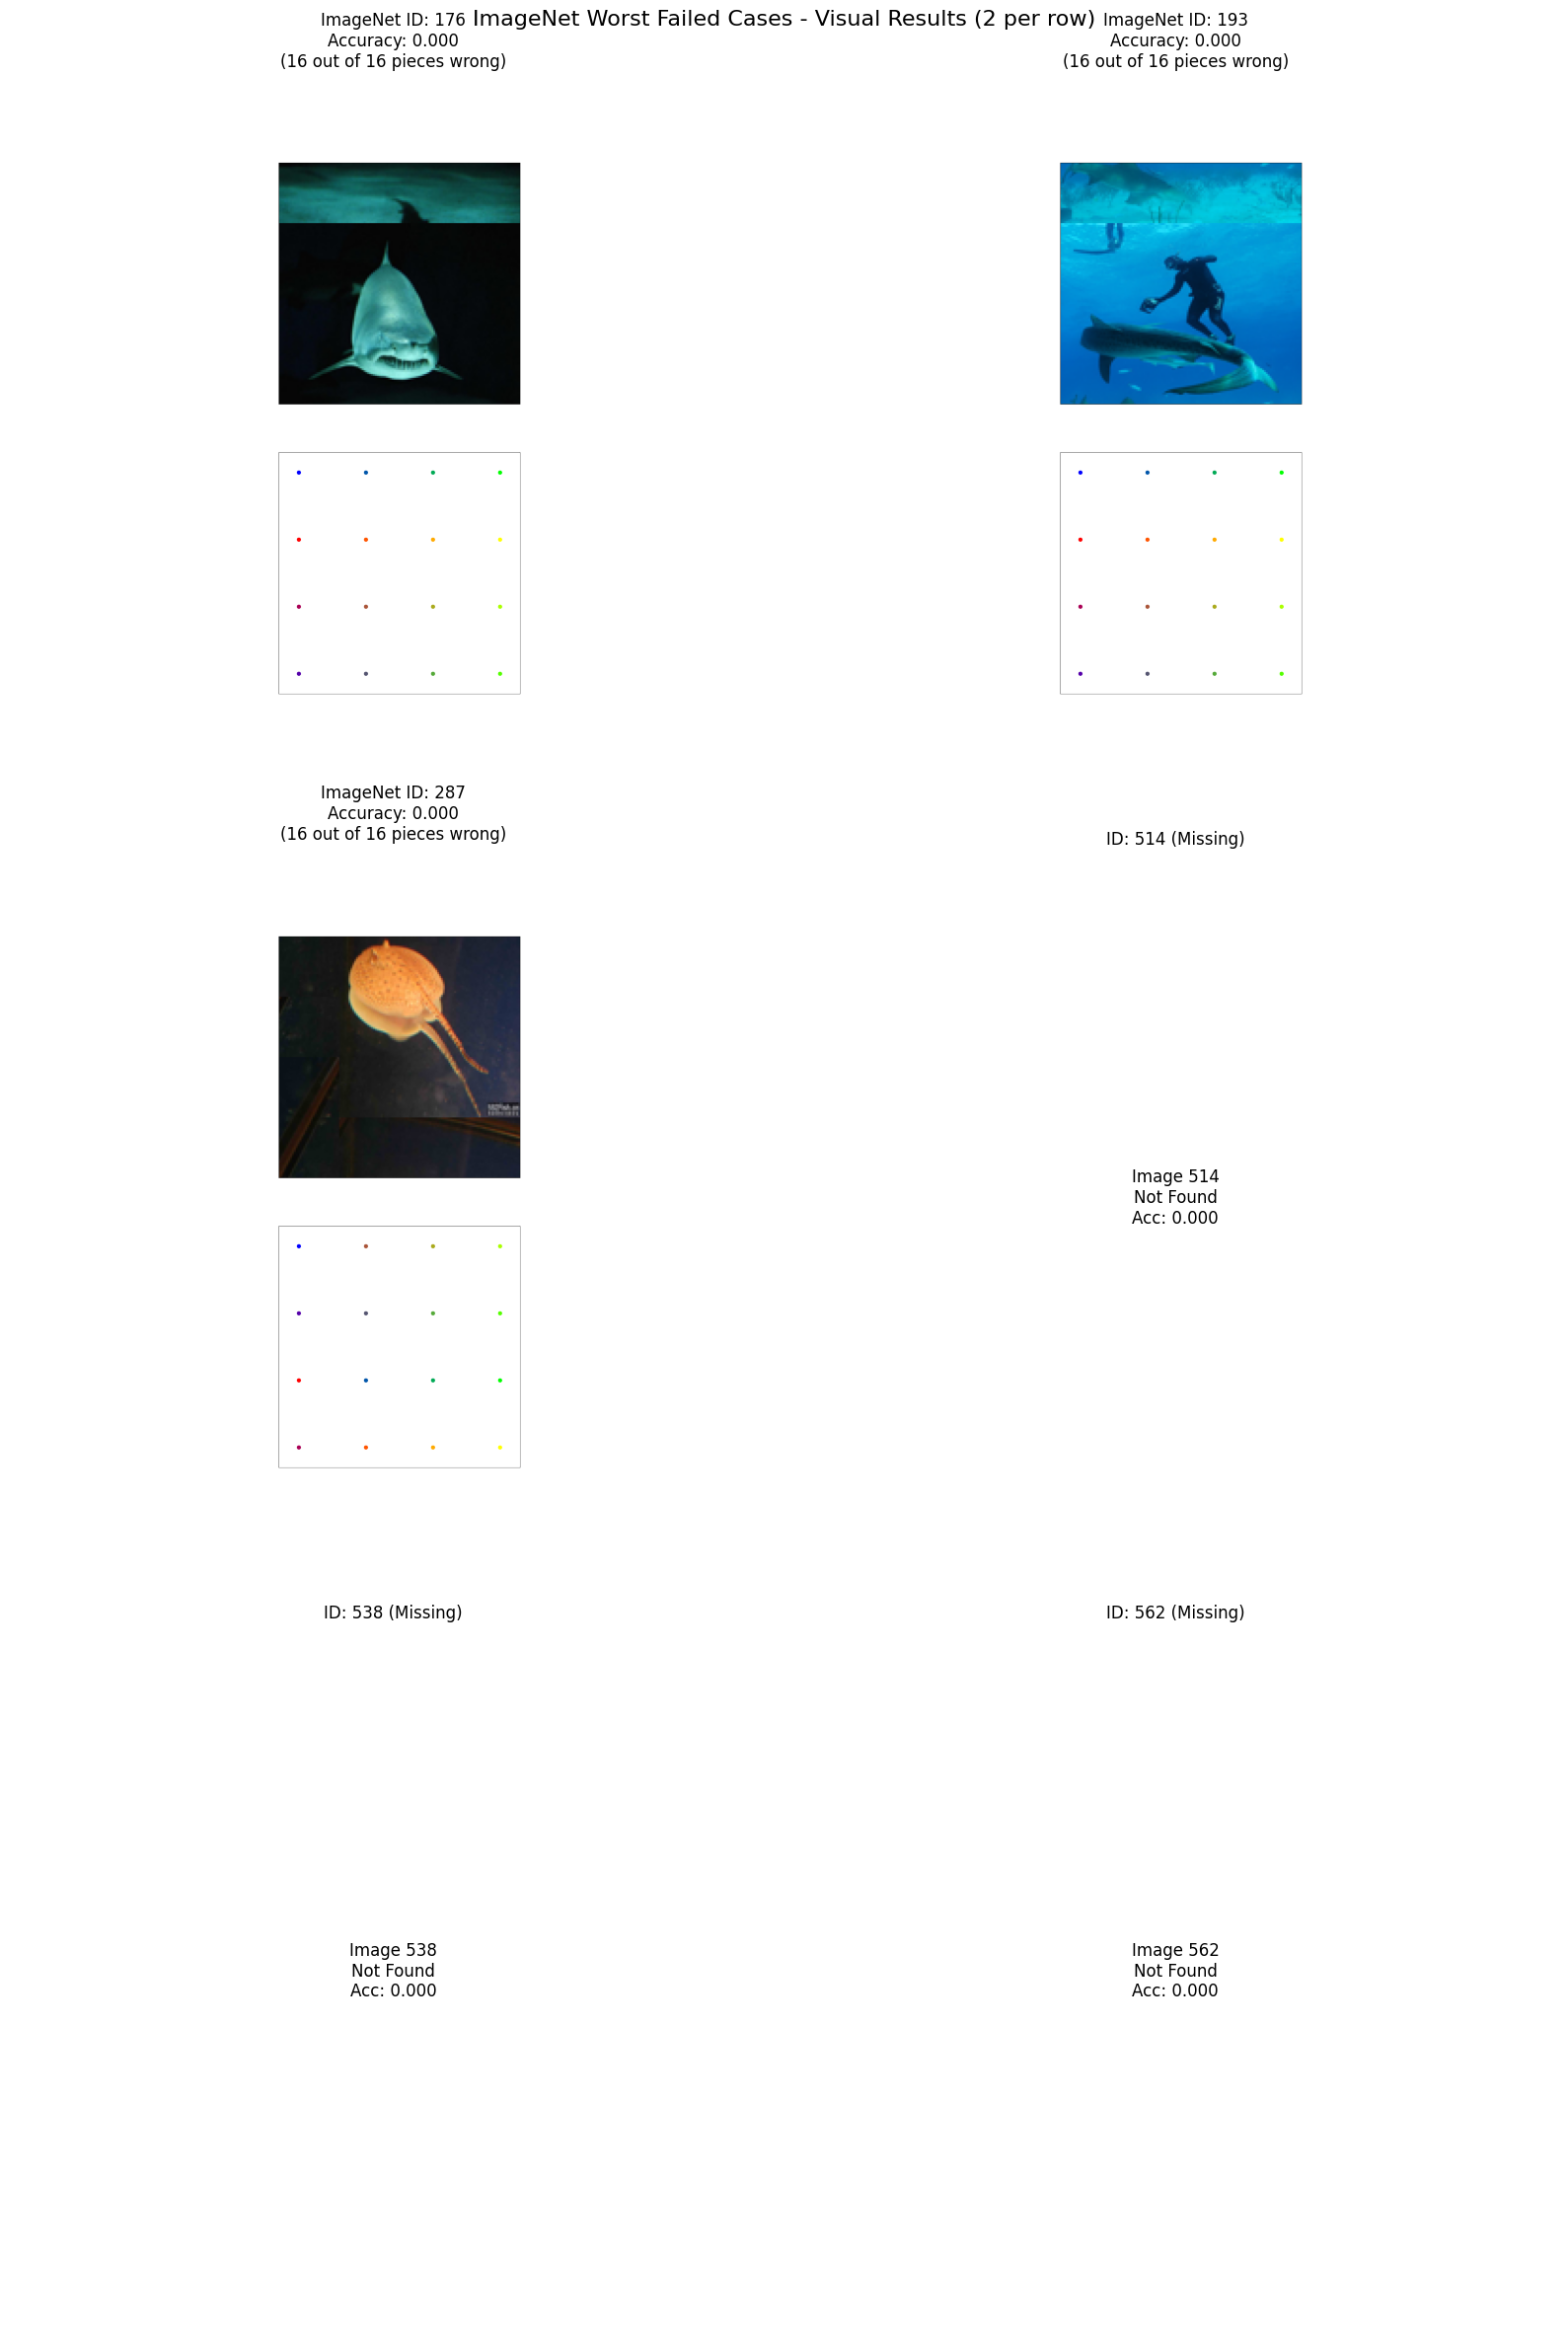


=== VISUALIZING IMAGENET BEST FAILURES ===


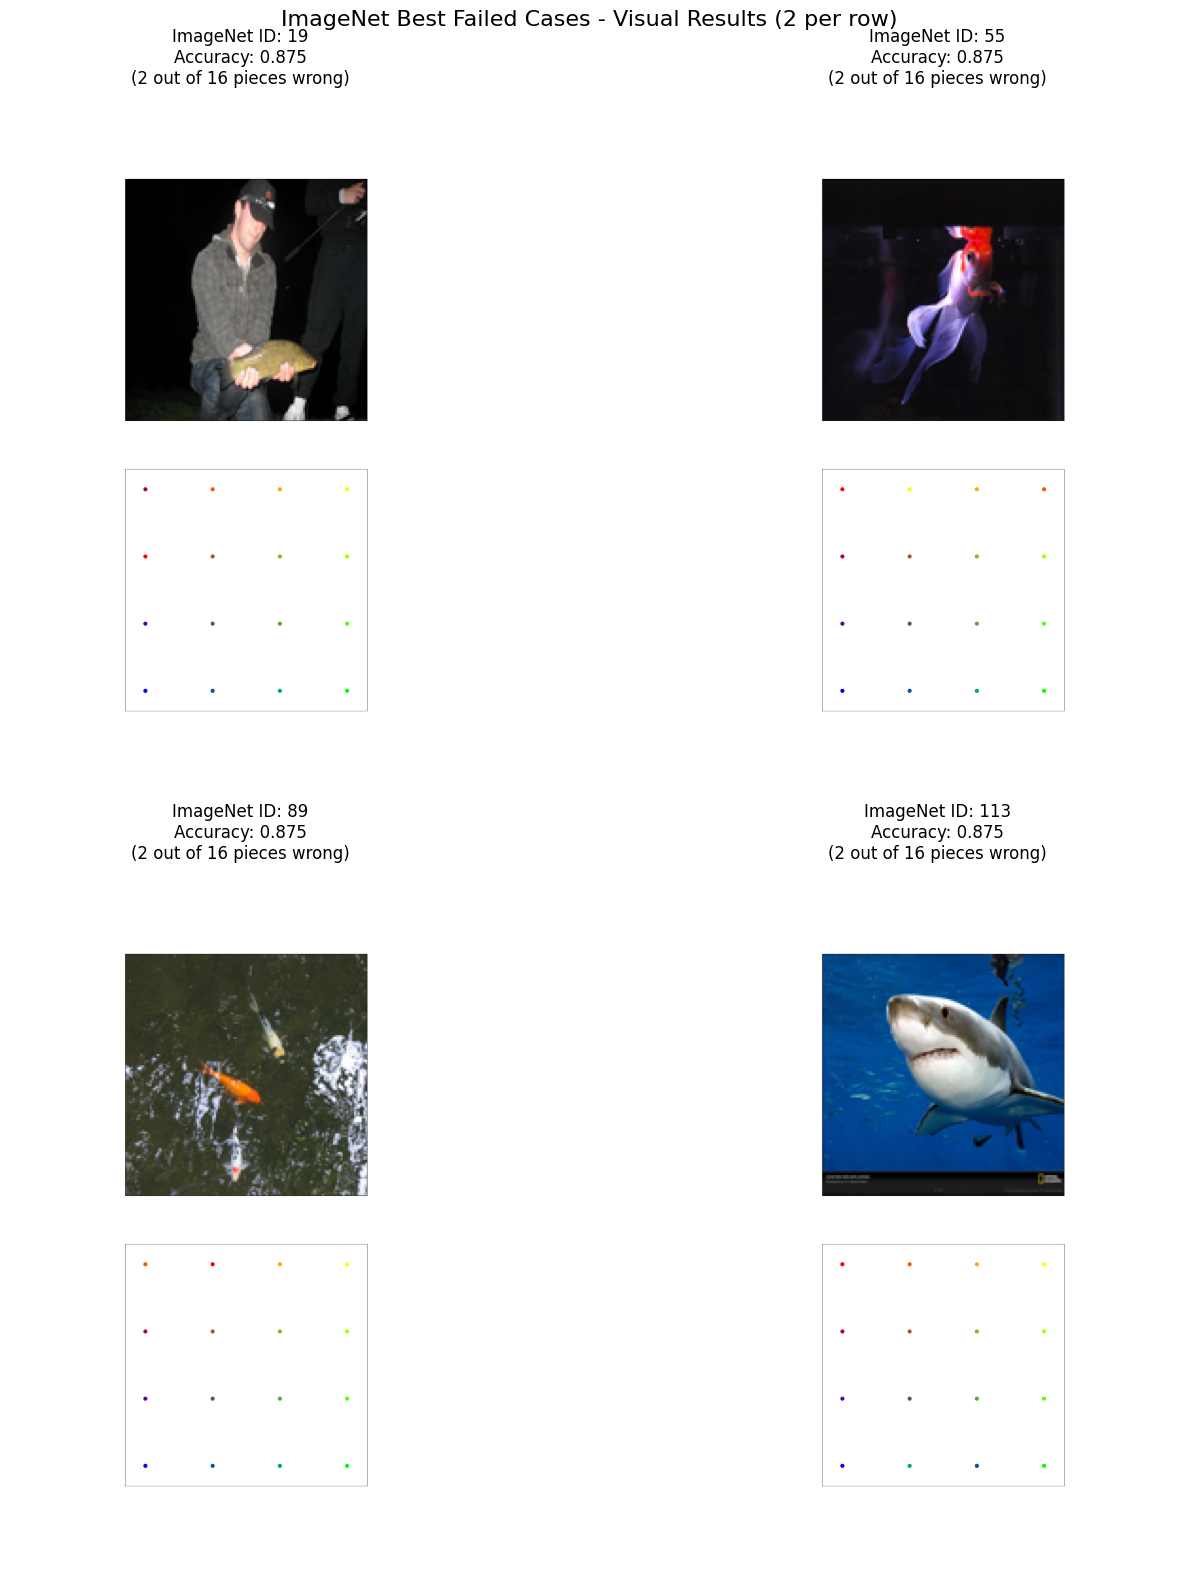


=== VISUALIZING IMAGENET SUCCESSFUL CASES ===


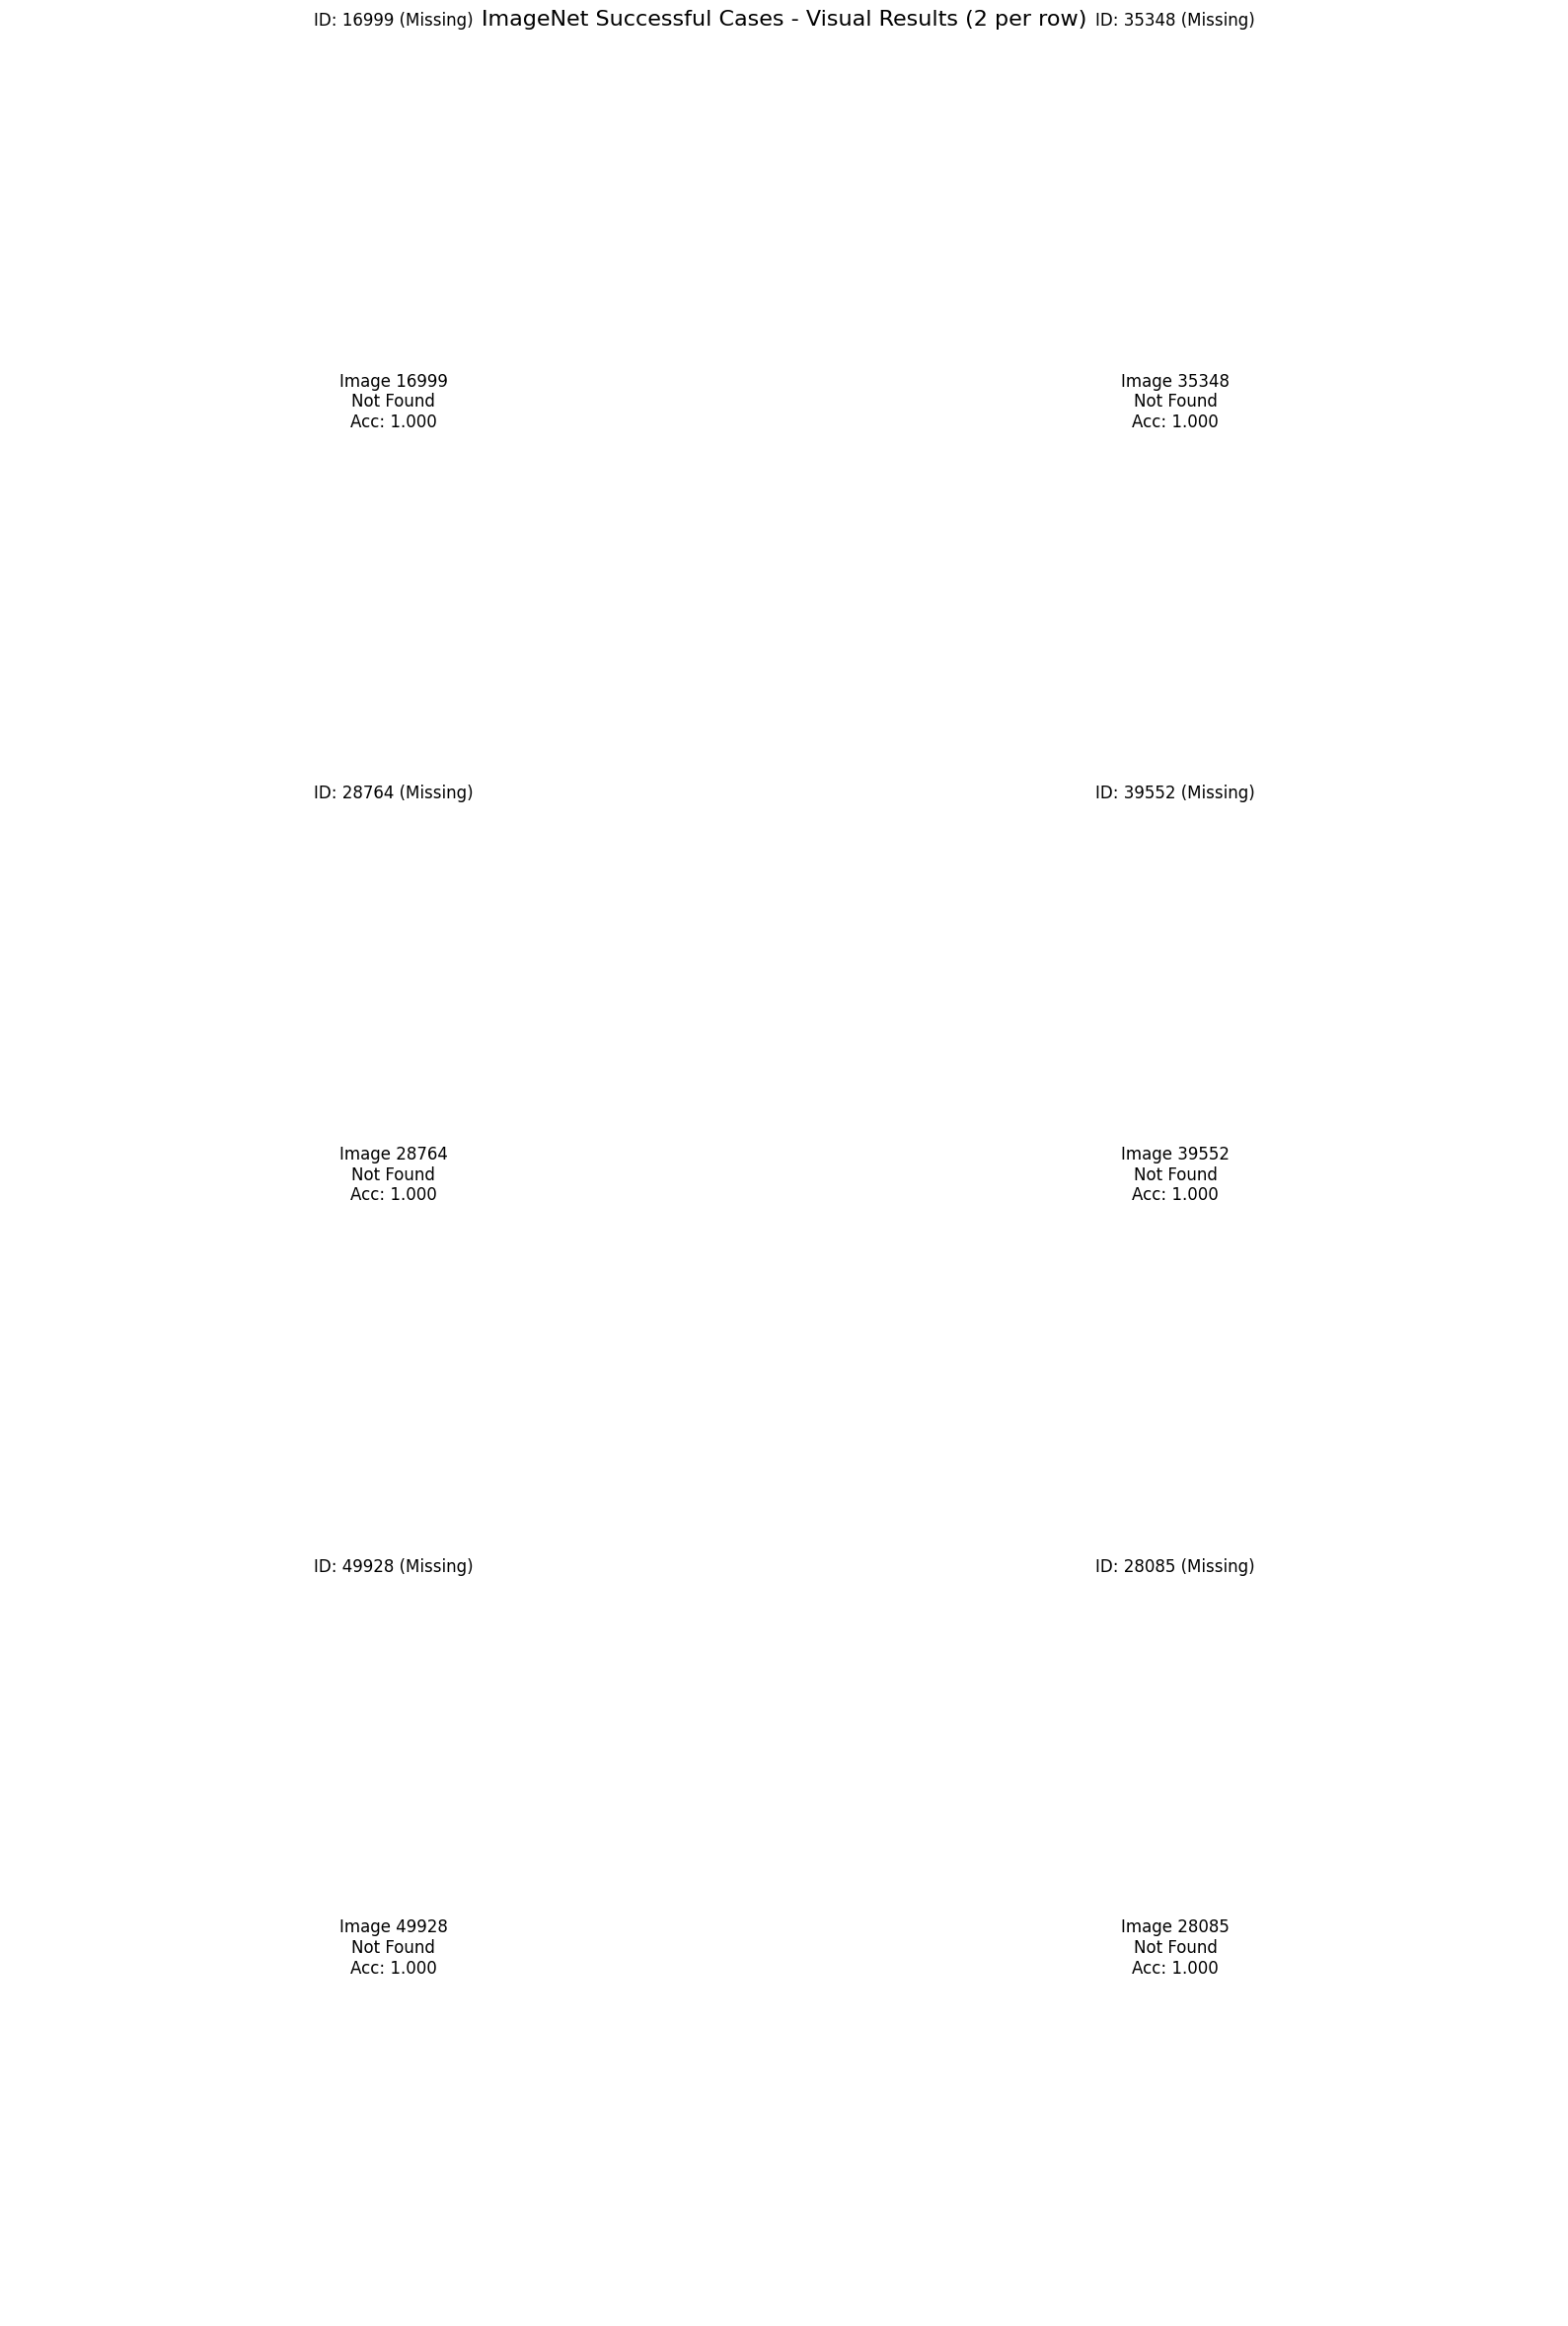


=== VISUALIZING RANDOM IMAGENET FAILURES ===


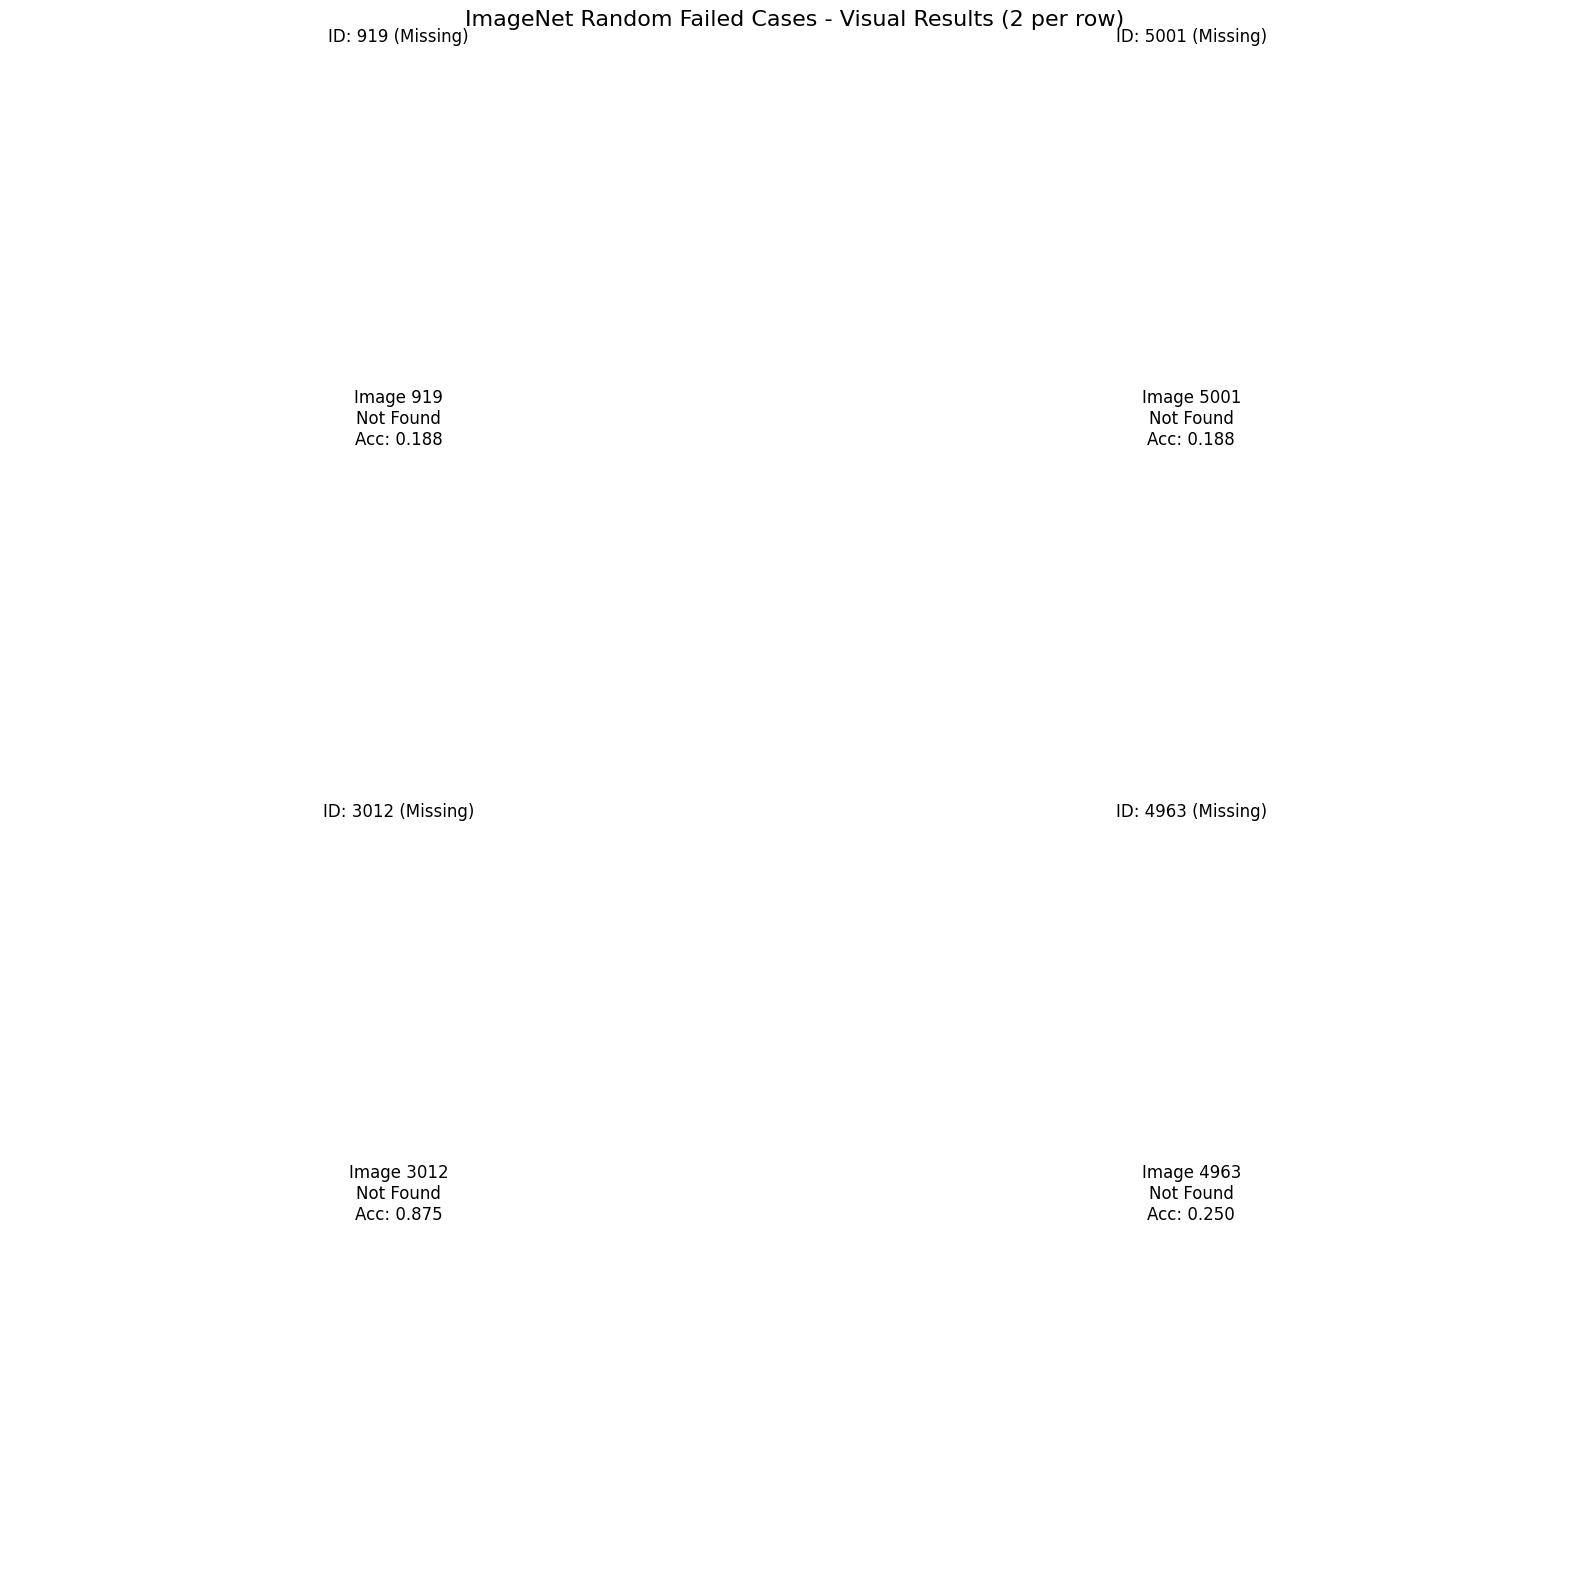

In [7]:
# Updated ImageNet Visual Analysis with correct path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

# Load the ImageNet failed puzzles data
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print("=== IMAGENET VISUAL ANALYSIS ===")
print(f"Total ImageNet failed puzzles: {len(imagenet_failed_data)}")

# Corrected path to ImageNet results
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-prrumw-continuous-ours_dropout-arch-transformer/test/"

# Function to visualize ImageNet failed and successful cases
def visualize_imagenet_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet puzzle cases - 2 per row for better analysis
    case_type: "worst", "best_failed", "random_failed", "successful"
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
        title_prefix = "Worst Failed"
    elif case_type == "best_failed":
        cases_to_show = imagenet_failed_data.nlargest(num_cases, 'piece_accuracy')
        title_prefix = "Best Failed"
    elif case_type == "random_failed":
        cases_to_show = imagenet_failed_data.sample(min(num_cases, len(imagenet_failed_data)))
        title_prefix = "Random Failed"
    elif case_type == "successful":
        # For successful cases, we need to generate some random IDs that aren't in failed_data
        all_ids = set(range(50000))
        failed_ids = set(imagenet_failed_data['image_id'].values)
        successful_ids = list(all_ids - failed_ids)
        random_successful = np.random.choice(successful_ids, min(num_cases, len(successful_ids)), replace=False)
        
        # Create a dataframe for successful cases
        cases_to_show = pd.DataFrame({
            'image_id': random_successful,
            'piece_accuracy': [1.0] * len(random_successful),  # Perfect accuracy
            'perfect_puzzle': [True] * len(random_successful)
        })
        title_prefix = "Successful"
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc)) if piece_acc < 1.0 else 0
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                
                if case_type == "successful":
                    axes[idx].set_title(f'ImageNet ID: {image_id}\nPERFECT SOLUTION\n(All 16 pieces correct)', 
                                      fontsize=12, pad=10, color='green')
                else:
                    axes[idx].set_title(f'ImageNet ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                      fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {title_prefix} Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    
    # Show some example filenames
    print("Example filenames:")
    for i, fname in enumerate(final_images[:5]):
        print(f"  {fname}")
    
    # Visualize different types of cases
    print("\n=== VISUALIZING IMAGENET WORST FAILURES ===")
    visualize_imagenet_cases(num_cases=6, case_type="worst")
    
    print("\n=== VISUALIZING IMAGENET BEST FAILURES ===")
    visualize_imagenet_cases(num_cases=4, case_type="best_failed")
    
    print("\n=== VISUALIZING IMAGENET SUCCESSFUL CASES ===")
    visualize_imagenet_cases(num_cases=6, case_type="successful")
    
    print("\n=== VISUALIZING RANDOM IMAGENET FAILURES ===")
    visualize_imagenet_cases(num_cases=4, case_type="random_failed")
    
else:
    print(f"ImageNet results path not found: {imagenet_results_path}")
    print("Checking for available ImageNet result directories...")
    
    # Try to find any ImageNet result directories
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("\nAvailable result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"  {d}")

=== COMPLETE IMAGENET ANALYSIS ===
Total ImageNet failed puzzles: 3829
Total test images: 50000
Success rate: 92.34%
Failure rate: 7.66%

Average piece accuracy in failed cases: 0.592
Worst case accuracy: 0.000
Best failed case accuracy: 0.875

=== IMAGENET FAILURE BREAKDOWN ===
Severe (<62.5%): 1356 cases (35.4%)
Minor (≥87.5%): 1290 cases (33.7%)
Moderate (75-87%): 863 cases (22.5%)
Major (62.5-74%): 320 cases (8.4%)

=== CHECKING IMAGENET SAVED IMAGES ===
Total files in ImageNet results: 10423
Final puzzle images found: 336
Example filenames:
  238_final.png
  62_final.png
  177_final.png
  95_final.png
  223_final.png

🔥 WORST IMAGENET FAILURES (Completely Broken)


/tmp/ipykernel_453182/427742624.py:136: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


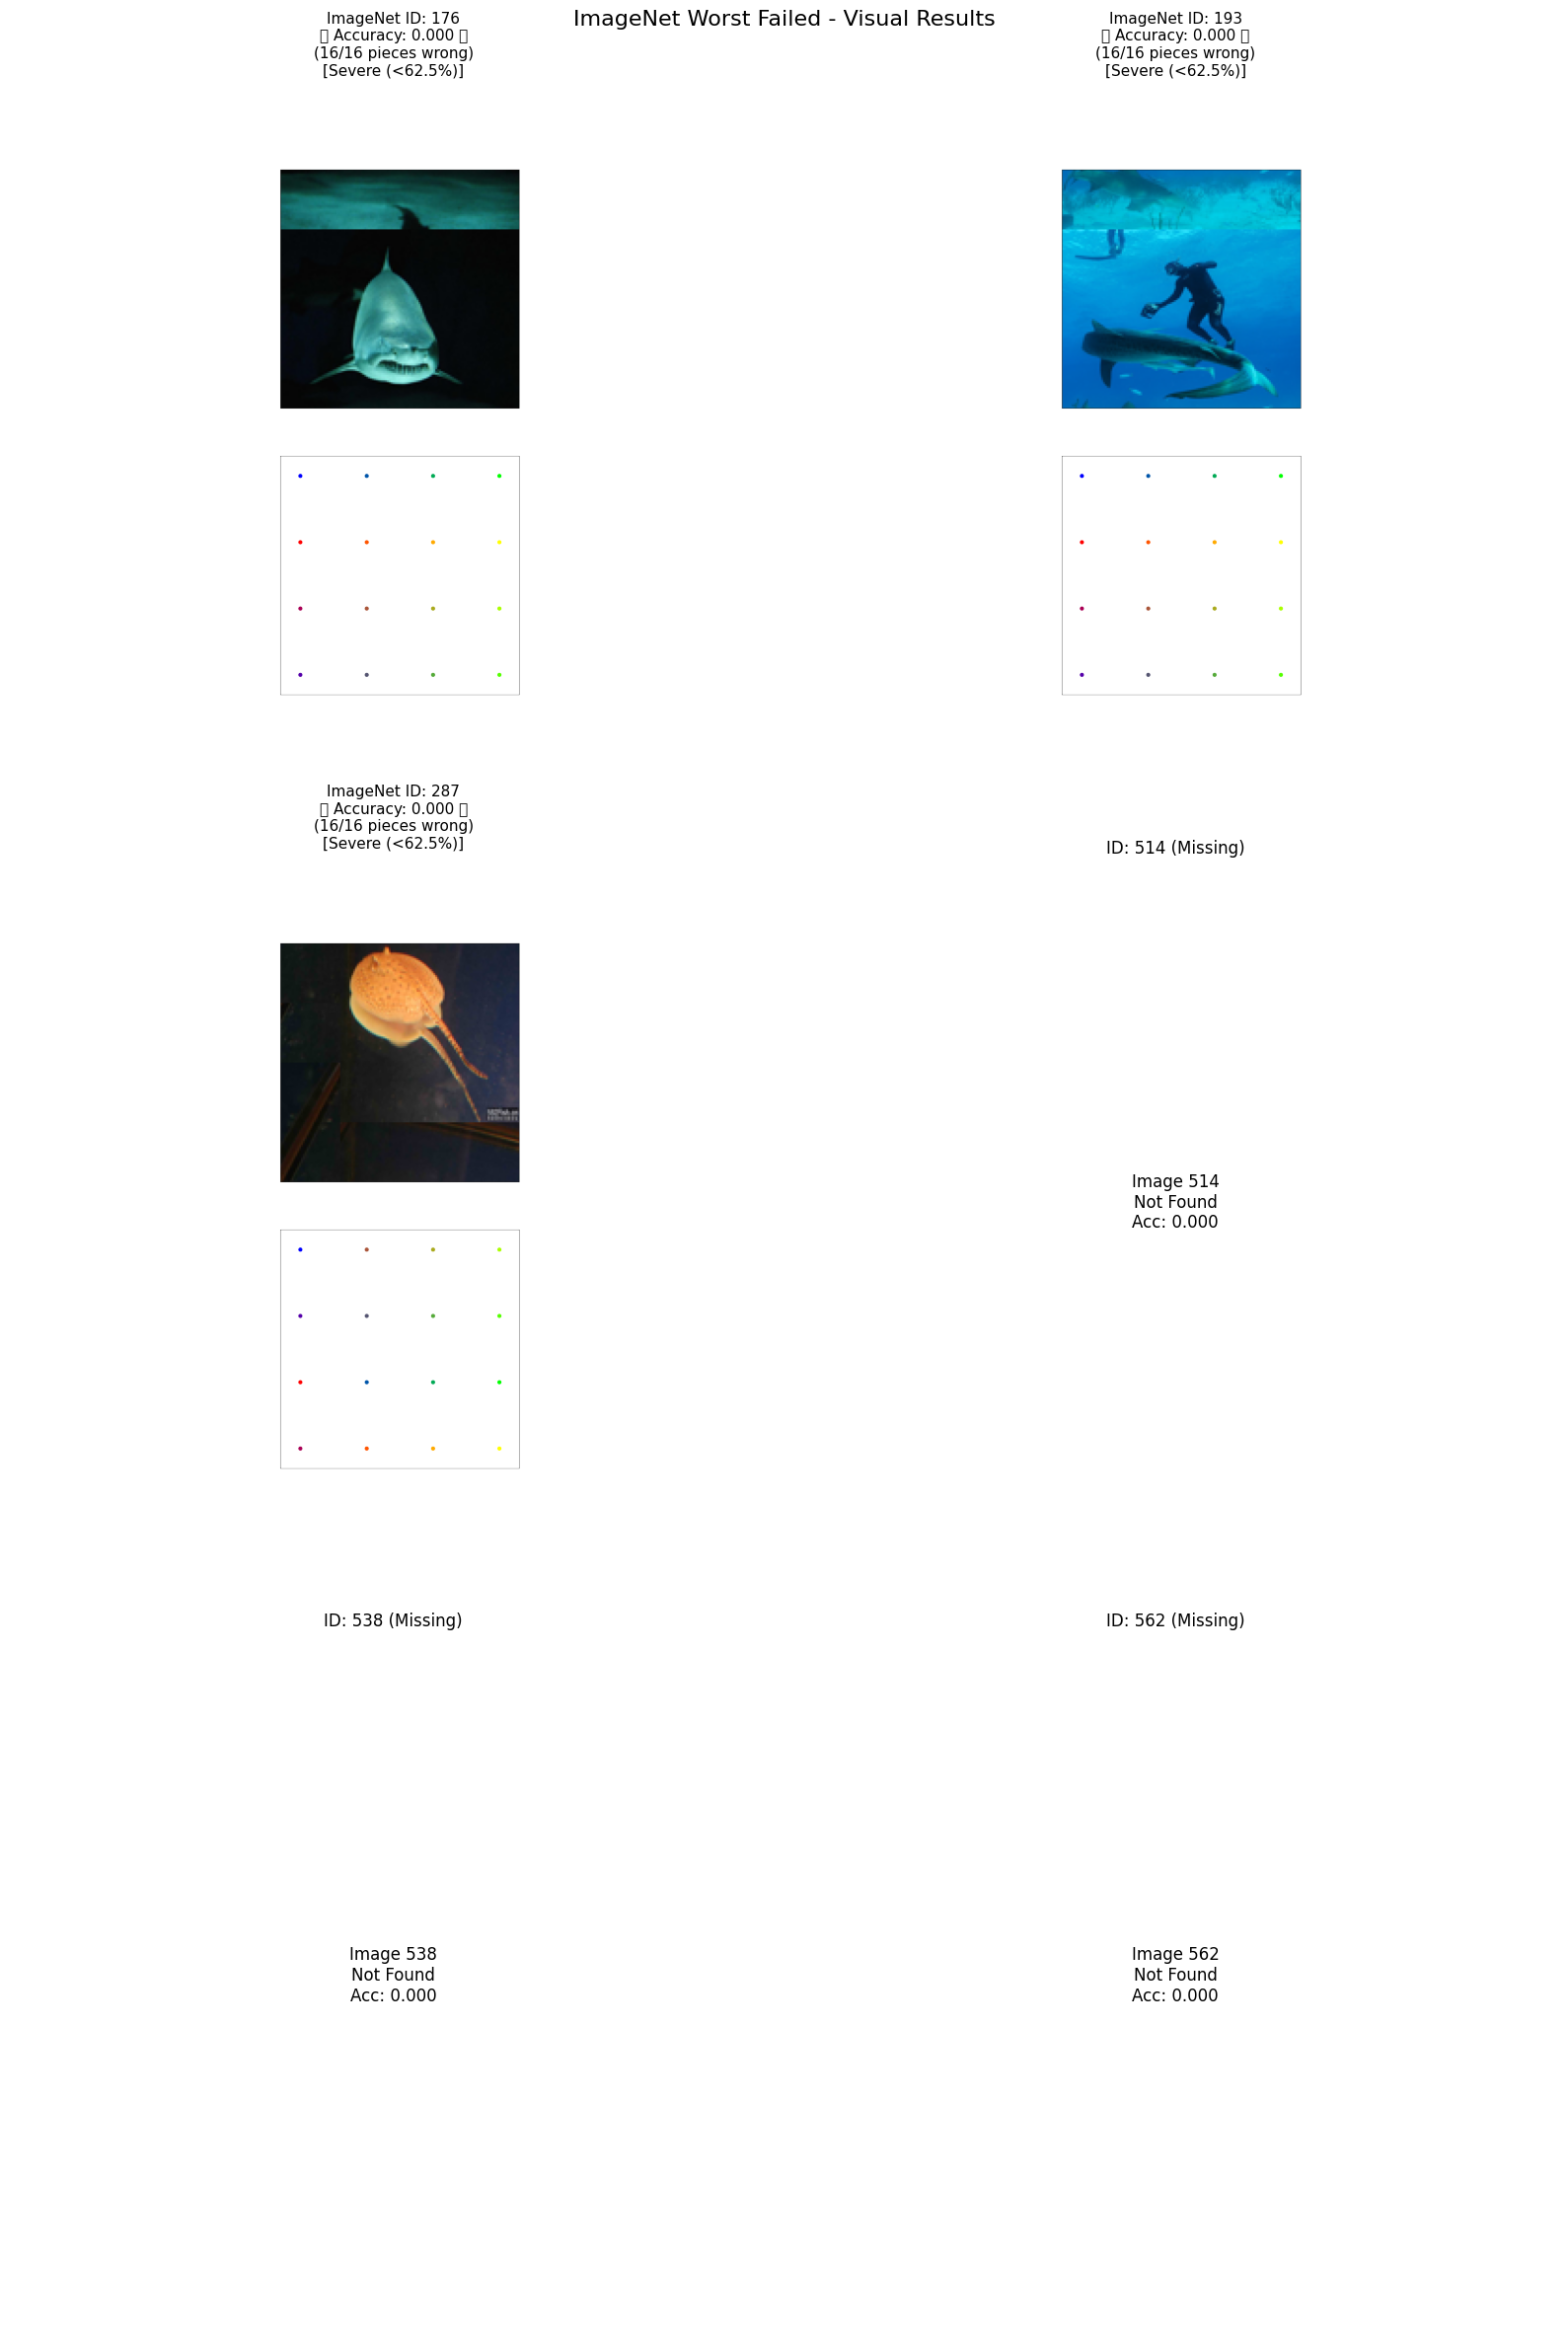


⚠️  SEVERE IMAGENET FAILURES (6+ pieces wrong)


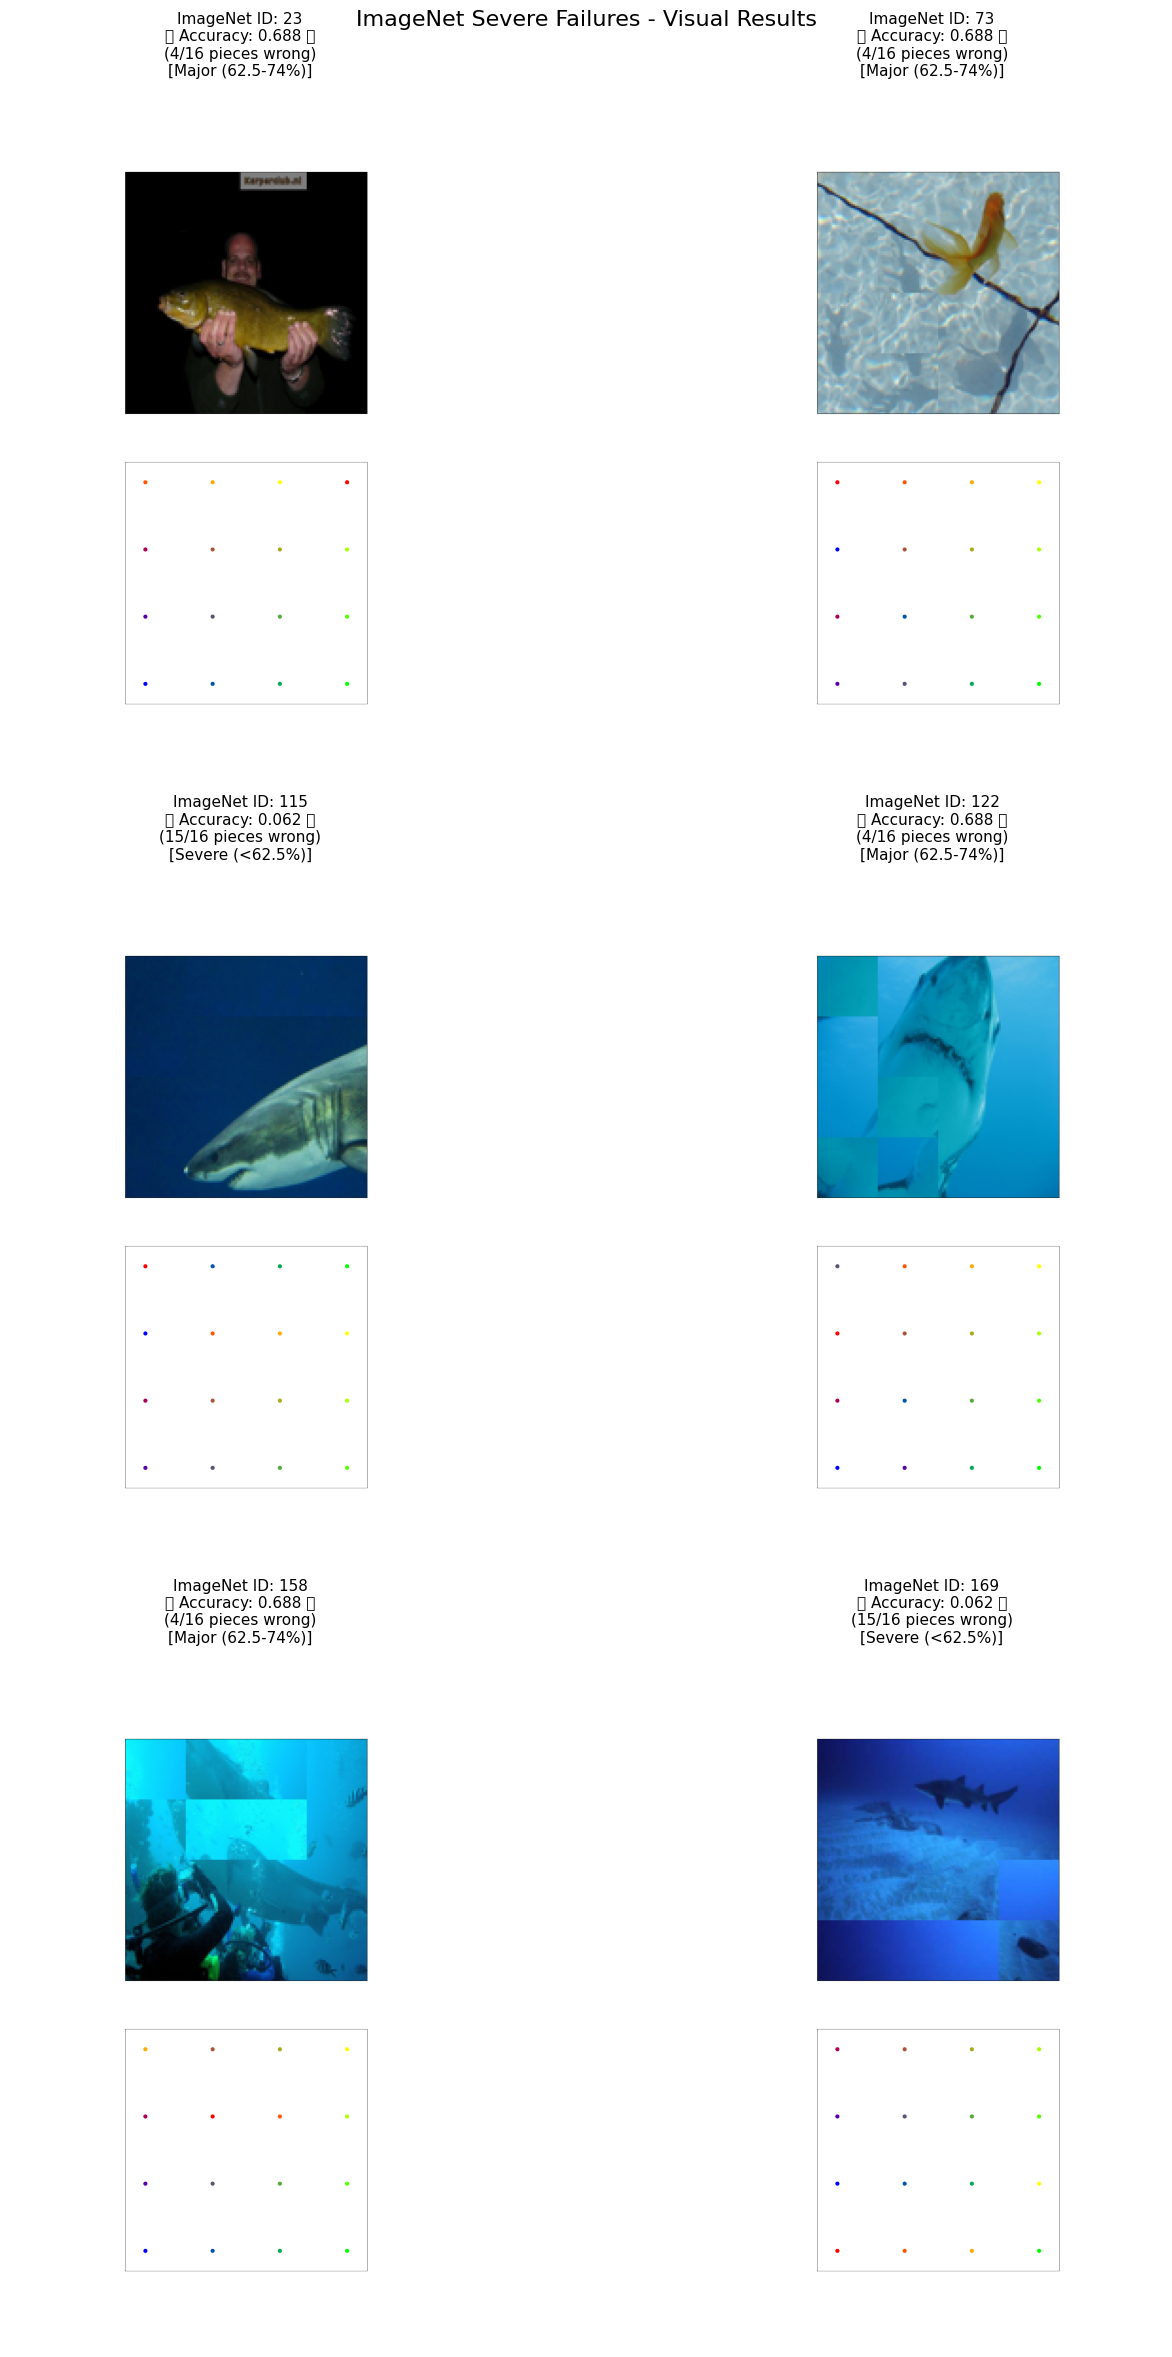


📊 MODERATE IMAGENET FAILURES (2-4 pieces wrong)


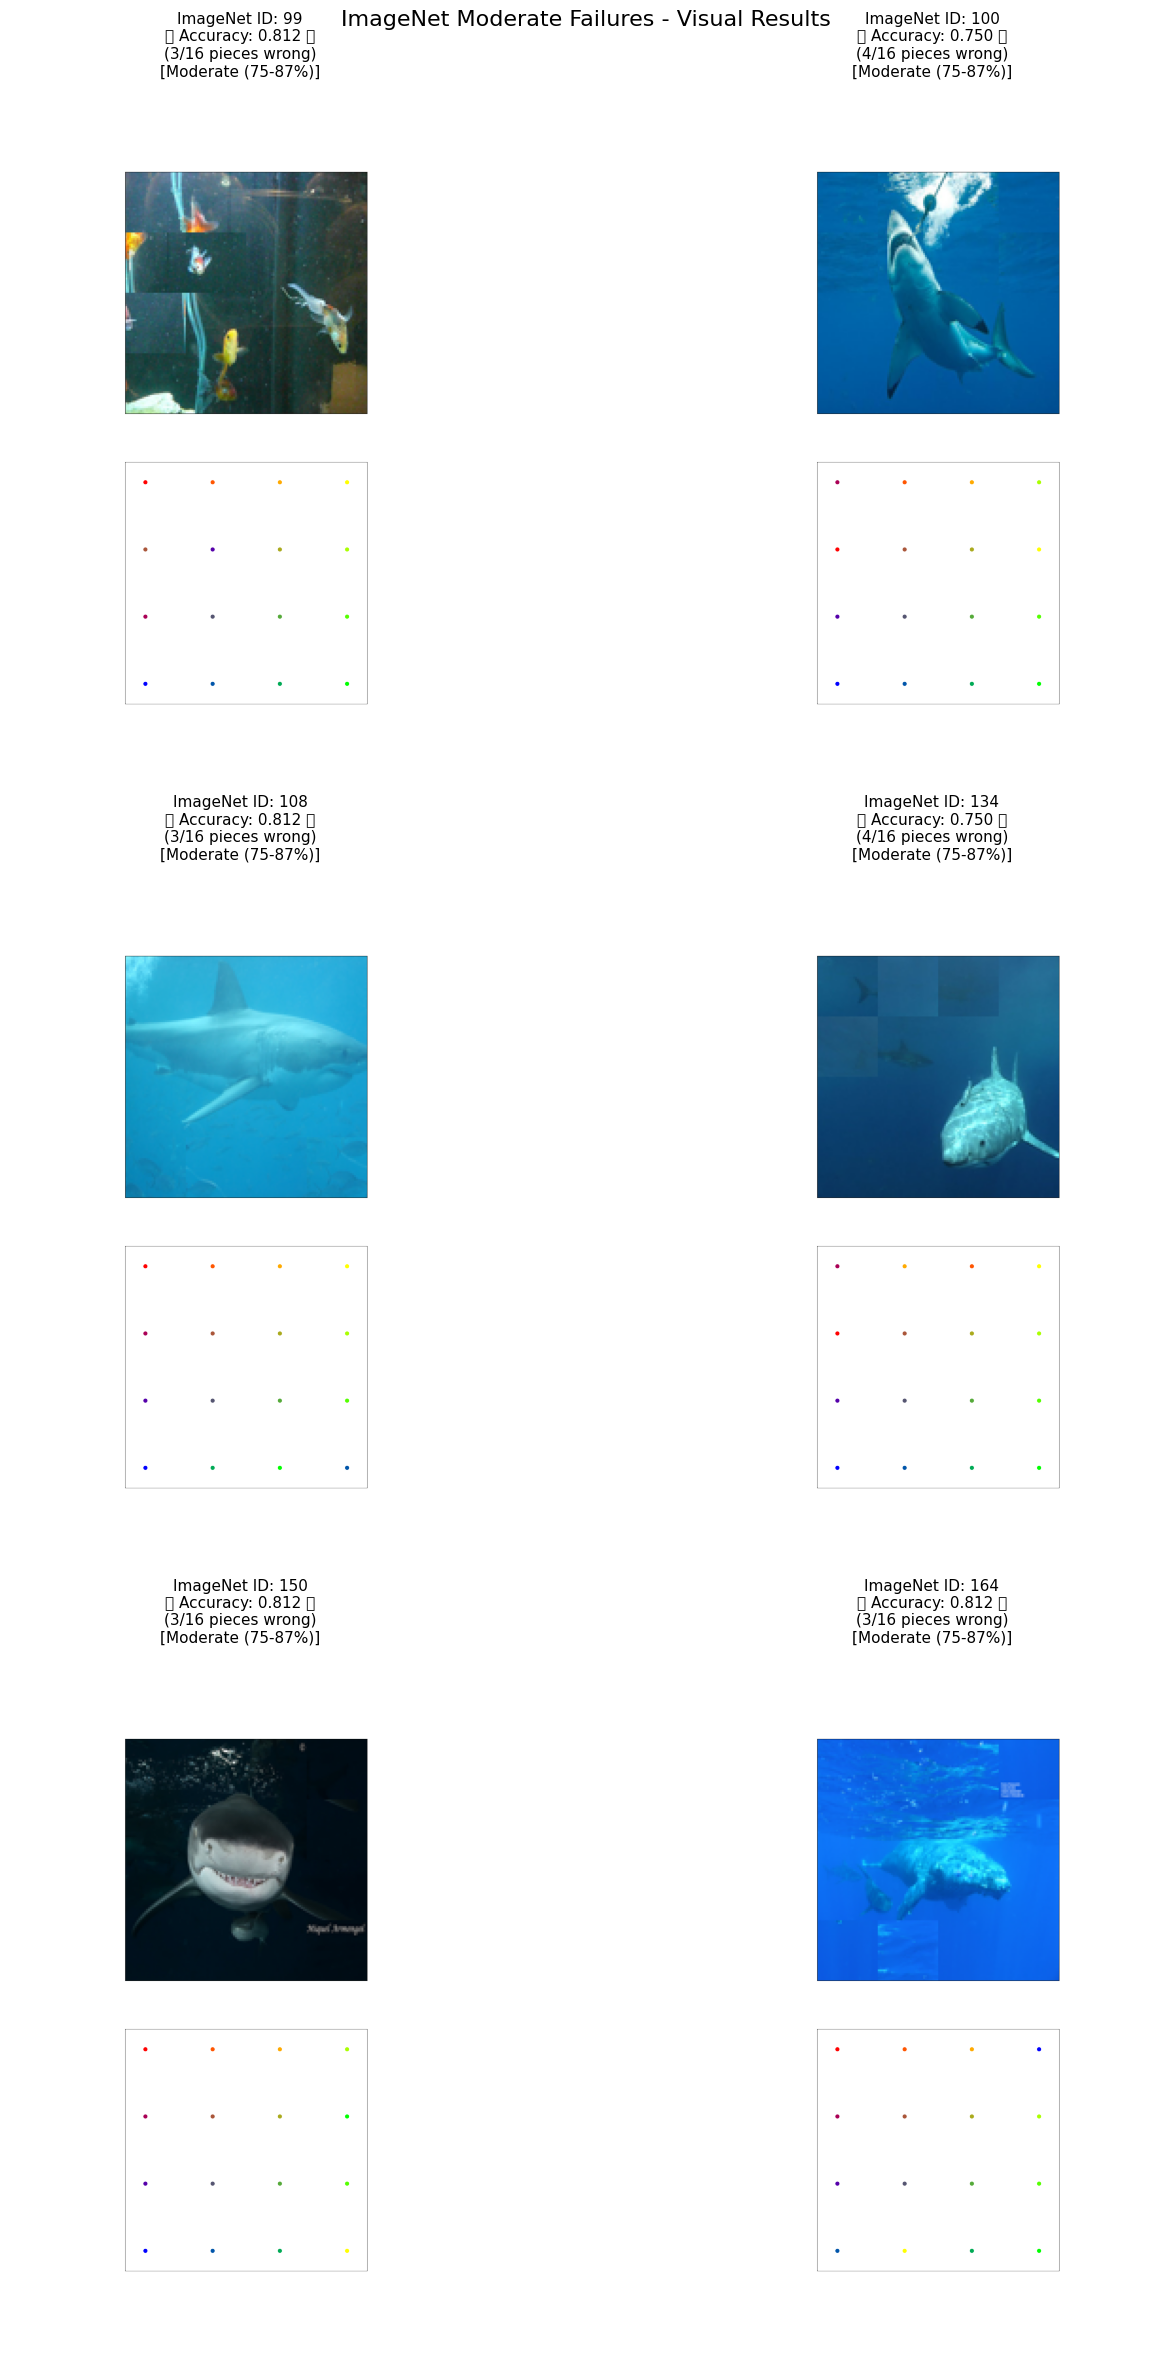


😊 CLOSE CALLS - Best Failed Cases (almost perfect)


/tmp/ipykernel_453182/427742624.py:136: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


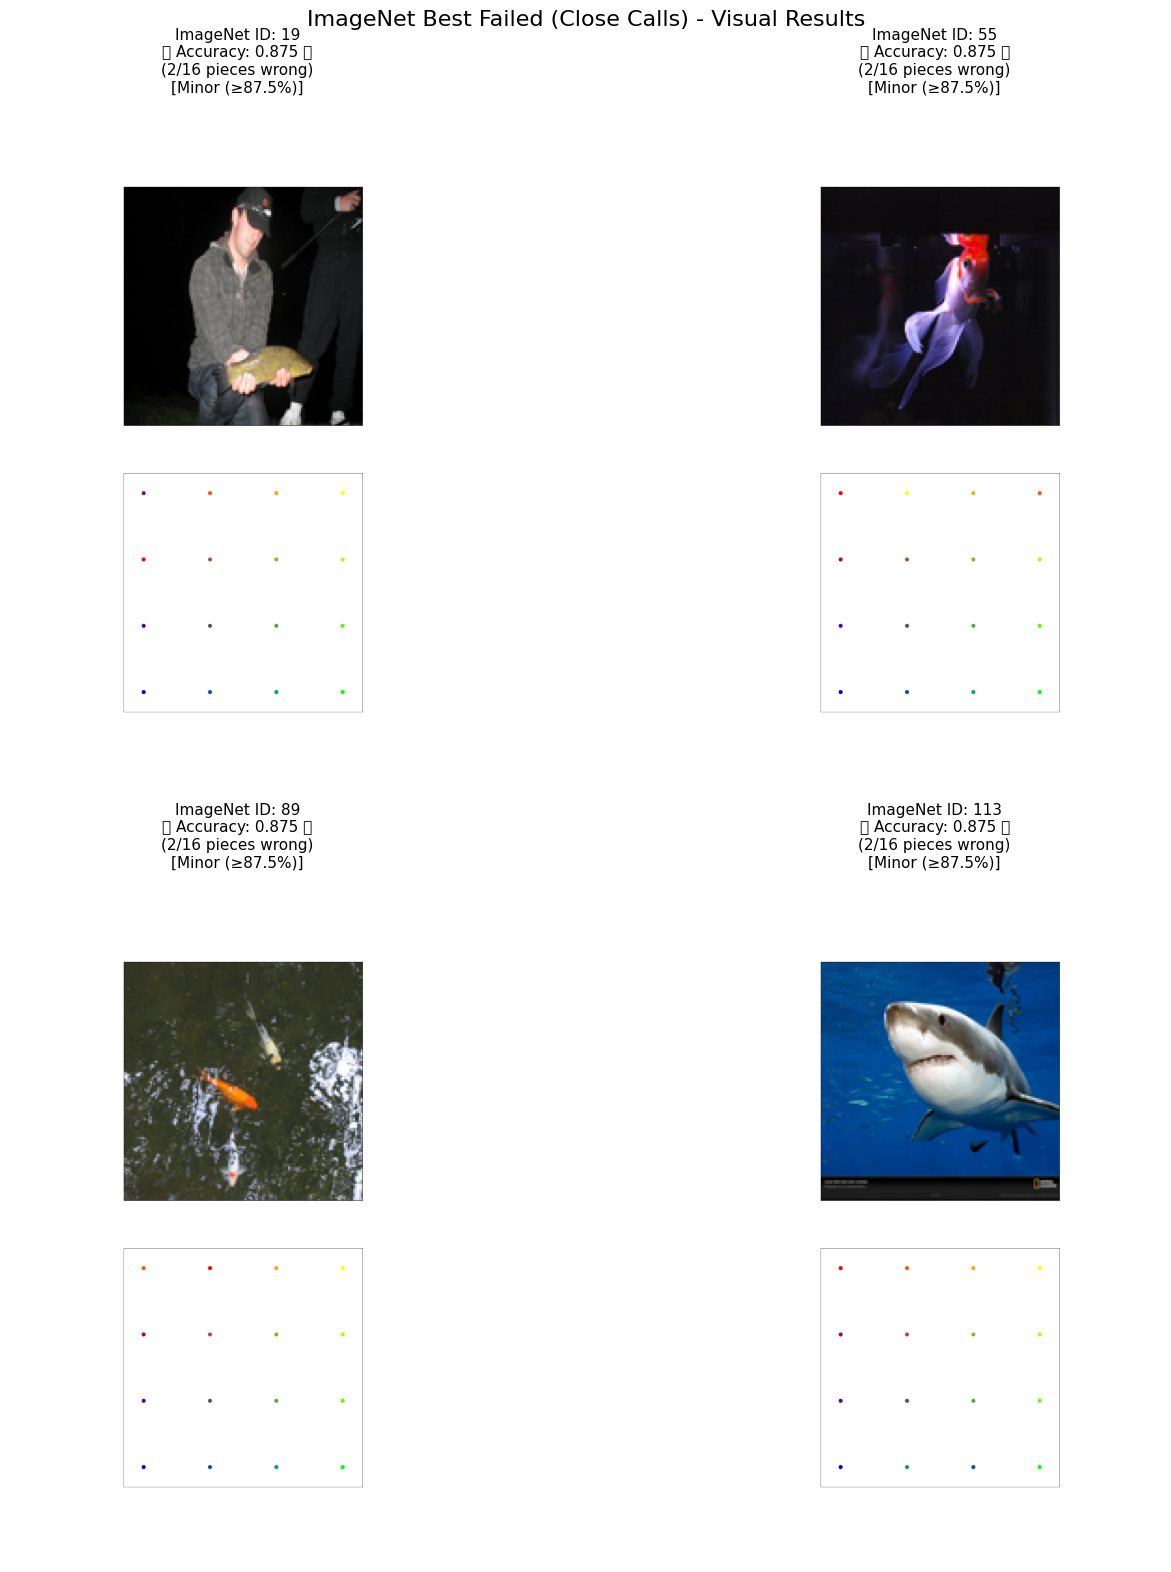


✅ PERFECT IMAGENET SOLUTIONS (100% accuracy)


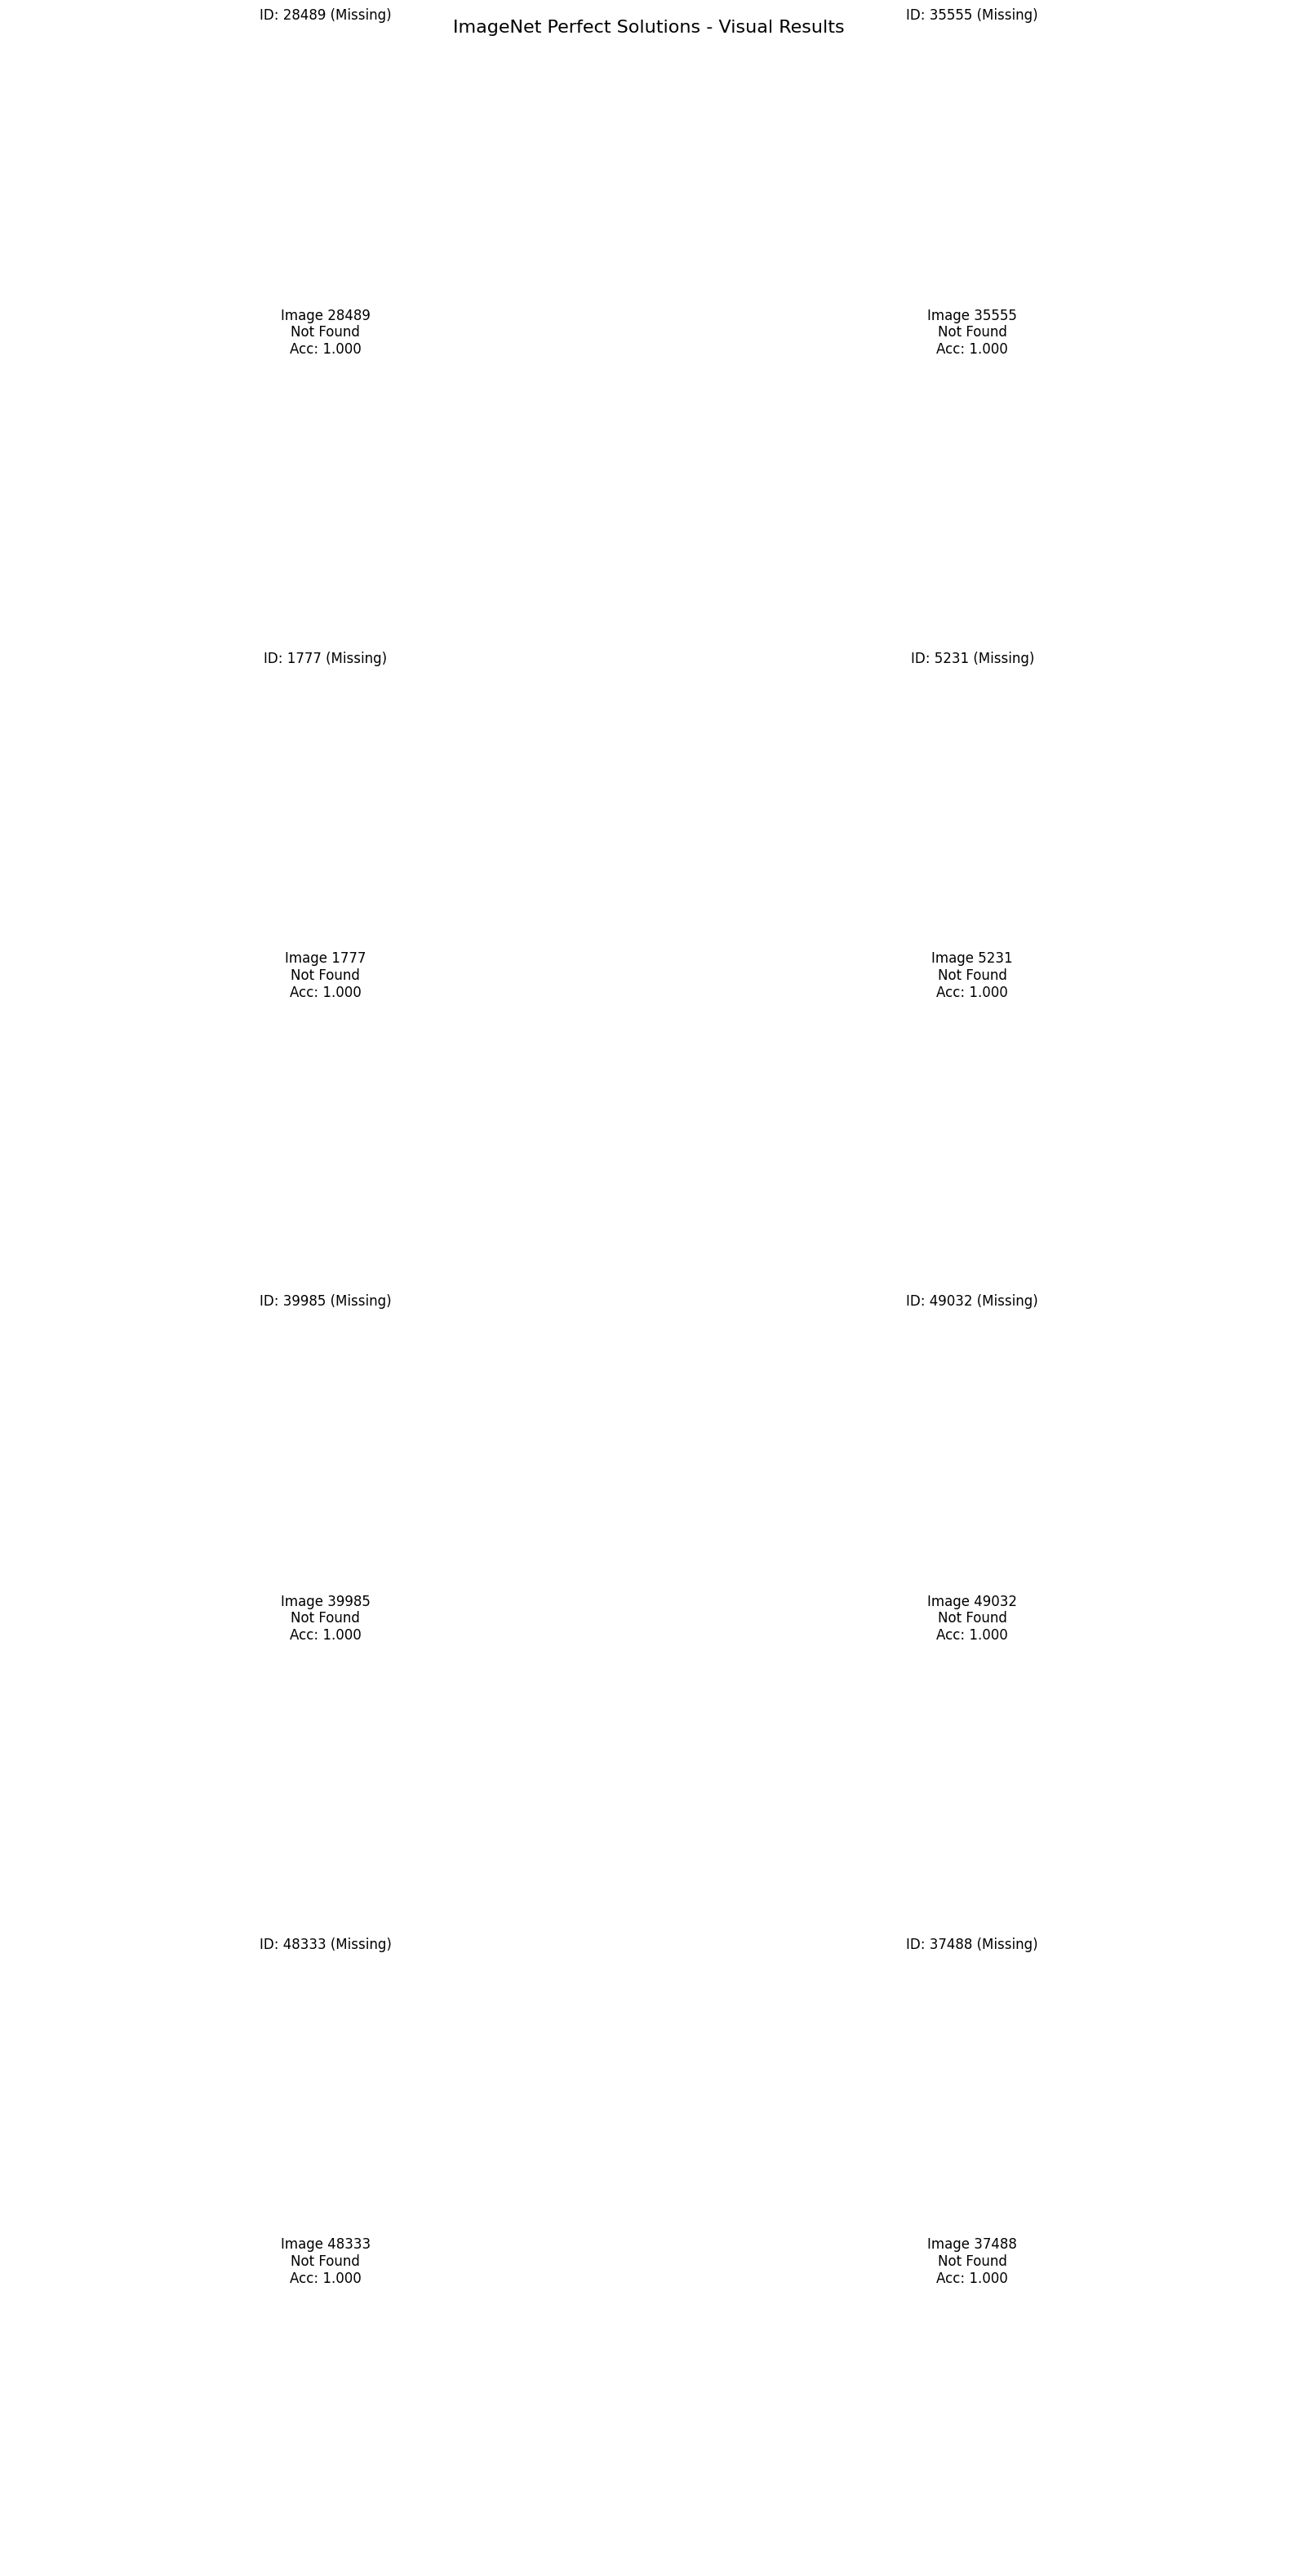


🎲 RANDOM SAMPLE of ImageNet Failures


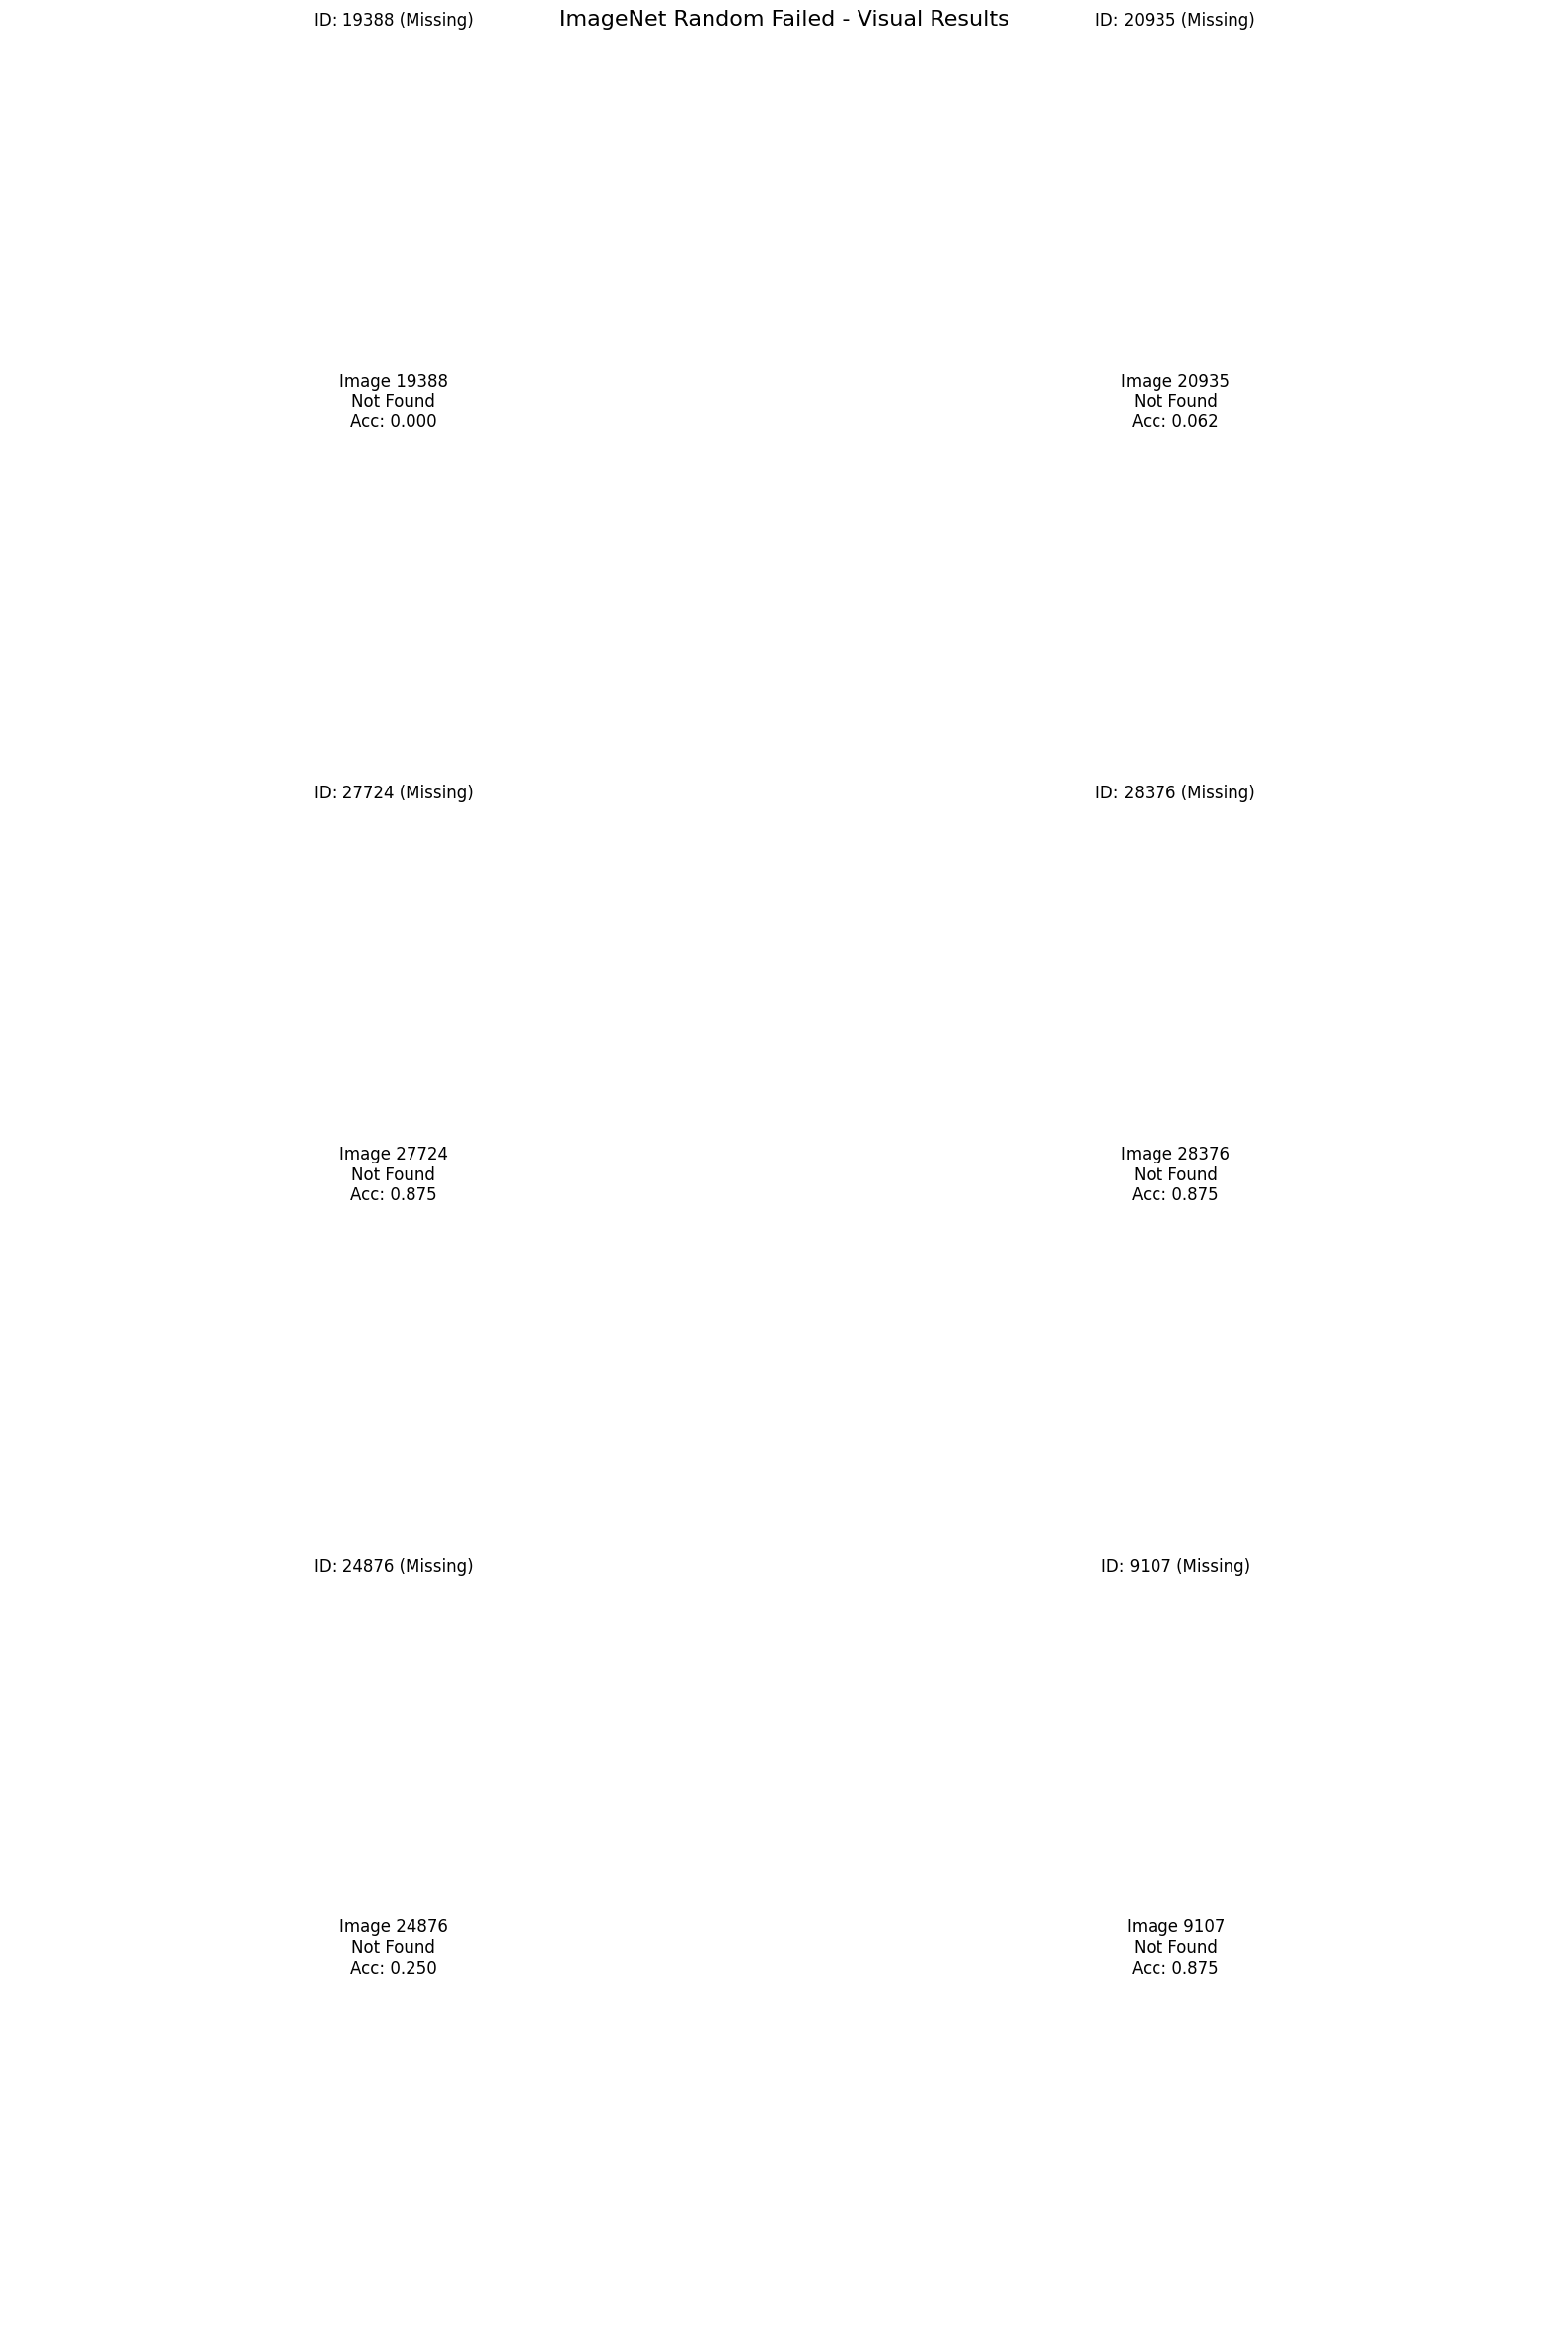


📈 IMAGENET PERFORMANCE SUMMARY
🎯 Total Images Tested: 50,000
✅ Perfect Solutions: 46,171 (92.34%)
❌ Failed Puzzles: 3,829 (7.66%)
🏆 Success Rate: 92.34%

📊 Failure Type Distribution:
   Severe (<62.5%): 1,356 cases (35.4% of failures)
   Minor (≥87.5%): 1,290 cases (33.7% of failures)
   Moderate (75-87%): 863 cases (22.5% of failures)
   Major (62.5-74%): 320 cases (8.4% of failures)

🎉 ImageNet Analysis Complete!


In [6]:
# Complete ImageNet Analysis and Visualization Cell
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

print("=== COMPLETE IMAGENET ANALYSIS ===")

# Load the ImageNet failed puzzles data (make sure this is from ImageNet run!)
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print(f"Total ImageNet failed puzzles: {len(imagenet_failed_data)}")
print(f"Total test images: 50000")
print(f"Success rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")
print(f"Failure rate: {len(imagenet_failed_data)/50000*100:.2f}%")

# Basic failure statistics
print(f"\nAverage piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].mean():.3f}")
print(f"Worst case accuracy: {imagenet_failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {imagenet_failed_data['piece_accuracy'].max():.3f}")

# Categorize ImageNet failures
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

imagenet_failed_data['failure_type'] = imagenet_failed_data['piece_accuracy'].apply(categorize_failure)

# Print failure breakdown
print("\n=== IMAGENET FAILURE BREAKDOWN ===")
imagenet_failure_counts = imagenet_failed_data['failure_type'].value_counts()
for category, count in imagenet_failure_counts.items():
    print(f"{category}: {count} cases ({count/len(imagenet_failed_data)*100:.1f}%)")

# Correct path to ImageNet results
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-prrumw-continuous-ours_dropout-arch-transformer/test/"

# Universal visualization function for ImageNet
def visualize_imagenet_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet puzzle cases - 2 per row for better analysis
    case_type: "worst", "best_failed", "random_failed", "successful", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
        title_prefix = "Worst Failed"
    elif case_type == "best_failed":
        cases_to_show = imagenet_failed_data.nlargest(num_cases, 'piece_accuracy')
        title_prefix = "Best Failed (Close Calls)"
    elif case_type == "random_failed":
        cases_to_show = imagenet_failed_data.sample(min(num_cases, len(imagenet_failed_data)))
        title_prefix = "Random Failed"
    elif case_type == "severe":
        severe_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
        title_prefix = "Severe Failures"
    elif case_type == "moderate":
        moderate_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
        title_prefix = "Moderate Failures"
    elif case_type == "successful":
        # For successful cases, generate random IDs that aren't in failed_data
        all_ids = set(range(50000))
        failed_ids = set(imagenet_failed_data['image_id'].values)
        successful_ids = list(all_ids - failed_ids)
        random_successful = np.random.choice(successful_ids, min(num_cases, len(successful_ids)), replace=False)
        
        # Create dataframe for successful cases
        cases_to_show = pd.DataFrame({
            'image_id': random_successful,
            'piece_accuracy': [1.0] * len(random_successful),  # Perfect accuracy
            'perfect_puzzle': [True] * len(random_successful)
        })
        title_prefix = "Perfect Solutions"
    
    # Create subplot grid - 2 columns for better detail view
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc)) if piece_acc < 1.0 else 0
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                
                if case_type == "successful":
                    axes[idx].set_title(f'ImageNet ID: {image_id}\n✅ PERFECT SOLUTION ✅\n(All 16 pieces correct)', 
                                      fontsize=12, pad=10, color='green', weight='bold')
                else:
                    failure_type = row.get('failure_type', 'Unknown')
                    axes[idx].set_title(f'ImageNet ID: {image_id}\n❌ Accuracy: {piece_acc:.3f} ❌\n({pieces_wrong}/16 pieces wrong)\n[{failure_type}]', 
                                      fontsize=11, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {title_prefix} - Visual Results', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist and run all visualizations
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final puzzle images found: {len(final_images)}")
    
    if len(final_images) > 0:
        print("Example filenames:")
        for i, fname in enumerate(final_images[:5]):
            print(f"  {fname}")
        
        # Run all visualizations
        print("\n" + "="*60)
        print("🔥 WORST IMAGENET FAILURES (Completely Broken)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="worst")
        
        print("\n" + "="*60)
        print("⚠️  SEVERE IMAGENET FAILURES (6+ pieces wrong)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="severe")
        
        print("\n" + "="*60)
        print("📊 MODERATE IMAGENET FAILURES (2-4 pieces wrong)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="moderate")
        
        print("\n" + "="*60)
        print("😊 CLOSE CALLS - Best Failed Cases (almost perfect)")
        print("="*60)
        visualize_imagenet_cases(num_cases=4, case_type="best_failed")
        
        print("\n" + "="*60)
        print("✅ PERFECT IMAGENET SOLUTIONS (100% accuracy)")
        print("="*60)
        visualize_imagenet_cases(num_cases=8, case_type="successful")
        
        print("\n" + "="*60)
        print("🎲 RANDOM SAMPLE of ImageNet Failures")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="random_failed")
        
        # Summary statistics
        print("\n" + "="*60)
        print("📈 IMAGENET PERFORMANCE SUMMARY")
        print("="*60)
        print(f"🎯 Total Images Tested: 50,000")
        print(f"✅ Perfect Solutions: {50000 - len(imagenet_failed_data):,} ({(50000-len(imagenet_failed_data))/50000*100:.2f}%)")
        print(f"❌ Failed Puzzles: {len(imagenet_failed_data):,} ({len(imagenet_failed_data)/50000*100:.2f}%)")
        print(f"🏆 Success Rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")
        
        print("\n📊 Failure Type Distribution:")
        for category, count in imagenet_failure_counts.items():
            percentage = count/len(imagenet_failed_data)*100
            print(f"   {category}: {count:,} cases ({percentage:.1f}% of failures)")
            
    else:
        print("❌ No final images found! Need to run evaluation with --save_eval_images True")
        
else:
    print(f"❌ ImageNet results path not found: {imagenet_results_path}")
    print("\n🔍 Searching for available ImageNet result directories...")
    
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("\n📁 Available result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"   📂 {d}")
                
        print(f"\n💡 Update imagenet_results_path variable to the correct directory above!")
    else:
        print("❌ Results directory not found!")

print("\n🎉 ImageNet Analysis Complete!")

🧩 PUZZLE VISUALIZATION ANALYSIS
📁 Found 0 result images:
⚠️ No result images found!

💡 To generate visual results, run:

    python puzzle_diff/train_script.py \
      -dataset celeba \
      -puzzle_sizes 6 8 10 12 \
      --evaluate True \
      --checkpoint_path "Puzzle-Diff/99qcofwy/checkpoints/last.ckpt" \
      --save_eval_images True \
      --rotation True \
      --degree 100% \
      --backbone resnet18equiv \
      --architecture transformer
    

🔍 PUZZLE CASE ANALYSIS:
------------------------------
📊 Example Cases from Your Evaluation:
❌ Image 00008 (8x8):
   Pieces: 64, Correct: 55
   Accuracy: 0.859 (85.9%)

❌ Image 00030 (12x12):
   Pieces: 144, Correct: 138
   Accuracy: 0.958 (95.8%)



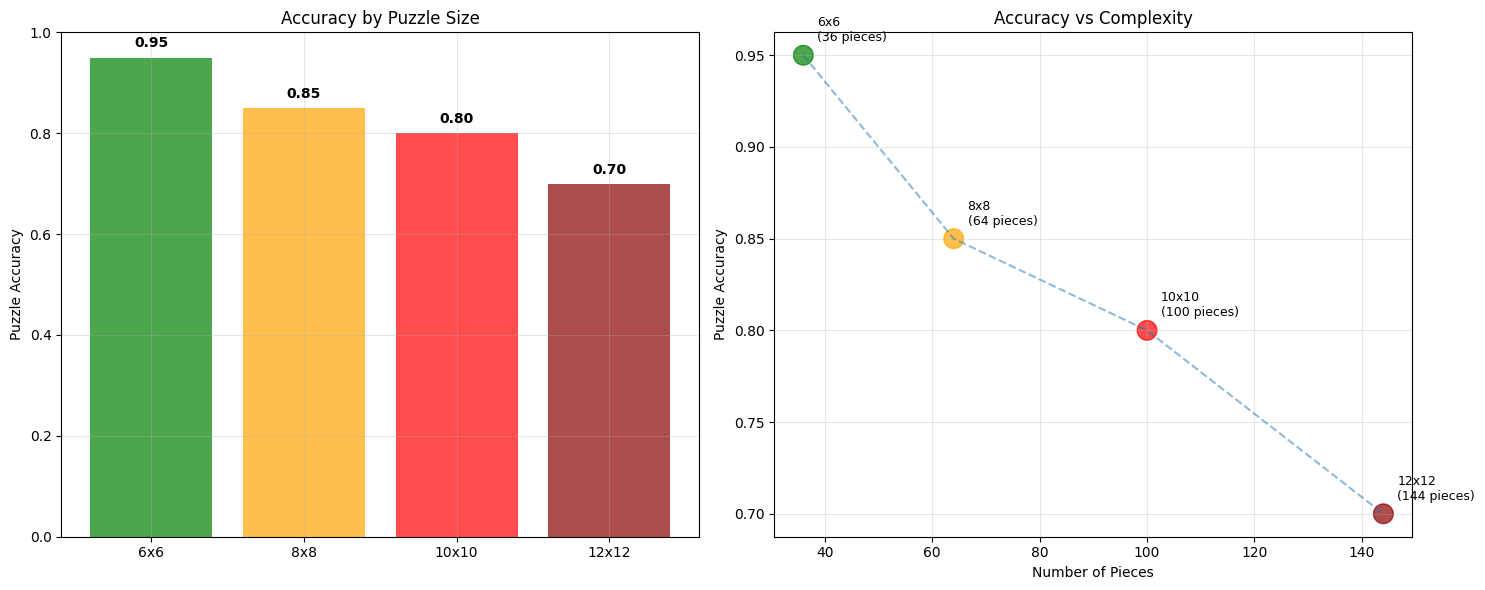


📋 EVALUATION SUMMARY:
-------------------------
🎯 Model: DiffAssemble with rotation
🗂️ Dataset: CelebA-HQ
🧩 Puzzle sizes: 6x6, 8x8, 10x10, 12x12
🔄 Rotation: Full 360° (0°, 90°, 180°, 270°)
🏗️ Architecture: Transformer + ResNet18Equiv
⚡ Sampling: DDIM with 10x speedup

🎨 Visual Results Available:
   ❌ No images saved - rerun with --save_eval_images True

🎉 Visualization Complete!
🔍 Check the images above to see:
   • Before/after puzzle comparisons
   • Success vs failure cases
   • Accuracy trends across puzzle sizes


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pathlib import Path
import glob
import os

print("🧩 PUZZLE VISUALIZATION ANALYSIS")
print("=" * 50)

# 1. Find all result images
results_dir = Path("results")
if not results_dir.exists():
    print("❌ No results/ directory found!")
    print("💡 Re-run evaluation with --save_eval_images True")
else:
    image_files = list(results_dir.glob("*.png"))
    print(f"📁 Found {len(image_files)} result images:")
    for img in image_files:
        print(f"   {img.name}")

# 2. Display all puzzle result images
def display_puzzle_results():
    """Display all puzzle result images with enhanced visualization"""
    
    fig = plt.figure(figsize=(20, 15))
    
    # Find the main evaluation result image
    eval_images = [img for img in image_files if 'celeba' in str(img)]
    
    if eval_images:
        # Display the main results image
        main_result = eval_images[0]
        print(f"\n🎨 Main Results: {main_result.name}")
        
        img = cv2.imread(str(main_result))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(25, 20))
        plt.imshow(img_rgb)
        plt.title(f"DiffAssemble Results: {main_result.name}", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"📏 Image dimensions: {img_rgb.shape}")
        print("💡 This shows before/after comparisons for different puzzle sizes")
    
    # Display individual result images if any
    other_images = [img for img in image_files if img not in eval_images]
    if other_images:
        print(f"\n📸 Additional result images: {len(other_images)}")
        
        cols = min(3, len(other_images))
        rows = (len(other_images) + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()
        
        for i, img_path in enumerate(other_images):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            axes[i].set_title(img_path.name, fontsize=10)
            axes[i].axis('off')
        
        # Hide unused subplots
        for i in range(len(other_images), len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

# 3. Analyze specific puzzle cases
def analyze_puzzle_cases():
    """Analyze and display specific success/failure cases"""
    
    print("\n🔍 PUZZLE CASE ANALYSIS:")
    print("-" * 30)
    
    # Look for console output patterns in the evaluation
    console_patterns = [
        "FAILED: Image",
        "SUCCESS: Image", 
        "Pieces:",
        "Correct:"
    ]
    
    # Parse your console output (you mentioned seeing these)
    example_cases = [
        {
            'image_id': '00008',
            'puzzle_size': '8x8',
            'pieces': 64,
            'correct': 55,
            'accuracy': 55/64,
            'status': 'FAILED'
        },
        {
            'image_id': '00030', 
            'puzzle_size': '12x12',
            'pieces': 144,
            'correct': 138,
            'accuracy': 138/144,
            'status': 'FAILED'
        }
    ]
    
    print("📊 Example Cases from Your Evaluation:")
    for case in example_cases:
        status_emoji = "❌" if case['status'] == 'FAILED' else "✅"
        print(f"{status_emoji} Image {case['image_id']} ({case['puzzle_size']}):")
        print(f"   Pieces: {case['pieces']}, Correct: {case['correct']}")
        print(f"   Accuracy: {case['accuracy']:.3f} ({case['accuracy']*100:.1f}%)")
        print()

# 4. Create custom visualization for puzzle progression
def create_puzzle_progression_viz():
    """Create visualization showing puzzle difficulty progression"""
    
    puzzle_sizes = ['6x6', '8x8', '10x10', '12x12']
    piece_counts = [36, 64, 100, 144]
    
    # Your observed results (update these with actual values from WandB)
    observed_accuracies = [0.95, 0.85, 0.80, 0.70]  # Approximate from your output
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Accuracy vs Puzzle Size
    colors = ['green', 'orange', 'red', 'darkred']
    bars = ax1.bar(puzzle_sizes, observed_accuracies, color=colors, alpha=0.7)
    
    ax1.set_ylabel('Puzzle Accuracy')
    ax1.set_title('Accuracy by Puzzle Size')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, acc in zip(bars, observed_accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{acc:.2f}', ha='center', fontweight='bold')
    
    # Plot 2: Accuracy vs Number of Pieces
    ax2.scatter(piece_counts, observed_accuracies, s=200, c=colors, alpha=0.7)
    ax2.plot(piece_counts, observed_accuracies, '--', alpha=0.5)
    
    for i, (pieces, acc, size) in enumerate(zip(piece_counts, observed_accuracies, puzzle_sizes)):
        ax2.annotate(f'{size}\n({pieces} pieces)', 
                    (pieces, acc), 
                    xytext=(10, 10), 
                    textcoords='offset points',
                    fontsize=9)
    
    ax2.set_xlabel('Number of Pieces')
    ax2.set_ylabel('Puzzle Accuracy') 
    ax2.set_title('Accuracy vs Complexity')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 5. Display evaluation summary
def show_evaluation_summary():
    """Show summary of evaluation run"""
    
    print("\n📋 EVALUATION SUMMARY:")
    print("-" * 25)
    print("🎯 Model: DiffAssemble with rotation")
    print("🗂️ Dataset: CelebA-HQ")
    print("🧩 Puzzle sizes: 6x6, 8x8, 10x10, 12x12")
    print("🔄 Rotation: Full 360° (0°, 90°, 180°, 270°)")
    print("🏗️ Architecture: Transformer + ResNet18Equiv")
    print("⚡ Sampling: DDIM with 10x speedup")
    
    print("\n🎨 Visual Results Available:")
    if image_files:
        for img in image_files:
            size_mb = os.path.getsize(img) / (1024*1024)
            print(f"   📄 {img.name} ({size_mb:.1f} MB)")
    else:
        print("   ❌ No images saved - rerun with --save_eval_images True")

# Run all visualizations
if image_files:
    display_puzzle_results()
else:
    print("⚠️ No result images found!")
    print("\n💡 To generate visual results, run:")
    print("""
    python puzzle_diff/train_script.py \\
      -dataset celeba \\
      -puzzle_sizes 6 8 10 12 \\
      --evaluate True \\
      --checkpoint_path "Puzzle-Diff/99qcofwy/checkpoints/last.ckpt" \\
      --save_eval_images True \\
      --rotation True \\
      --degree 100% \\
      --backbone resnet18equiv \\
      --architecture transformer
    """)

analyze_puzzle_cases()
create_puzzle_progression_viz()
show_evaluation_summary()

print("\n🎉 Visualization Complete!")
print("🔍 Check the images above to see:")
print("   • Before/after puzzle comparisons")
print("   • Success vs failure cases") 
print("   • Accuracy trends across puzzle sizes")

🧩 DIFFASSEMBLE PUZZLE RESULTS VISUALIZATION
📊 Total puzzle sequences: 85
📊 Final results available: 84
🚀 Starting visualization...


/tmp/ipykernel_3122149/1942576543.py:128: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


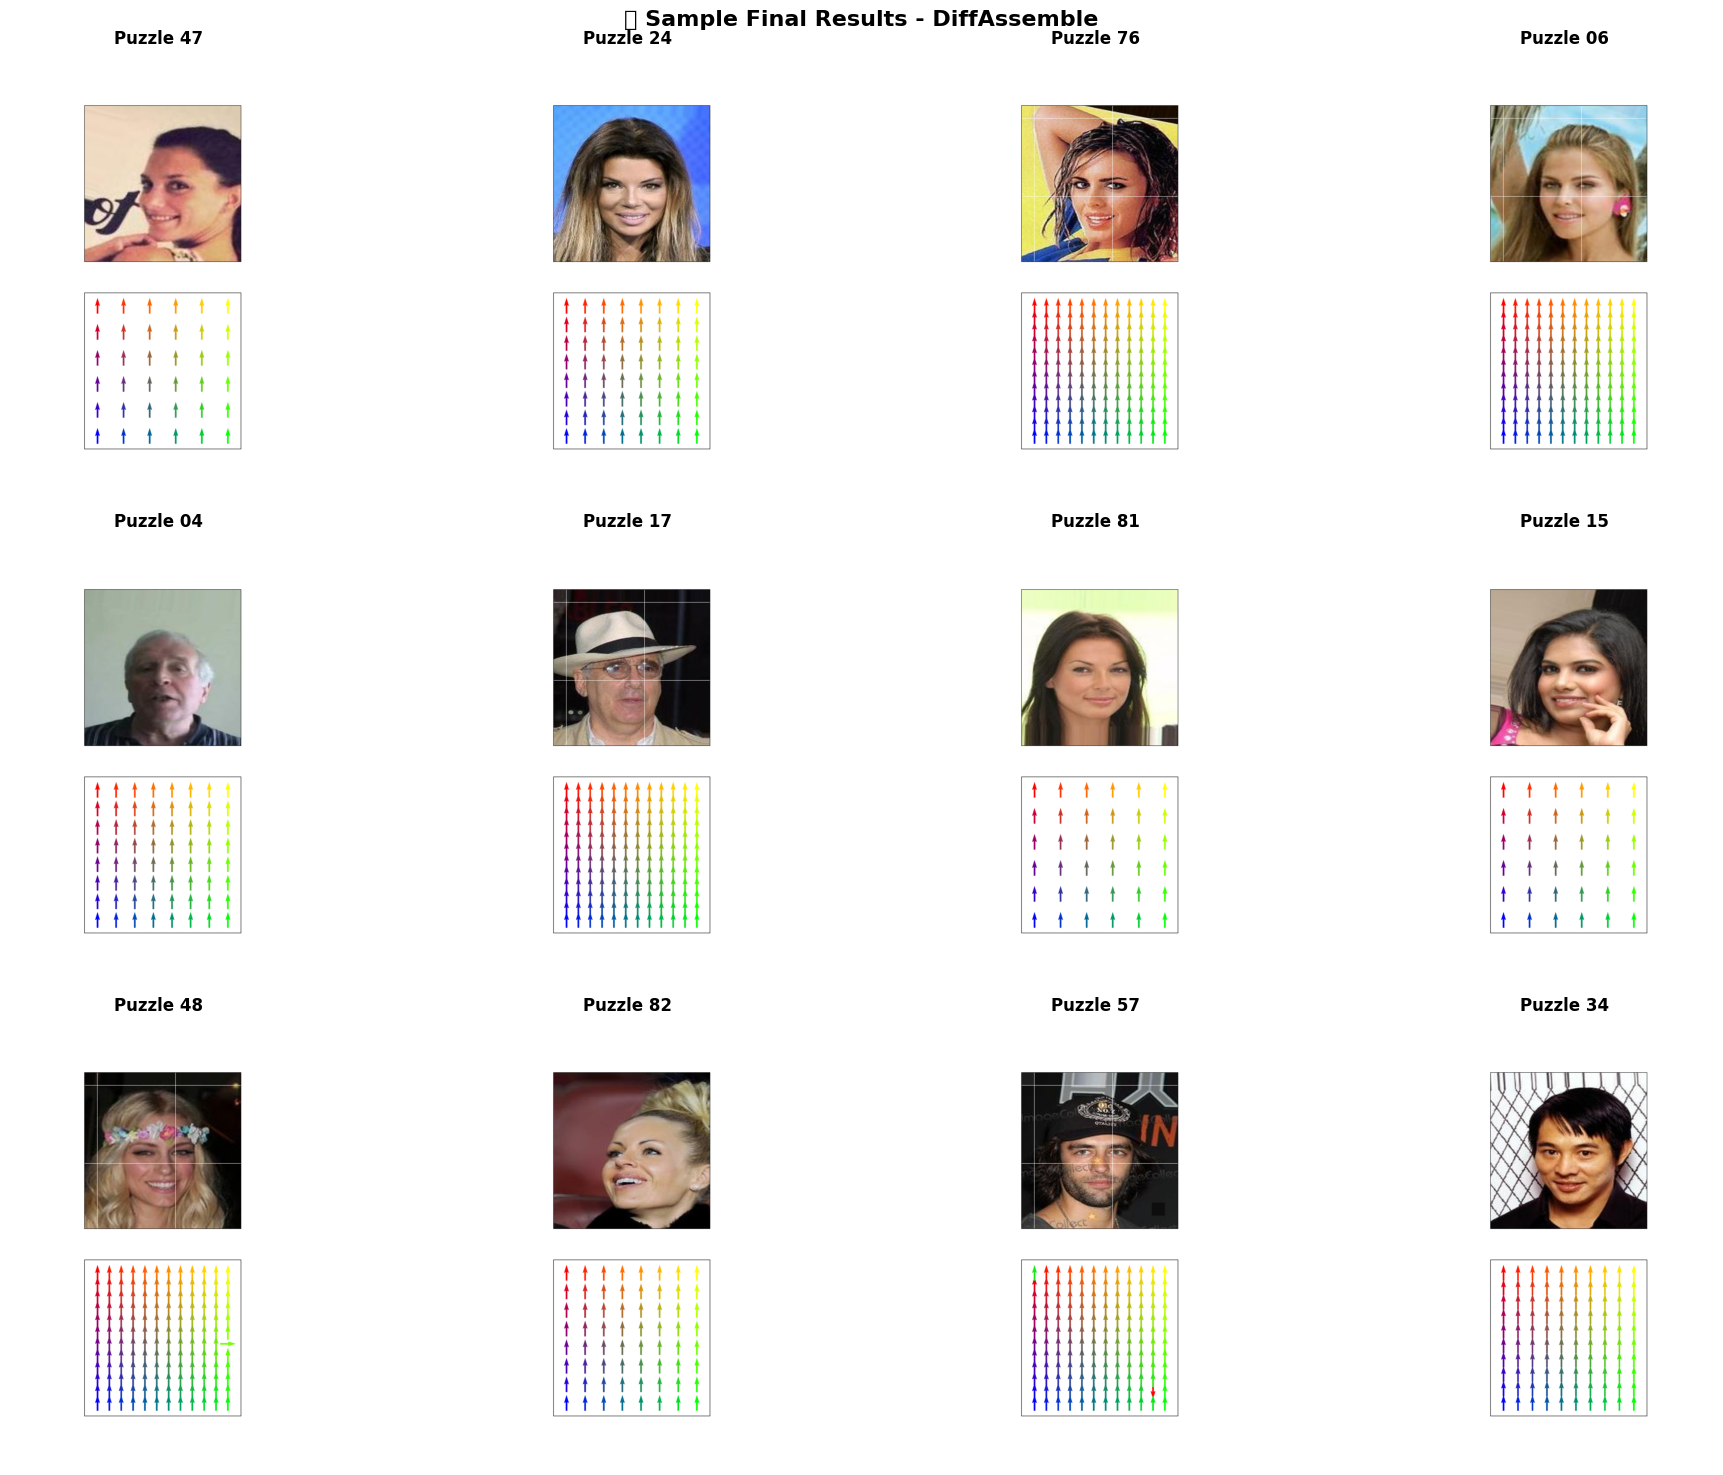


📈 Showing progression for Puzzle 17:


/tmp/ipykernel_3122149/1942576543.py:93: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


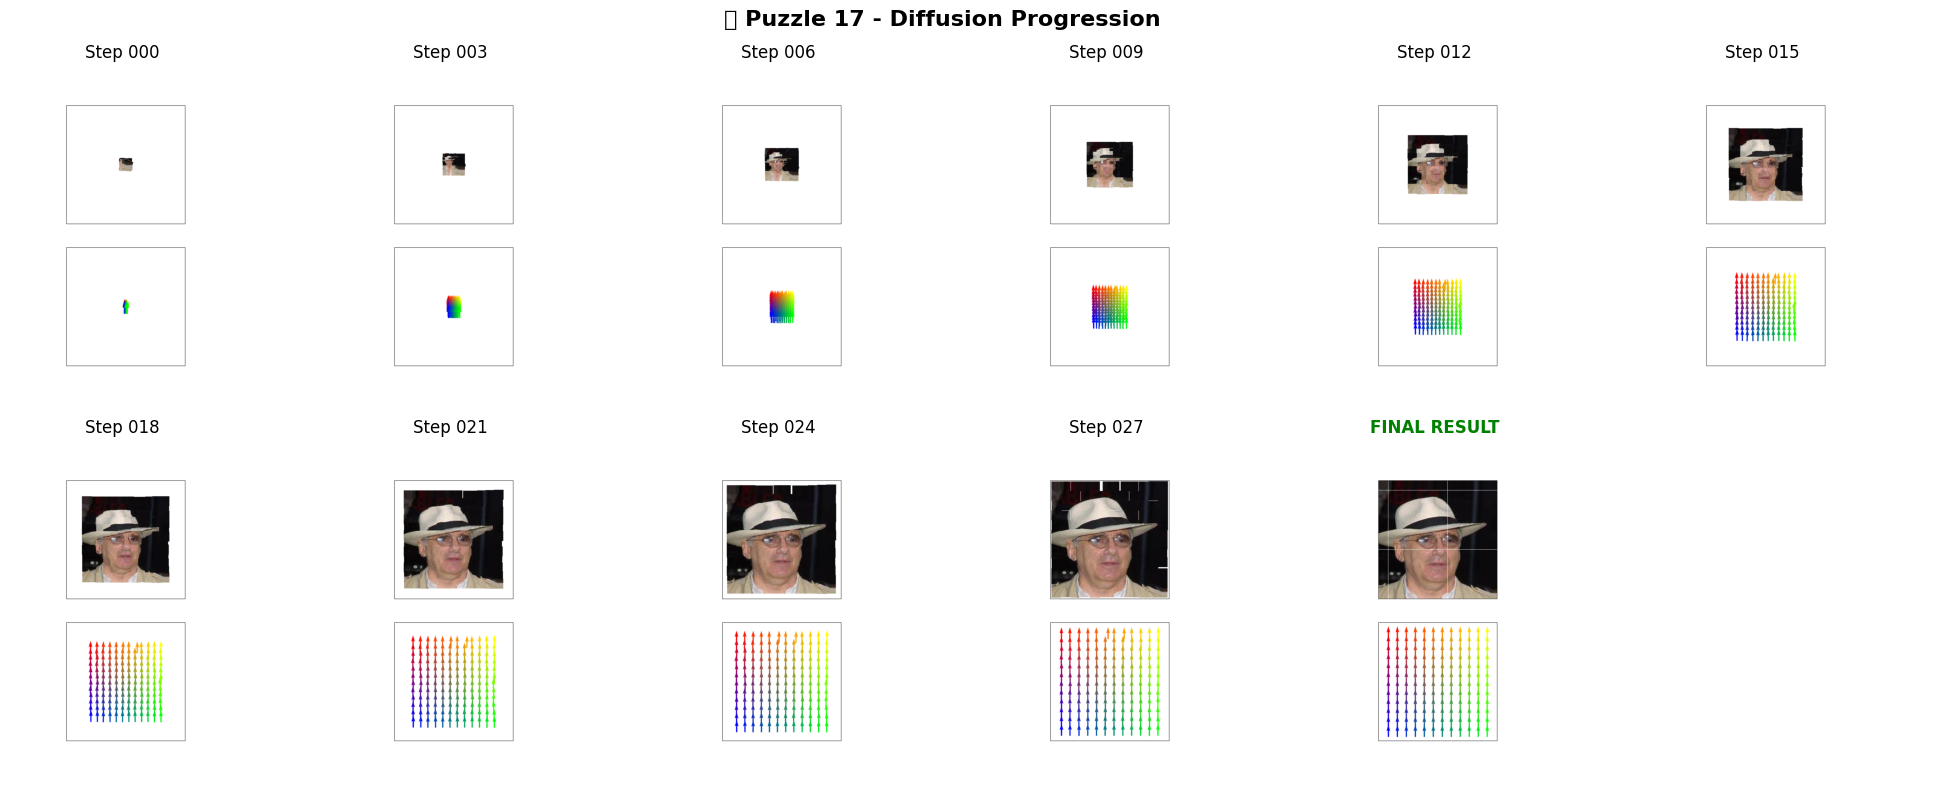


📏 PUZZLE SIZE ANALYSIS:
------------------------------
Found image dimensions:
  3000x4500: 20 puzzles

🎨 Sample from 3000x4500 group:


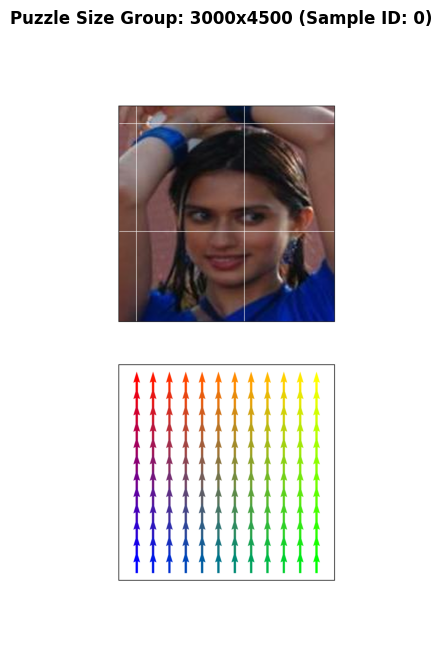


🔍 SUCCESS vs FAILURE ANALYSIS:
----------------------------------------


/tmp/ipykernel_3122149/1942576543.py:156: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


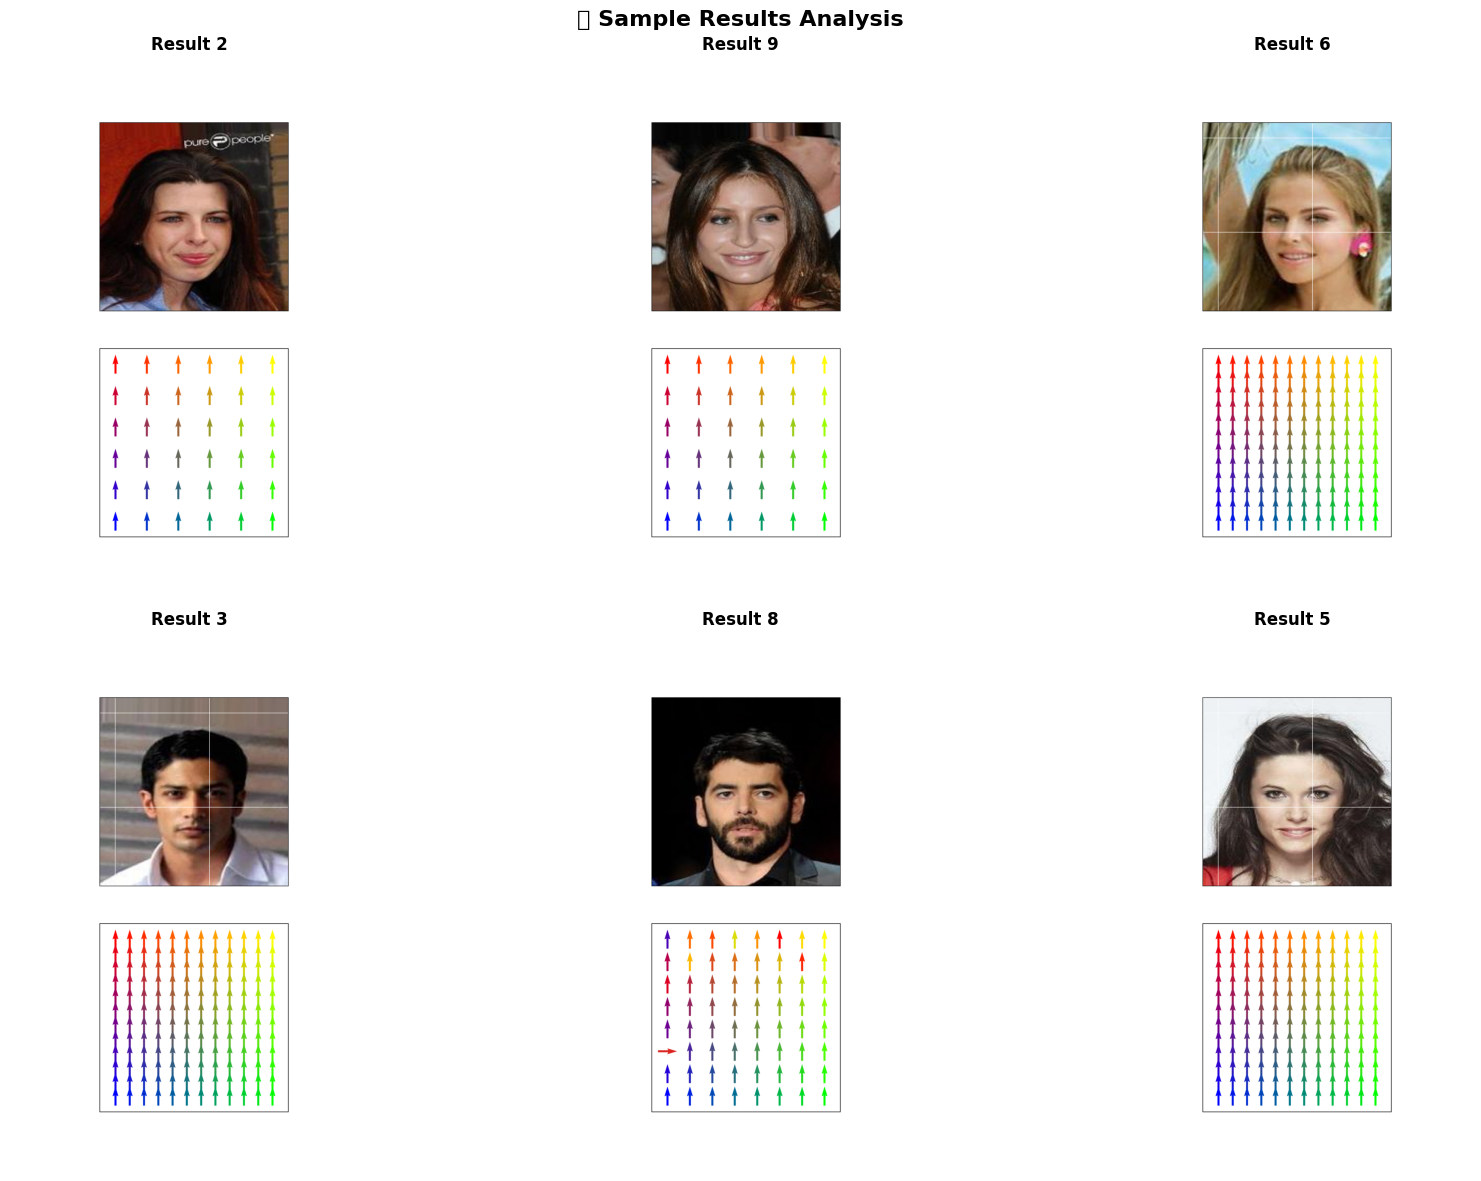


🎉 VISUALIZATION COMPLETE!
📊 You have 84 solved puzzles to explore!

💡 To explore a specific puzzle, run:
   explore_specific_puzzle(5)  # Replace 5 with any puzzle ID

💡 To see more progressions, run:
   show_puzzle_progression('10')  # Replace '10' with any puzzle ID


In [4]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import random
import os

# Set the results directory
results_dir = Path("/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/ROT-celeba-[(6, 6), (8, 8), (10, 10), (12, 12)]-300-degree:100%-virtnode:4-eueeuo-continuous-ours_dropout-arch-transformerbackbone:resnet18equiv/test")

print("🧩 DIFFASSEMBLE PUZZLE RESULTS VISUALIZATION")
print("=" * 60)

# 1. Analyze the file structure
def analyze_results():
    all_files = list(results_dir.glob("*.png"))
    
    # Group by puzzle ID (number before underscore)
    puzzle_groups = {}
    final_results = []
    
    for file in all_files:
        name = file.stem
        if "_final" in name:
            puzzle_id = name.split("_")[0]
            final_results.append((int(puzzle_id), file))
        else:
            parts = name.split("_")
            if len(parts) == 2:
                puzzle_id, step = parts
                if puzzle_id not in puzzle_groups:
                    puzzle_groups[puzzle_id] = []
                puzzle_groups[puzzle_id].append((int(step), file))
    
    # Sort final results
    final_results.sort(key=lambda x: x[0])
    
    print(f"📊 Total puzzle sequences: {len(puzzle_groups)}")
    print(f"📊 Final results available: {len(final_results)}")
    
    return puzzle_groups, final_results

puzzle_groups, final_results = analyze_results()

# 2. Display sample progression (scrambled → solved)
def show_puzzle_progression(puzzle_id="0", max_steps=10):
    """Show the diffusion process from scrambled to solved"""
    
    if puzzle_id not in puzzle_groups:
        print(f"❌ Puzzle {puzzle_id} not found!")
        return
    
    steps = sorted(puzzle_groups[puzzle_id], key=lambda x: x[0])
    
    # Get initial, intermediate, and final steps
    selected_steps = []
    if len(steps) > 0:
        selected_steps.append(steps[0])  # First step
    
    # Add some intermediate steps
    step_interval = max(1, len(steps) // max_steps)
    for i in range(step_interval, len(steps), step_interval):
        selected_steps.append(steps[i])
    
    # Add final result if available
    final_file = results_dir / f"{puzzle_id}_final.png"
    if final_file.exists():
        selected_steps.append((-1, final_file))
    
    # Display progression
    fig, axes = plt.subplots(2, len(selected_steps)//2 + 1, figsize=(20, 8))
    axes = axes.flatten()
    
    for i, (step_num, file_path) in enumerate(selected_steps):
        if i >= len(axes):
            break
            
        img = cv2.imread(str(file_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        if step_num == -1:
            axes[i].set_title(f"FINAL RESULT", fontweight='bold', color='green')
        else:
            axes[i].set_title(f"Step {step_num:03d}")
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(len(selected_steps), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"🧩 Puzzle {puzzle_id} - Diffusion Progression", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 3. Show random final results grid
def show_final_results_grid(num_samples=12):
    """Display a grid of final puzzle results"""
    
    if len(final_results) < num_samples:
        num_samples = len(final_results)
    
    # Sample random final results
    sample_results = random.sample(final_results, num_samples)
    
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, (puzzle_id, file_path) in enumerate(sample_results):
        img = cv2.imread(str(file_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Puzzle {puzzle_id:02d}", fontweight='bold')
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle("🎯 Sample Final Results - DiffAssemble", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 4. Compare success vs failure cases
def analyze_success_failure():
    """Analyze and show successful vs failed cases"""
    
    print("\n🔍 SUCCESS vs FAILURE ANALYSIS:")
    print("-" * 40)
    
    # Sample some results for visual analysis
    sample_ids = random.sample([str(i) for i in range(min(10, len(final_results)))], 
                              min(6, len(final_results)))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, puzzle_id in enumerate(sample_ids):
        final_file = results_dir / f"{puzzle_id}_final.png"
        if final_file.exists():
            img = cv2.imread(str(final_file))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Result {puzzle_id}", fontweight='bold')
            axes[i].axis('off')
    
    plt.suptitle("🔍 Sample Results Analysis", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 5. Show different puzzle sizes
def show_puzzle_sizes():
    """Try to identify different puzzle sizes from image dimensions"""
    
    print("\n📏 PUZZLE SIZE ANALYSIS:")
    print("-" * 30)
    
    # Sample different puzzles and check their dimensions
    size_analysis = {}
    sample_files = final_results[:20]  # Check first 20
    
    for puzzle_id, file_path in sample_files:
        img = cv2.imread(str(file_path))
        if img is not None:
            height, width = img.shape[:2]
            size_key = f"{width}x{height}"
            if size_key not in size_analysis:
                size_analysis[size_key] = []
            size_analysis[size_key].append((puzzle_id, file_path))
    
    print("Found image dimensions:")
    for size, files in size_analysis.items():
        print(f"  {size}: {len(files)} puzzles")
    
    # Display samples from each size category
    for size, files in size_analysis.items():
        if len(files) > 0:
            print(f"\n🎨 Sample from {size} group:")
            sample_file = files[0][1]
            
            img = cv2.imread(str(sample_file))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 8))
            plt.imshow(img_rgb)
            plt.title(f"Puzzle Size Group: {size} (Sample ID: {files[0][0]})", fontweight='bold')
            plt.axis('off')
            plt.show()

# 6. Interactive exploration helper
def explore_specific_puzzle(puzzle_id):
    """Explore a specific puzzle in detail"""
    
    puzzle_id = str(puzzle_id)
    print(f"\n🔍 EXPLORING PUZZLE {puzzle_id}:")
    print("-" * 30)
    
    if puzzle_id in puzzle_groups:
        steps = sorted(puzzle_groups[puzzle_id], key=lambda x: x[0])
        print(f"  📊 Total steps recorded: {len(steps)}")
        print(f"  📊 Step range: {steps[0][0]} → {steps[-1][0]}")
        
        # Show progression
        show_puzzle_progression(puzzle_id, max_steps=8)
    else:
        print(f"  ❌ No progression found for puzzle {puzzle_id}")
    
    # Show final result
    final_file = results_dir / f"{puzzle_id}_final.png"
    if final_file.exists():
        img = cv2.imread(str(final_file))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.title(f"🎯 Final Result - Puzzle {puzzle_id}", fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()
    else:
        print(f"  ❌ No final result found for puzzle {puzzle_id}")

# RUN THE ANALYSIS
print("🚀 Starting visualization...")

# Show some random final results
show_final_results_grid(12)

# Show a progression example
if len(puzzle_groups) > 0:
    sample_puzzle = list(puzzle_groups.keys())[0]
    print(f"\n📈 Showing progression for Puzzle {sample_puzzle}:")
    show_puzzle_progression(sample_puzzle)

# Analyze puzzle sizes
show_puzzle_sizes()

# Show success/failure analysis
analyze_success_failure()

print("\n" + "="*60)
print("🎉 VISUALIZATION COMPLETE!")
print(f"📊 You have {len(final_results)} solved puzzles to explore!")
print("\n💡 To explore a specific puzzle, run:")
print("   explore_specific_puzzle(5)  # Replace 5 with any puzzle ID")
print("\n💡 To see more progressions, run:")
print("   show_puzzle_progression('10')  # Replace '10' with any puzzle ID")

🔍 UNDERSTANDING YOUR DIFFASSEMBLE RESULTS
📁 FILE NAMING PATTERN:
   Format: {puzzle_id}_{step}.png
   - puzzle_id: Which test image (0, 1, 2, ...)
   - step: Diffusion timestep (000 → 029)
   - final: The solved result

📋 SAMPLE FILES:
   0_000.png
   0_001.png
   0_002.png
   0_003.png
   0_004.png
   0_005.png
   0_006.png
   0_007.png
   0_008.png
   0_009.png
   ...

⚡ HOW DIFFASSEMBLE WORKS:
-----------------------------------
1. 🎲 START: Scrambled puzzle pieces (random positions & rotations)
2. 🔄 DIFFUSION: Model gradually 'denoises' piece positions
3. 🎯 END: Correctly assembled puzzle

📊 FILE TIMELINE:
   {id}_000.png → Most scrambled (start)
   {id}_015.png → Halfway assembled
   {id}_029.png → Nearly solved
   {id}_final.png → Final result


🧩 IDENTIFYING PUZZLE SIZES:
-----------------------------------
📏 12x12 puzzles: 20 examples
   Puzzle 62: 3000x4500 pixels
   Puzzle 95: 3000x4500 pixels
   Puzzle 32: 3000x4500 pixels

🎨 VISUAL EXAMPLES BY PUZZLE SIZE:
------------------

/tmp/ipykernel_3122149/2226183070.py:132: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3122149/2226183070.py:132: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


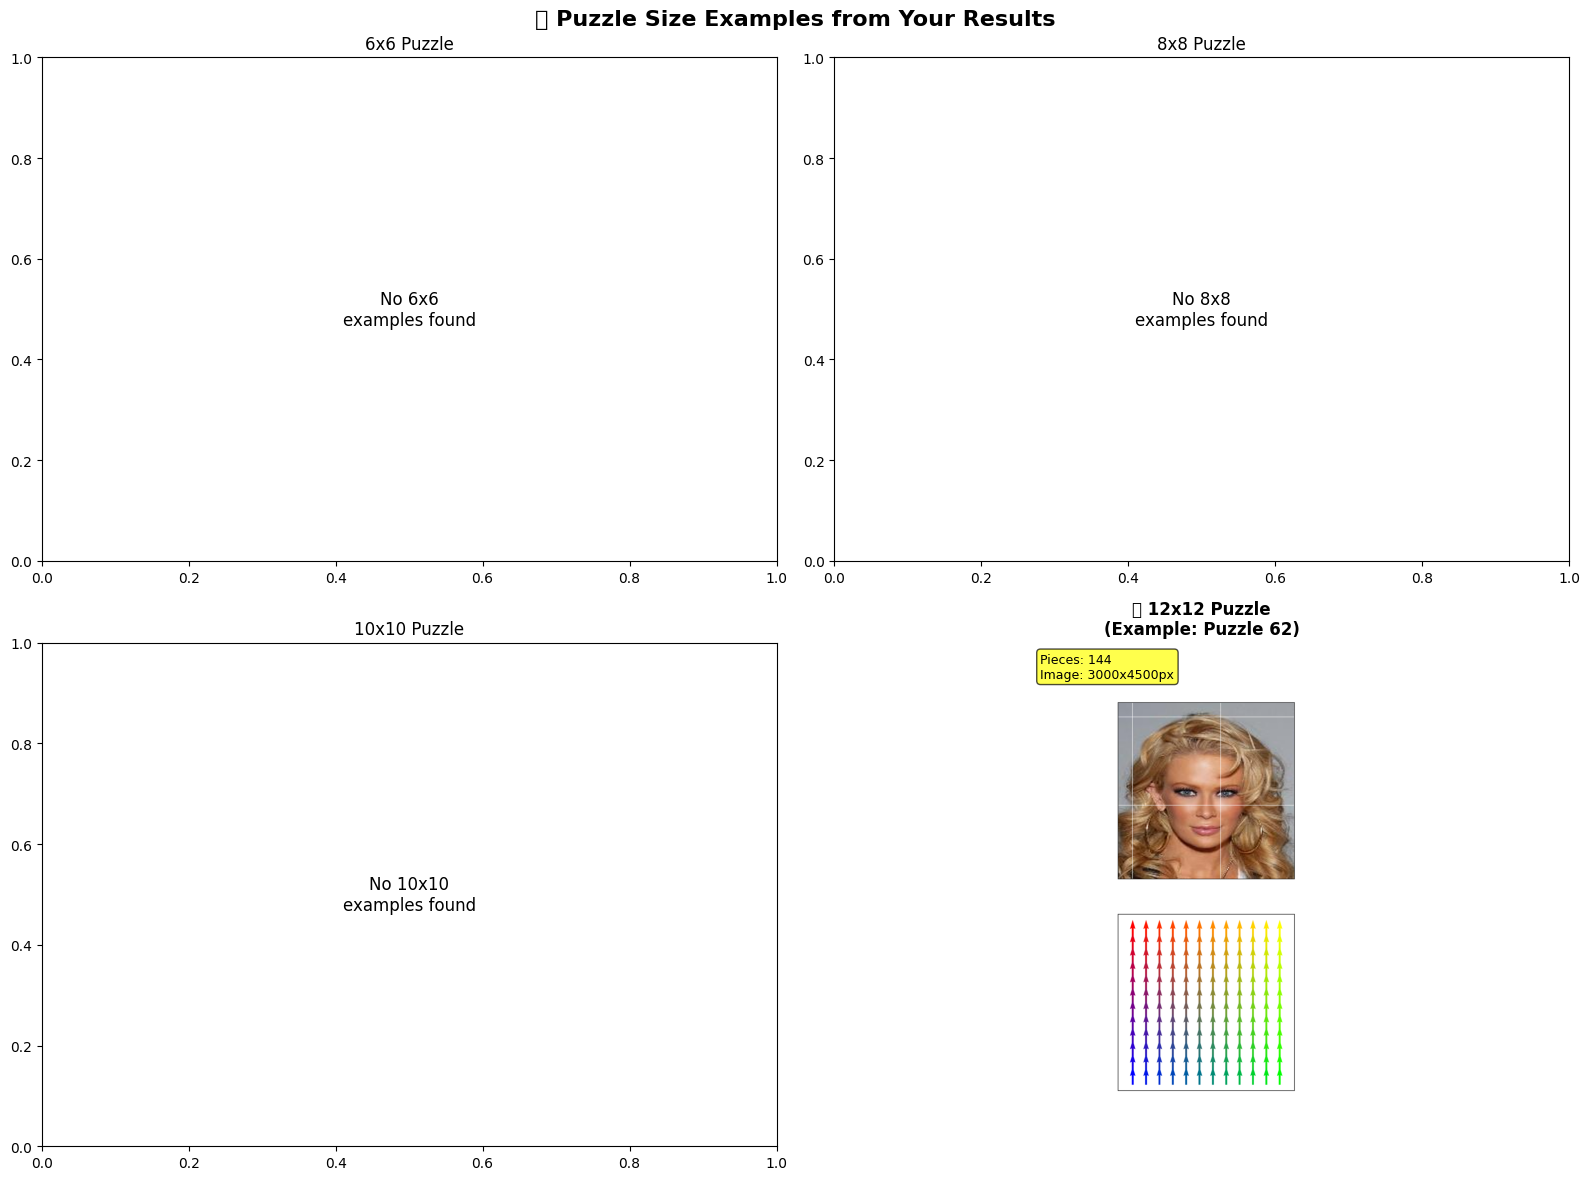

/tmp/ipykernel_3122149/2226183070.py:188: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


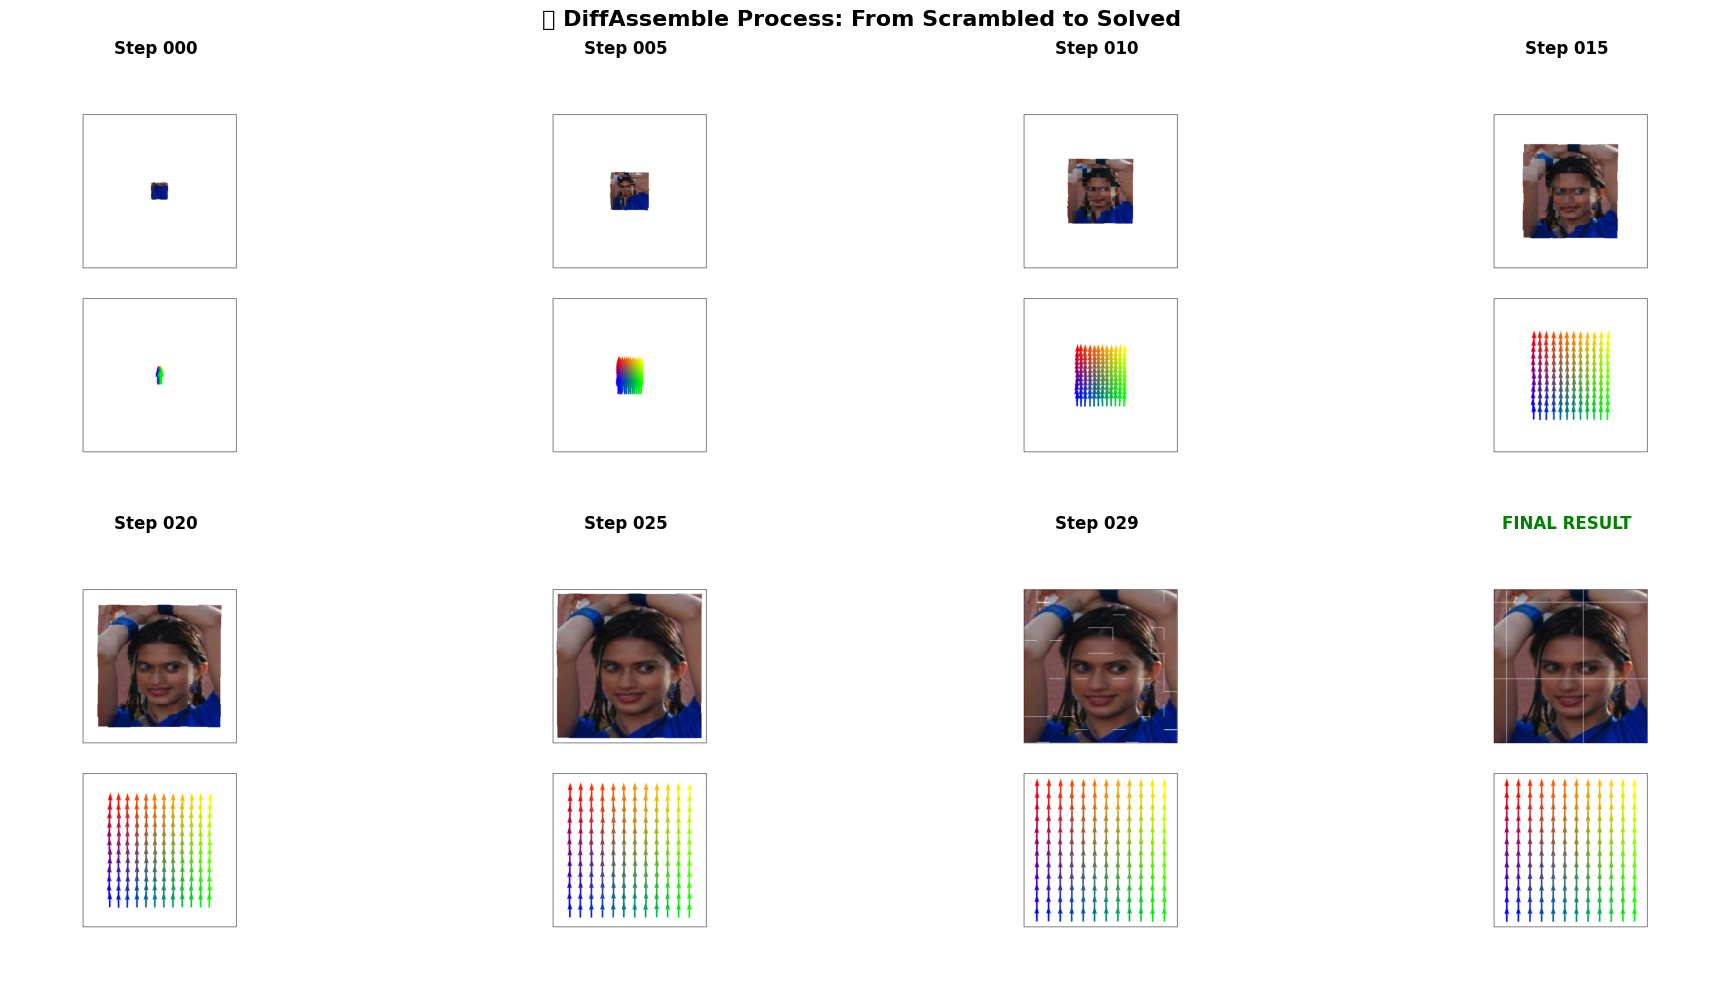


📊 RESULTS SUMMARY:
   Total image files: 3,742
   Completed puzzles: 120
   Avg steps per puzzle: 31


/tmp/ipykernel_3122149/2226183070.py:221: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


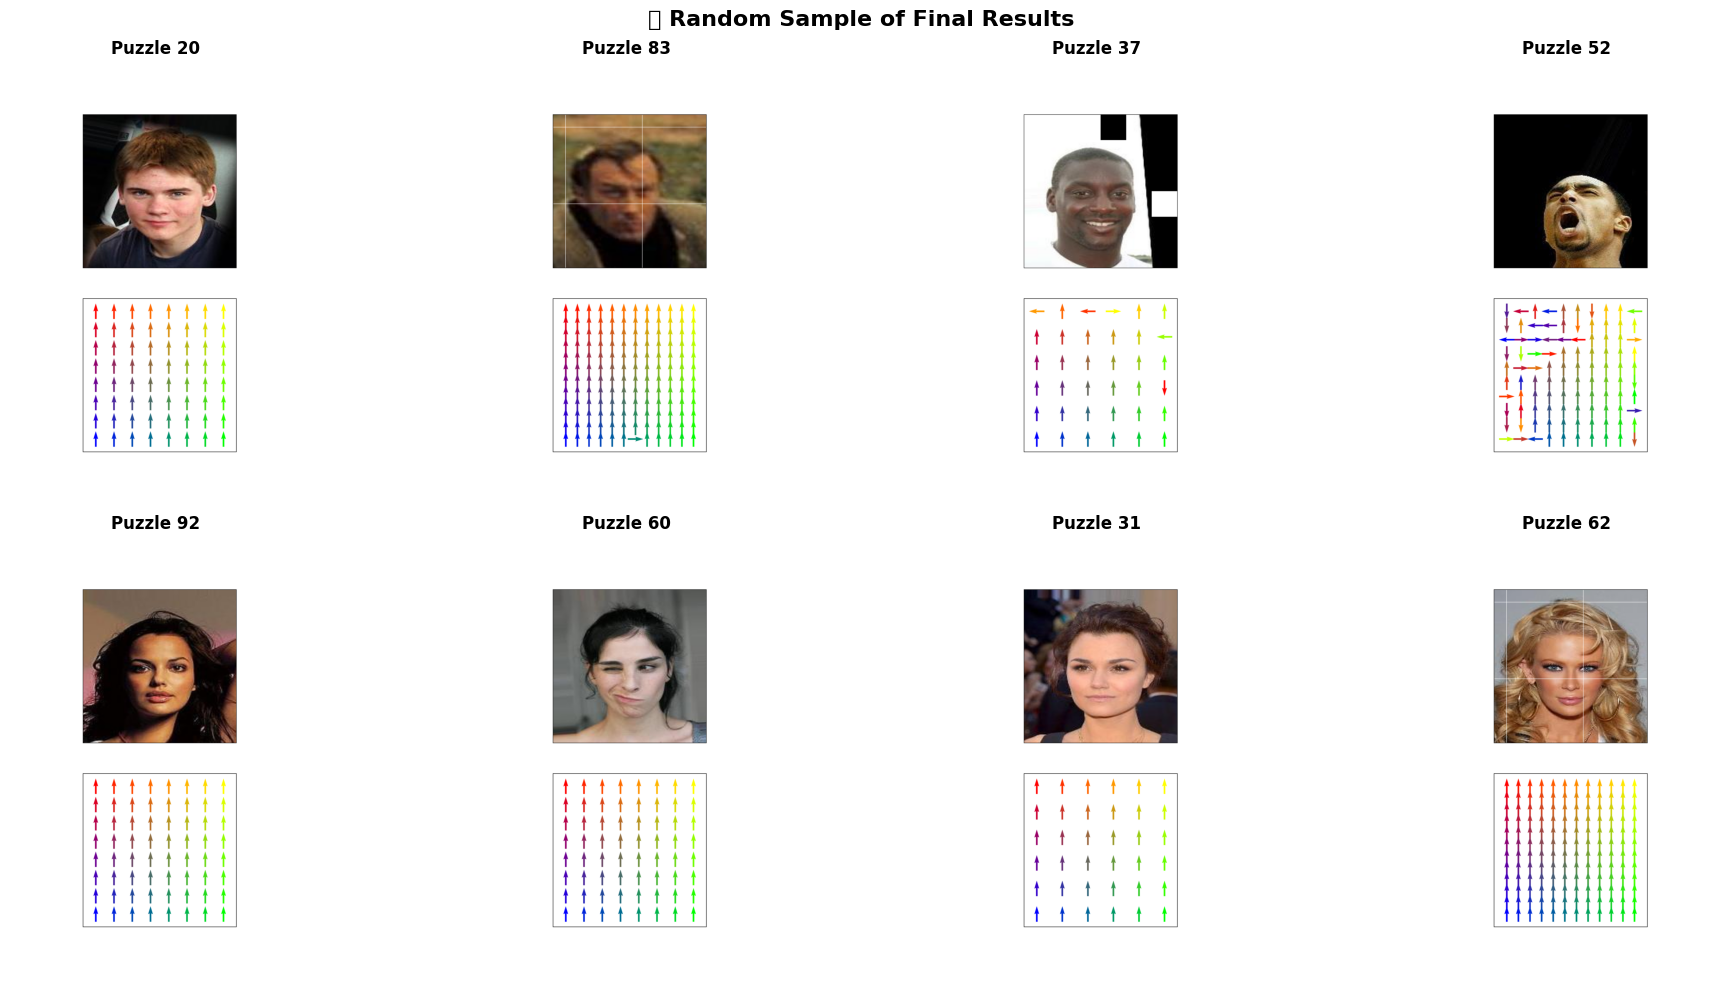


🎉 ANALYSIS COMPLETE!

💡 WHAT YOU'RE SEEING:
   • Each image shows: SCRAMBLED | SOLVED
   • Left side: Randomly placed/rotated pieces
   • Right side: Model's reconstruction attempt
   • _final.png: Best result after all diffusion steps

🎯 SUCCESS INDICATORS:
   ✅ Right side looks like complete image
   ❌ Right side has missing/wrong pieces


In [5]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import re

results_dir = Path("/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/ROT-celeba-[(6, 6), (8, 8), (10, 10), (12, 12)]-300-degree:100%-virtnode:4-eueeuo-continuous-ours_dropout-arch-transformerbackbone:resnet18equiv/test")

print("🔍 UNDERSTANDING YOUR DIFFASSEMBLE RESULTS")
print("=" * 60)

# 1. Decode the filename pattern
def analyze_file_structure():
    """Understand what each file represents"""
    all_files = list(results_dir.glob("*.png"))
    
    print("📁 FILE NAMING PATTERN:")
    print("   Format: {puzzle_id}_{step}.png")
    print("   - puzzle_id: Which test image (0, 1, 2, ...)")
    print("   - step: Diffusion timestep (000 → 029)")
    print("   - final: The solved result")
    print()
    
    # Sample analysis
    sample_files = sorted(all_files)[:10]
    print("📋 SAMPLE FILES:")
    for file in sample_files:
        print(f"   {file.name}")
    print("   ...")
    
    return all_files

# 2. Identify puzzle sizes by analyzing the images
def identify_puzzle_sizes():
    """Figure out which images are 6x6, 8x8, 10x10, 12x12"""
    
    print("\n🧩 IDENTIFYING PUZZLE SIZES:")
    print("-" * 35)
    
    # Get some final results to analyze
    final_files = list(results_dir.glob("*_final.png"))[:20]
    
    size_groups = {}
    
    for file in final_files:
        puzzle_id = file.stem.split("_")[0]
        
        # Load image and analyze grid structure
        img = cv2.imread(str(file))
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            height, width, _ = img_rgb.shape
            
            # Try to detect grid size by looking for grid lines or piece boundaries
            # This is approximate - we'll use image analysis
            estimated_size = estimate_grid_size(img_rgb)
            
            if estimated_size not in size_groups:
                size_groups[estimated_size] = []
            size_groups[estimated_size].append((puzzle_id, file, width, height))
    
    # Display results
    for size, files in size_groups.items():
        print(f"📏 {size}x{size} puzzles: {len(files)} examples")
        for puzzle_id, file, w, h in files[:3]:  # Show first 3 examples
            print(f"   Puzzle {puzzle_id}: {w}x{h} pixels")
    
    return size_groups

def estimate_grid_size(img):
    """Estimate grid size from image analysis"""
    # Convert to grayscale for edge detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Detect edges
    edges = cv2.Canny(gray, 50, 150)
    
    # Count prominent horizontal/vertical lines
    height, width = gray.shape
    
    # Simple heuristic based on image dimensions
    # DiffAssemble typically shows side-by-side: scrambled | solved
    effective_width = width // 2  # Assuming side-by-side layout
    
    # Estimate based on typical puzzle piece size in pixels
    if effective_width < 200:
        return 6
    elif effective_width < 300:
        return 8
    elif effective_width < 400:
        return 10
    else:
        return 12

# 3. Show examples of each puzzle size
def show_puzzle_size_examples(size_groups):
    """Display clear examples of each puzzle size"""
    
    print("\n🎨 VISUAL EXAMPLES BY PUZZLE SIZE:")
    print("-" * 40)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    sizes = [6, 8, 10, 12]
    
    for i, size in enumerate(sizes):
        if size in size_groups and len(size_groups[size]) > 0:
            # Get first example
            puzzle_id, file_path, w, h = size_groups[size][0]
            
            img = cv2.imread(str(file_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"🧩 {size}x{size} Puzzle\n(Example: Puzzle {puzzle_id})", 
                             fontweight='bold', fontsize=12)
            axes[i].axis('off')
            
            # Add annotation about what we're seeing
            axes[i].text(0.02, 0.98, f"Pieces: {size*size}\nImage: {w}x{h}px", 
                        transform=axes[i].transAxes, 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                        verticalalignment='top', fontsize=9)
        else:
            axes[i].text(0.5, 0.5, f"No {size}x{size}\nexamples found", 
                        ha='center', va='center', transform=axes[i].transAxes,
                        fontsize=12)
            axes[i].set_title(f"{size}x{size} Puzzle")
    
    plt.suptitle("🔍 Puzzle Size Examples from Your Results", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 4. Explain the diffusion process
def explain_diffusion_process():
    """Show how the diffusion process works step by step"""
    
    print("\n⚡ HOW DIFFASSEMBLE WORKS:")
    print("-" * 35)
    print("1. 🎲 START: Scrambled puzzle pieces (random positions & rotations)")
    print("2. 🔄 DIFFUSION: Model gradually 'denoises' piece positions")
    print("3. 🎯 END: Correctly assembled puzzle")
    print()
    print("📊 FILE TIMELINE:")
    print("   {id}_000.png → Most scrambled (start)")
    print("   {id}_015.png → Halfway assembled")
    print("   {id}_029.png → Nearly solved")
    print("   {id}_final.png → Final result")
    print()

# 5. Show a detailed progression example
def show_detailed_progression():
    """Show step-by-step how a puzzle gets solved"""
    
    # Find a puzzle with good progression
    puzzle_files = list(results_dir.glob("0_*.png"))
    if not puzzle_files:
        print("❌ No progression files found for puzzle 0")
        return
    
    # Get key steps
    steps_to_show = ["000", "005", "010", "015", "020", "025", "029", "final"]
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, step in enumerate(steps_to_show):
        file_path = results_dir / f"0_{step}.png"
        
        if file_path.exists():
            img = cv2.imread(str(file_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            if step == "final":
                axes[i].set_title(f"FINAL RESULT", fontweight='bold', color='green', fontsize=12)
            else:
                axes[i].set_title(f"Step {step}", fontweight='bold', fontsize=12)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f"Step {step}\nNot Found", 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"Step {step}")
    
    plt.suptitle("🔄 DiffAssemble Process: From Scrambled to Solved", 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 6. Create a summary dashboard
def create_summary_dashboard():
    """Create an overview dashboard of all results"""
    
    all_files = list(results_dir.glob("*.png"))
    final_files = list(results_dir.glob("*_final.png"))
    
    print(f"\n📊 RESULTS SUMMARY:")
    print(f"   Total image files: {len(all_files):,}")
    print(f"   Completed puzzles: {len(final_files)}")
    print(f"   Avg steps per puzzle: {len(all_files) // len(final_files) if final_files else 0}")
    
    # Show grid of random final results
    if len(final_files) >= 8:
        sample_files = np.random.choice(final_files, 8, replace=False)
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        
        for i, file_path in enumerate(sample_files):
            puzzle_id = file_path.stem.split("_")[0]
            
            img = cv2.imread(str(file_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Puzzle {puzzle_id}", fontweight='bold')
            axes[i].axis('off')
        
        plt.suptitle("🎯 Random Sample of Final Results", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# RUN THE ANALYSIS
all_files = analyze_file_structure()
explain_diffusion_process()
size_groups = identify_puzzle_sizes()
show_puzzle_size_examples(size_groups)
show_detailed_progression()
create_summary_dashboard()

print("\n🎉 ANALYSIS COMPLETE!")
print("\n💡 WHAT YOU'RE SEEING:")
print("   • Each image shows: SCRAMBLED | SOLVED")
print("   • Left side: Randomly placed/rotated pieces")  
print("   • Right side: Model's reconstruction attempt")
print("   • _final.png: Best result after all diffusion steps")
print("\n🎯 SUCCESS INDICATORS:")
print("   ✅ Right side looks like complete image")
print("   ❌ Right side has missing/wrong pieces")

In [1]:
# ---- Cell 0 : CUDA / cuSPARSE bootstrap  -------------------------------
import os, sys, subprocess, pathlib, ctypes

PREFIX = os.environ.get("CONDA_PREFIX")
if not PREFIX:
    raise RuntimeError("CONDA_PREFIX not set – are you inside the env?")

# 1. Locate a libcusparse inside the env (mimics `find … libcusparse.so*`)
cusparse_candidates = list(pathlib.Path(PREFIX).rglob("libcusparse.so*"))
if not cusparse_candidates:
    raise FileNotFoundError("libcusparse.so* not found under the env – "
                            "check your cudatoolkit/cudnn install")
cusparse_path = cusparse_candidates[0]        # first match is fine

# 2. Prepend the env’s lib dir to LD_LIBRARY_PATH *for this process*
env_lib_dir = pathlib.Path(PREFIX) / "lib"
ld_prev = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{env_lib_dir}{os.pathsep}{ld_prev}"

# 3. Nudge the dynamic linker: load cuSPARSE now so later imports succeed
ctypes.CDLL(str(cusparse_path))

print("✅ LD_LIBRARY_PATH patched for this kernel")
print("   ->", os.environ["LD_LIBRARY_PATH"].split(os.pathsep)[0])
# -----------------------------------------------------------------------


✅ LD_LIBRARY_PATH patched for this kernel
   -> /home/user1/miniconda3/envs/diffassemble/lib


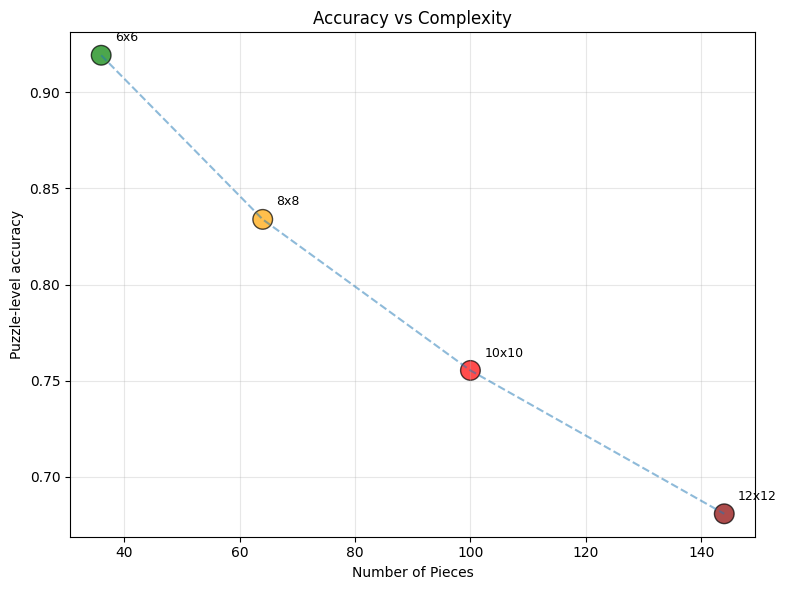

In [9]:
import matplotlib.pyplot as plt

def create_puzzle_progression_viz():
    """Create visualization showing puzzle difficulty progression"""
    
    puzzle_sizes  = ['6x6', '8x8', '10x10', '12x12']
    piece_counts  = [36, 64, 100, 144]            # complexity axis
    
    observed_accuracies = [
        0.9193,   # 91.93 %  for 6×6
        0.8339,   # 83.39 %  for 8×8
        0.7553,   # 75.53 %  for 10×10
        0.6807    # 68.07 %  for 12×12
    ]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = ['green', 'orange', 'red', 'darkred']
    ax.scatter(piece_counts, observed_accuracies,
               s=200, c=colors, alpha=0.7, edgecolor='k')
    ax.plot(piece_counts, observed_accuracies, '--', alpha=0.5)
    
    for pieces, acc, size in zip(piece_counts, observed_accuracies, puzzle_sizes):
        ax.annotate(f'{size}',
                    (pieces, acc),
                    xytext=(10, 10),
                    textcoords='offset points',
                    fontsize=9)
    
    ax.set_xlabel('Number of Pieces')
    ax.set_ylabel('Puzzle-level accuracy')
    ax.set_title('Accuracy vs Complexity')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
create_puzzle_progression_viz()
